In [1]:
# ============================================================
# Portion 4 / Cell P4-00: Setup and robust path resolver
# ============================================================

!pip install -q scikit-learn tqdm matplotlib pillow

import os
import re
import gc
import json
import math
import time
import random
import warnings
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd

from PIL import Image, ImageFile

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

ImageFile.LOAD_TRUNCATED_IMAGES = True
Image.MAX_IMAGE_PIXELS = None


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
P4_SEED = 42

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


seed_everything(P4_SEED)


# ------------------------------------------------------------
# Input/output roots
# ------------------------------------------------------------
INPUT_ROOT = Path("/kaggle/input/notebooks/nabidnur/iciset-2026")
WORK_ROOT = Path("/kaggle/working/tinyagrivqa_bn_portion4")

P4_DIR = WORK_ROOT
P4_REPORT_DIR = P4_DIR / "reports"
P4_FIG_DIR = P4_DIR / "figures"
P4_TABLE_DIR = P4_DIR / "tables"
P4_ERROR_DIR = P4_DIR / "error_analysis"
P4_CALIB_DIR = P4_DIR / "calibration"
P4_ABLATION_DIR = P4_DIR / "ablation"
P4_GRADCAM_DIR = P4_DIR / "gradcam"
P4_PAPER_DIR = P4_DIR / "paper_ready"

for d in [
    P4_DIR,
    P4_REPORT_DIR,
    P4_FIG_DIR,
    P4_TABLE_DIR,
    P4_ERROR_DIR,
    P4_CALIB_DIR,
    P4_ABLATION_DIR,
    P4_GRADCAM_DIR,
    P4_PAPER_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Device
# ------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_GPUS = torch.cuda.device_count()

print("=" * 90)
print("PORTION 4 SETUP")
print("=" * 90)
print("Input root:", INPUT_ROOT)
print("Work root:", WORK_ROOT)
print("Device:", DEVICE)
print("GPUs:", NUM_GPUS)

if torch.cuda.is_available():
    for i in range(NUM_GPUS):
        print(f"GPU {i}:", torch.cuda.get_device_name(i))


# ------------------------------------------------------------
# Robust file finder
# ------------------------------------------------------------
def find_one(root: Path, filename: str, required=True):
    matches = list(root.rglob(filename))
    matches = sorted(matches, key=lambda p: len(str(p)))

    if len(matches) == 0:
        if required:
            raise FileNotFoundError(f"Could not find {filename} under {root}")
        return None

    return matches[0]


def find_by_suffix(root: Path, suffix: str, required=True):
    matches = [p for p in root.rglob("*") if str(p).endswith(suffix)]
    matches = sorted(matches, key=lambda p: len(str(p)))

    if len(matches) == 0:
        if required:
            raise FileNotFoundError(f"Could not find suffix {suffix} under {root}")
        return None

    return matches[0]


# Portion 3 final artifacts
BEST_CKPT = find_one(INPUT_ROOT, "best_tinyagrivqa_bn_p3_final.pt")
LAST_CKPT = find_one(INPUT_ROOT, "last_tinyagrivqa_bn_p3_final.pt", required=False)

P3_HISTORY_CSV = find_one(INPUT_ROOT, "p3_final_history.csv")
P3_TRAIN_REPORT_JSON = find_one(INPUT_ROOT, "p3_final_training_report.json")
P3_EVAL_REPORT_JSON = find_one(INPUT_ROOT, "p3_final_eval_report.json")

VAL_PRED_CSV = find_by_suffix(INPUT_ROOT, "portion3_training_final/predictions/val_predictions.csv")
TEST_PRED_CSV = find_by_suffix(INPUT_ROOT, "portion3_training_final/predictions/test_predictions.csv")

# Portion 2 artifacts
P2_TRAIN_CSV = find_one(INPUT_ROOT, "p2_train.csv")
P2_VAL_CSV = find_one(INPUT_ROOT, "p2_val.csv")
P2_TEST_CSV = find_one(INPUT_ROOT, "p2_test.csv")
P2_MAPPING_JSON = find_one(INPUT_ROOT, "p2_label_mapping.json")
P2_TOKENIZER_JSON = find_one(INPUT_ROOT, "p2_bengali_word_tokenizer.json")
P2_MODEL_CONFIG_JSON = find_one(INPUT_ROOT, "p2_model_config.json")

print("\nResolved files:")
for name, path in [
    ("BEST_CKPT", BEST_CKPT),
    ("P3_HISTORY_CSV", P3_HISTORY_CSV),
    ("P3_TRAIN_REPORT_JSON", P3_TRAIN_REPORT_JSON),
    ("P3_EVAL_REPORT_JSON", P3_EVAL_REPORT_JSON),
    ("VAL_PRED_CSV", VAL_PRED_CSV),
    ("TEST_PRED_CSV", TEST_PRED_CSV),
    ("P2_TRAIN_CSV", P2_TRAIN_CSV),
    ("P2_VAL_CSV", P2_VAL_CSV),
    ("P2_TEST_CSV", P2_TEST_CSV),
    ("P2_MAPPING_JSON", P2_MAPPING_JSON),
    ("P2_TOKENIZER_JSON", P2_TOKENIZER_JSON),
    ("P2_MODEL_CONFIG_JSON", P2_MODEL_CONFIG_JSON),
]:
    print(f"{name}: {path}")

print("\nP4 setup complete.")

PORTION 4 SETUP
Input root: /kaggle/input/notebooks/nabidnur/iciset-2026
Work root: /kaggle/working/tinyagrivqa_bn_portion4
Device: cuda
GPUs: 2
GPU 0: Tesla T4
GPU 1: Tesla T4

Resolved files:
BEST_CKPT: /kaggle/input/notebooks/nabidnur/iciset-2026/tinyagrivqa_bn/portion3_training_final/checkpoints/best_tinyagrivqa_bn_p3_final.pt
P3_HISTORY_CSV: /kaggle/input/notebooks/nabidnur/iciset-2026/tinyagrivqa_bn/portion3_training_final/logs/p3_final_history.csv
P3_TRAIN_REPORT_JSON: /kaggle/input/notebooks/nabidnur/iciset-2026/tinyagrivqa_bn/portion3_training_final/reports/p3_final_training_report.json
P3_EVAL_REPORT_JSON: /kaggle/input/notebooks/nabidnur/iciset-2026/tinyagrivqa_bn/portion3_training_final/reports/p3_final_eval_report.json
VAL_PRED_CSV: /kaggle/input/notebooks/nabidnur/iciset-2026/tinyagrivqa_bn/portion3_training_final/predictions/val_predictions.csv
TEST_PRED_CSV: /kaggle/input/notebooks/nabidnur/iciset-2026/tinyagrivqa_bn/portion3_training_final/predictions/test_predictions.

In [2]:
# ============================================================
# Portion 4 / Cell P4-01: Load predictions, reports, and source CSVs
# ============================================================

print("=" * 90)
print("LOADING PORTION 3 / PORTION 2 ARTIFACTS")
print("=" * 90)

val_pred = pd.read_csv(VAL_PRED_CSV)
test_pred = pd.read_csv(TEST_PRED_CSV)

p2_train = pd.read_csv(P2_TRAIN_CSV)
p2_val = pd.read_csv(P2_VAL_CSV)
p2_test = pd.read_csv(P2_TEST_CSV)

history_df = pd.read_csv(P3_HISTORY_CSV)

with open(P3_TRAIN_REPORT_JSON, "r", encoding="utf-8") as f:
    p3_train_report = json.load(f)

with open(P3_EVAL_REPORT_JSON, "r", encoding="utf-8") as f:
    p3_eval_report = json.load(f)

with open(P2_MAPPING_JSON, "r", encoding="utf-8") as f:
    label_mapping = json.load(f)

with open(P2_MODEL_CONFIG_JSON, "r", encoding="utf-8") as f:
    p2_model_config = json.load(f)


print("val_pred:", val_pred.shape)
print("test_pred:", test_pred.shape)
print("p2_val:", p2_val.shape)
print("p2_test:", p2_test.shape)
print("history:", history_df.shape)

print("\nBest checkpoint:")
print(p3_train_report["best_checkpoint"])
print("best epoch:", p3_train_report["best_epoch"])
print("best metric:", p3_train_report["best_metric"])

print("\nFinal eval report:")
print(json.dumps(p3_eval_report, ensure_ascii=False, indent=2)[:2500])


# ------------------------------------------------------------
# Basic verification
# ------------------------------------------------------------
assert len(val_pred) == len(p2_val), f"val_pred rows {len(val_pred)} != p2_val rows {len(p2_val)}"
assert len(test_pred) == len(p2_test), f"test_pred rows {len(test_pred)} != p2_test rows {len(p2_test)}"

required_pred_cols = [
    "qa_id",
    "image_id",
    "gold_answer_id",
    "pred_answer_id",
    "confidence",
    "gold_answer_text",
    "pred_answer_text",
    "correct",
    "question_type",
    "bangla_question",
    "p2_answer_text",
    "p2_crop_label",
    "p2_disease_label",
    "p2_class_label",
]

for split_name, df_ in [("val", val_pred), ("test", test_pred)]:
    missing = [c for c in required_pred_cols if c not in df_.columns]
    assert len(missing) == 0, f"{split_name} missing columns: {missing}"

print("\nPrediction artifact verification passed.")


# ------------------------------------------------------------
# Save consolidated metadata
# ------------------------------------------------------------
p4_input_manifest = {
    "input_root": str(INPUT_ROOT),
    "work_root": str(WORK_ROOT),
    "best_checkpoint": str(BEST_CKPT),
    "history_csv": str(P3_HISTORY_CSV),
    "eval_report": str(P3_EVAL_REPORT_JSON),
    "val_predictions": str(VAL_PRED_CSV),
    "test_predictions": str(TEST_PRED_CSV),
    "p2_val": str(P2_VAL_CSV),
    "p2_test": str(P2_TEST_CSV),
    "best_epoch": int(p3_train_report["best_epoch"]),
    "best_val_macro_f1": float(p3_train_report["best_metric"]),
}

with open(P4_REPORT_DIR / "p4_input_manifest.json", "w", encoding="utf-8") as f:
    json.dump(p4_input_manifest, f, ensure_ascii=False, indent=2)

print("Saved:", P4_REPORT_DIR / "p4_input_manifest.json")

LOADING PORTION 3 / PORTION 2 ARTIFACTS
val_pred: (15596, 15)
test_pred: (38632, 15)
p2_val: (15596, 22)
p2_test: (38632, 22)
history: (12, 20)

Best checkpoint:
/kaggle/working/tinyagrivqa_bn/portion3_training_final/checkpoints/best_tinyagrivqa_bn_p3_final.pt
best epoch: 11
best metric: 0.834537089217096

Final eval report:
{
  "best_checkpoint": "/kaggle/working/tinyagrivqa_bn/portion3_training_final/checkpoints/best_tinyagrivqa_bn_p3_final.pt",
  "checkpoint_epoch": 11,
  "checkpoint_best_metric": 0.834537089217096,
  "val_metrics": {
    "answer_accuracy": 0.807771223390613,
    "answer_macro_f1": 0.834537089217096,
    "answer_weighted_f1": 0.7947919567919506,
    "answer_ece": 0.012040250400804075,
    "loss": 0.6555939817526302,
    "answer_loss": 0.5881435463174445,
    "crop_loss": 0.12785973839583945,
    "disease_loss": 0.173708192393428,
    "class_loss": 0.17365626636587206
  },
  "test_metrics": {
    "answer_accuracy": 0.8071805756885484,
    "answer_macro_f1": 0.8341188

In [3]:
# ============================================================
# Portion 4 / Cell P4-02: Core metric utilities
# ============================================================

print("=" * 90)
print("CORE METRIC UTILITIES")
print("=" * 90)


def expected_calibration_error_from_conf(conf, correct, n_bins=15):
    conf = np.asarray(conf, dtype=np.float64)
    correct = np.asarray(correct, dtype=np.float64)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    rows = []

    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]

        if i == 0:
            m = (conf >= lo) & (conf <= hi)
        else:
            m = (conf > lo) & (conf <= hi)

        count = int(m.sum())

        if count > 0:
            acc = float(correct[m].mean())
            avg_conf = float(conf[m].mean())
            gap = abs(acc - avg_conf)
            ece += (count / len(conf)) * gap
        else:
            acc = np.nan
            avg_conf = np.nan
            gap = np.nan

        rows.append({
            "bin_id": i,
            "bin_low": lo,
            "bin_high": hi,
            "count": count,
            "accuracy": acc,
            "avg_confidence": avg_conf,
            "abs_gap": gap,
        })

    return float(ece), pd.DataFrame(rows)


def prediction_summary_metrics(pred_df, split_name):
    y_true = pred_df["gold_answer_id"].astype(int).values
    y_pred = pred_df["pred_answer_id"].astype(int).values

    conf = pred_df["confidence"].astype(float).values
    correct = pred_df["correct"].astype(int).values

    ece, _ = expected_calibration_error_from_conf(conf, correct, n_bins=15)

    return {
        "split": split_name,
        "rows": int(len(pred_df)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "ece": float(ece),
        "mean_confidence": float(np.mean(conf)),
        "median_confidence": float(np.median(conf)),
        "mean_confidence_correct": float(pred_df.loc[pred_df["correct"] == 1, "confidence"].mean()),
        "mean_confidence_wrong": float(pred_df.loc[pred_df["correct"] == 0, "confidence"].mean()),
    }


def grouped_metrics(pred_df, group_col, min_rows=10):
    rows = []

    for group_value, g in pred_df.groupby(group_col):
        if len(g) < min_rows:
            continue

        y_true = g["gold_answer_id"].astype(int).values
        y_pred = g["pred_answer_id"].astype(int).values

        rows.append({
            group_col: group_value,
            "rows": int(len(g)),
            "accuracy": float(accuracy_score(y_true, y_pred)),
            "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
            "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
            "mean_confidence": float(g["confidence"].mean()),
            "error_rate": float(1.0 - g["correct"].mean()),
        })

    out = pd.DataFrame(rows)

    if len(out) > 0:
        out = out.sort_values(["macro_f1", "accuracy"], ascending=[True, True]).reset_index(drop=True)

    return out


def save_barh(df, label_col, value_col, title, save_path, top_n=None, figsize=(10, 6)):
    plot_df = df.copy()

    if top_n is not None:
        plot_df = plot_df.head(top_n)

    plot_df = plot_df.sort_values(value_col, ascending=True)

    plt.figure(figsize=figsize)
    plt.barh(plot_df[label_col].astype(str), plot_df[value_col])
    plt.xlabel(value_col)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.show()

    print("Saved:", save_path)


def save_line_plot(x, ys, labels, title, xlabel, ylabel, save_path, figsize=(9, 5)):
    plt.figure(figsize=figsize)

    for y, label in zip(ys, labels):
        plt.plot(x, y, marker="o", label=label)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.show()

    print("Saved:", save_path)


print("Metric utilities ready.")

CORE METRIC UTILITIES
Metric utilities ready.


In [4]:
# ============================================================
# Portion 4 / Cell P4-03: Overall summary and paper-ready table
# ============================================================

print("=" * 90)
print("OVERALL SUMMARY")
print("=" * 90)

overall_rows = [
    prediction_summary_metrics(val_pred, "validation"),
    prediction_summary_metrics(test_pred, "test"),
]

overall_df = pd.DataFrame(overall_rows)

overall_save = P4_TABLE_DIR / "overall_metrics.csv"
overall_df.to_csv(overall_save, index=False)

display(overall_df)

print("Saved:", overall_save)


# ------------------------------------------------------------
# Paper-ready compact table
# ------------------------------------------------------------
paper_main_table = overall_df.copy()
paper_main_table["Accuracy (%)"] = paper_main_table["accuracy"] * 100
paper_main_table["Macro-F1 (%)"] = paper_main_table["macro_f1"] * 100
paper_main_table["Weighted-F1 (%)"] = paper_main_table["weighted_f1"] * 100
paper_main_table["ECE (%)"] = paper_main_table["ece"] * 100

paper_main_table = paper_main_table[
    ["split", "rows", "Accuracy (%)", "Macro-F1 (%)", "Weighted-F1 (%)", "ECE (%)"]
].rename(columns={"split": "Split", "rows": "Rows"})

paper_main_table_save = P4_PAPER_DIR / "paper_main_result_table.csv"
paper_main_table.to_csv(paper_main_table_save, index=False)

display(paper_main_table)

print("Saved:", paper_main_table_save)


# ------------------------------------------------------------
# JSON summary
# ------------------------------------------------------------
p4_main_summary = {
    "best_epoch": int(p3_train_report["best_epoch"]),
    "best_checkpoint": str(BEST_CKPT),
    "validation": overall_rows[0],
    "test": overall_rows[1],
    "generalization_gap": {
        "accuracy_gap_val_minus_test": float(overall_rows[0]["accuracy"] - overall_rows[1]["accuracy"]),
        "macro_f1_gap_val_minus_test": float(overall_rows[0]["macro_f1"] - overall_rows[1]["macro_f1"]),
        "ece_gap_val_minus_test": float(overall_rows[0]["ece"] - overall_rows[1]["ece"]),
    },
}

with open(P4_REPORT_DIR / "p4_main_summary.json", "w", encoding="utf-8") as f:
    json.dump(p4_main_summary, f, ensure_ascii=False, indent=2)

print("\nMain summary:")
print(json.dumps(p4_main_summary, ensure_ascii=False, indent=2))

OVERALL SUMMARY


,split,rows,accuracy,macro_f1,weighted_f1,ece,mean_confidence,median_confidence,mean_confidence_correct,mean_confidence_wrong
0,validation,15596,0.807771,0.834537,0.794792,0.012040,0.814228,0.817701,0.856628,0.636054
1,test,38632,0.807181,0.834119,0.794158,0.009828,0.814290,0.818482,0.855887,0.640159


Saved: /kaggle/working/tinyagrivqa_bn_portion4/tables/overall_metrics.csv


,Split,Rows,Accuracy (%),Macro-F1 (%),Weighted-F1 (%),ECE (%)
0,validation,15596,80.777122,83.453709,79.479196,1.204026
1,test,38632,80.718058,83.411884,79.415808,0.982760


Saved: /kaggle/working/tinyagrivqa_bn_portion4/paper_ready/paper_main_result_table.csv

Main summary:
{
  "best_epoch": 11,
  "best_checkpoint": "/kaggle/input/notebooks/nabidnur/iciset-2026/tinyagrivqa_bn/portion3_training_final/checkpoints/best_tinyagrivqa_bn_p3_final.pt",
  "validation": {
    "split": "validation",
    "rows": 15596,
    "accuracy": 0.807771223390613,
    "macro_f1": 0.834537089217096,
    "weighted_f1": 0.7947919567919506,
    "ece": 0.012040258474336544,
    "mean_confidence": 0.814227550721193,
    "median_confidence": 0.8177013695240021,
    "mean_confidence_correct": 0.8566282240123593,
    "mean_confidence_wrong": 0.636054207785198
  },
  "test": {
    "split": "test",
    "rows": 38632,
    "accuracy": 0.8071805756885484,
    "macro_f1": 0.8341188395493343,
    "weighted_f1": 0.7941580835677382,
    "ece": 0.009827596856542305,
    "mean_confidence": 0.8142903974007056,
    "median_confidence": 0.8184817731380463,
    "mean_confidence_correct": 0.85588702310

TRAINING CURVES


,epoch,global_step,train_loss,train_answer_loss,train_crop_loss,train_disease_loss,train_class_loss,val_answer_accuracy,val_answer_macro_f1,val_answer_weighted_f1,val_answer_ece,val_loss,val_answer_loss,val_crop_loss,val_disease_loss,val_class_loss,lr_image,lr_other,epoch_time_min,best_metric_so_far
0,1,2177,1.922042,1.465666,0.632442,1.248596,1.307635,0.688638,0.372071,0.676828,0.023018,1.194532,0.960453,0.283226,0.670610,0.659700,4.992392e-05,0.000200,17.138620,0.372071
1,2,4354,1.027562,0.832513,0.293805,0.531483,0.534957,0.753334,0.598166,0.736649,0.019575,0.879283,0.752644,0.190603,0.344674,0.348323,4.842773e-05,0.000194,17.201833,0.598166
2,3,6531,0.865033,0.726157,0.228242,0.370863,0.373140,0.768723,0.679304,0.755745,0.018882,0.788885,0.685493,0.161843,0.279349,0.281006,4.512609e-05,0.000181,17.384194,0.679304
3,4,8708,0.789461,0.674899,0.197648,0.302398,0.303643,0.785650,0.714801,0.777864,0.016866,0.736526,0.645635,0.162432,0.237183,0.239626,4.027343e-05,0.000161,17.437885,0.714801
4,5,10885,0.738187,0.639641,0.180440,0.255933,0.257066,0.792831,0.758821,0.779657,0.020319,0.715522,0.631679,0.144627,0.221227,0.222431,3.424372e-05,0.000137,17.342200,0.758821
5,6,13062,0.702082,0.614308,0.170769,0.224083,0.224649,0.797127,0.780862,0.786527,0.023701,0.691874,0.614665,0.136642,0.202515,0.203088,2.750165e-05,0.000110,17.406882,0.780862
6,7,15239,0.679477,0.598590,0.161562,0.204972,0.205044,0.798602,0.787046,0.789152,0.019668,0.687651,0.611336,0.136665,0.199502,0.200147,2.056679e-05,0.000082,17.363444,0.787046
7,8,17416,0.661947,0.586039,0.157127,0.190099,0.190332,0.804501,0.822371,0.792026,0.012082,0.674256,0.600669,0.130556,0.192917,0.193375,1.397357e-05,0.000056,17.259875,0.822371
8,9,19593,0.647035,0.575182,0.151736,0.178764,0.178922,0.804950,0.821675,0.792549,0.011973,0.663874,0.593681,0.129413,0.182103,0.182428,8.230104e-06,0.000033,17.445608,0.822371
9,10,21770,0.638954,0.568918,0.149211,0.173693,0.173922,0.807771,0.830353,0.794644,0.013500,0.653480,0.586578,0.128026,0.171713,0.171964,3.779011e-06,0.000015,17.525668,0.830353


Saved: /kaggle/working/tinyagrivqa_bn_portion4/tables/training_history.csv


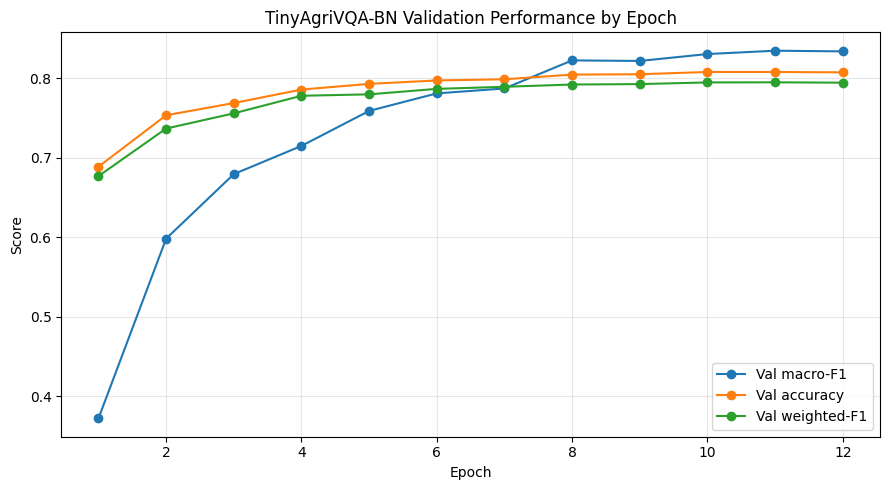

Saved: /kaggle/working/tinyagrivqa_bn_portion4/figures/training_val_scores.png


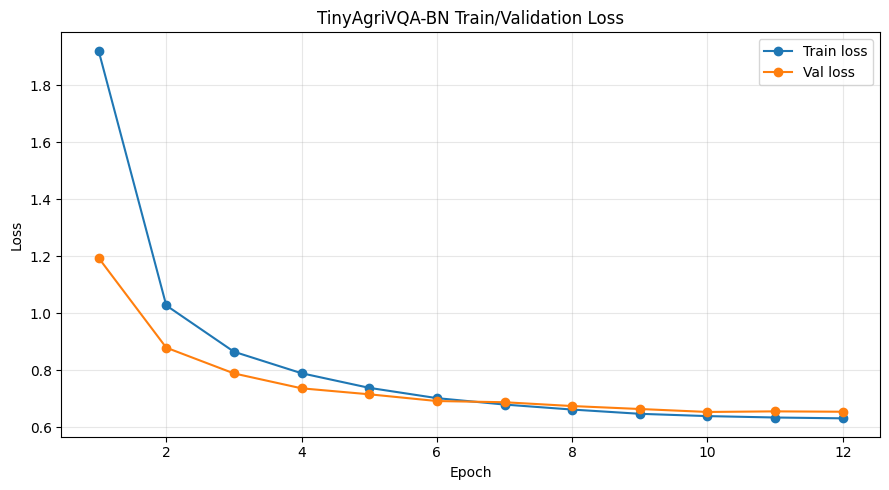

Saved: /kaggle/working/tinyagrivqa_bn_portion4/figures/training_loss_curves.png


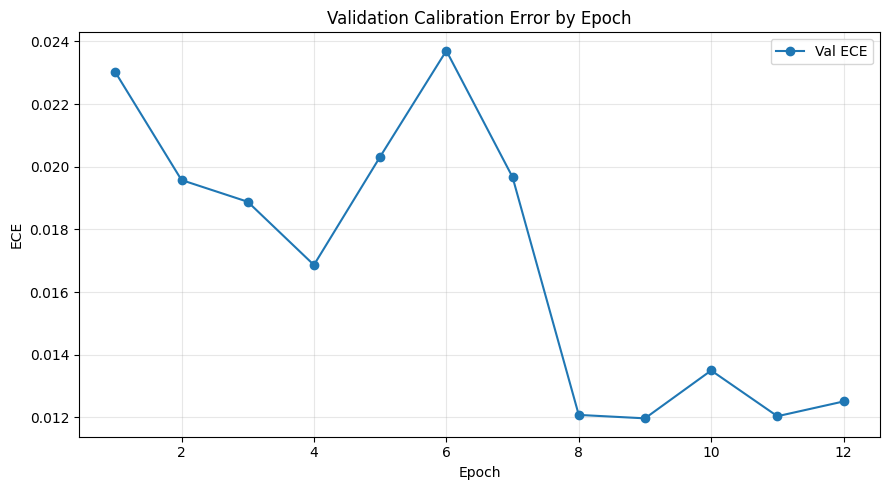

Saved: /kaggle/working/tinyagrivqa_bn_portion4/figures/training_ece_curve.png


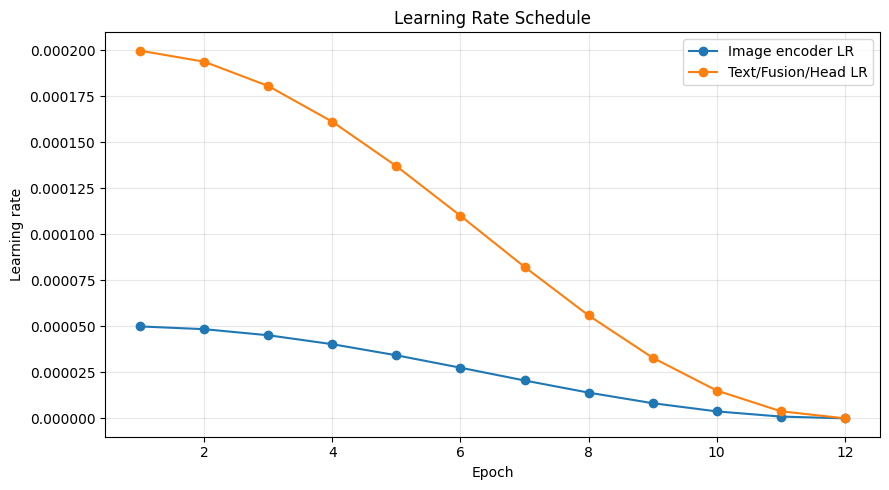

Saved: /kaggle/working/tinyagrivqa_bn_portion4/figures/training_lr_schedule.png


In [5]:
# ============================================================
# Portion 4 / Cell P4-04: Training curves
# ============================================================

print("=" * 90)
print("TRAINING CURVES")
print("=" * 90)

display(history_df)

# Save raw history copy.
history_save = P4_TABLE_DIR / "training_history.csv"
history_df.to_csv(history_save, index=False)
print("Saved:", history_save)

# Val macro-F1 / accuracy
save_line_plot(
    x=history_df["epoch"],
    ys=[
        history_df["val_answer_macro_f1"],
        history_df["val_answer_accuracy"],
        history_df["val_answer_weighted_f1"],
    ],
    labels=["Val macro-F1", "Val accuracy", "Val weighted-F1"],
    title="TinyAgriVQA-BN Validation Performance by Epoch",
    xlabel="Epoch",
    ylabel="Score",
    save_path=P4_FIG_DIR / "training_val_scores.png",
)

# Loss curves
save_line_plot(
    x=history_df["epoch"],
    ys=[
        history_df["train_loss"],
        history_df["val_loss"],
    ],
    labels=["Train loss", "Val loss"],
    title="TinyAgriVQA-BN Train/Validation Loss",
    xlabel="Epoch",
    ylabel="Loss",
    save_path=P4_FIG_DIR / "training_loss_curves.png",
)

# ECE curve
save_line_plot(
    x=history_df["epoch"],
    ys=[history_df["val_answer_ece"]],
    labels=["Val ECE"],
    title="Validation Calibration Error by Epoch",
    xlabel="Epoch",
    ylabel="ECE",
    save_path=P4_FIG_DIR / "training_ece_curve.png",
)

# Learning rates
save_line_plot(
    x=history_df["epoch"],
    ys=[
        history_df["lr_image"],
        history_df["lr_other"],
    ],
    labels=["Image encoder LR", "Text/Fusion/Head LR"],
    title="Learning Rate Schedule",
    xlabel="Epoch",
    ylabel="Learning rate",
    save_path=P4_FIG_DIR / "training_lr_schedule.png",
)

QUESTION-TYPE BREAKDOWN


,question_type,rows,accuracy,macro_f1,weighted_f1,mean_confidence,error_rate,split
0,Counterfactual Reasoning,816,0.763480,0.432940,0.661082,0.756650,0.236520,validation
1,Visual Attribute Grounding,1349,0.863603,0.463405,0.800395,0.864357,0.136397,validation
2,General Health Assessment,2595,0.667052,0.580817,0.622360,0.669433,0.332948,validation
3,Plant Species Identification,2737,0.572890,0.628139,0.524144,0.593199,0.427110,validation
4,Detailed Verification,1114,0.812388,0.742288,0.790067,0.838992,0.187612,validation
5,Causal Reasoning,2111,0.961156,0.839548,0.959061,0.962172,0.038844,validation
6,Comprehensive Description,2249,0.941307,0.886305,0.927102,0.943748,0.058693,validation
7,Specific Disease Identification,2395,0.931106,0.921213,0.911966,0.934745,0.068894,validation
8,Existence & Sanity Check,230,1.000000,1.000000,1.000000,0.989129,0.000000,validation
9,Counterfactual Reasoning,2021,0.744186,0.426667,0.635039,0.755614,0.255814,test


Saved: /kaggle/working/tinyagrivqa_bn_portion4/tables/question_type_metrics.csv


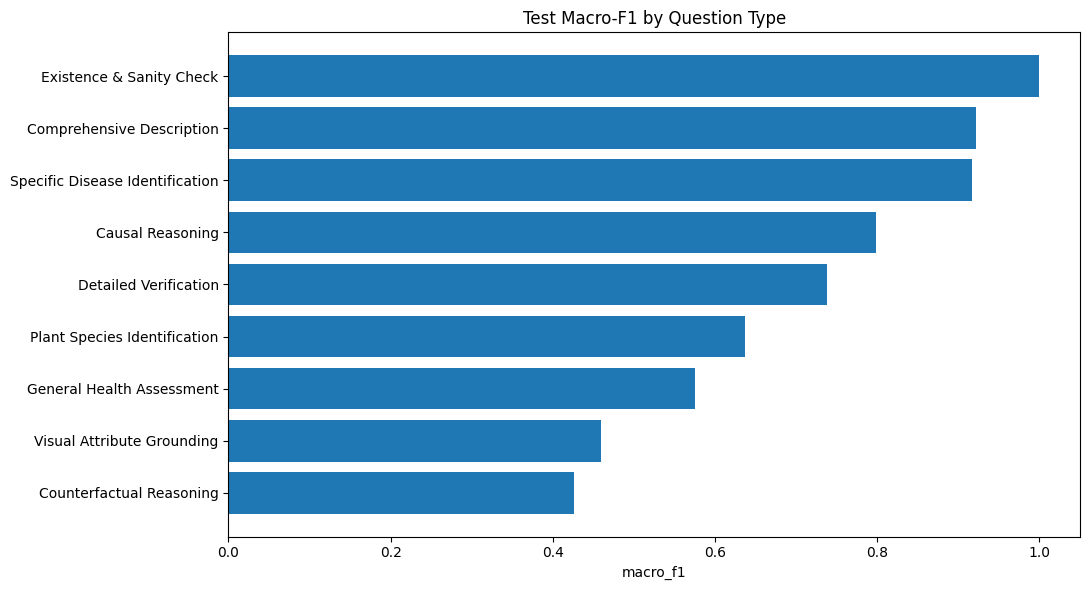

Saved: /kaggle/working/tinyagrivqa_bn_portion4/figures/test_question_type_macro_f1.png


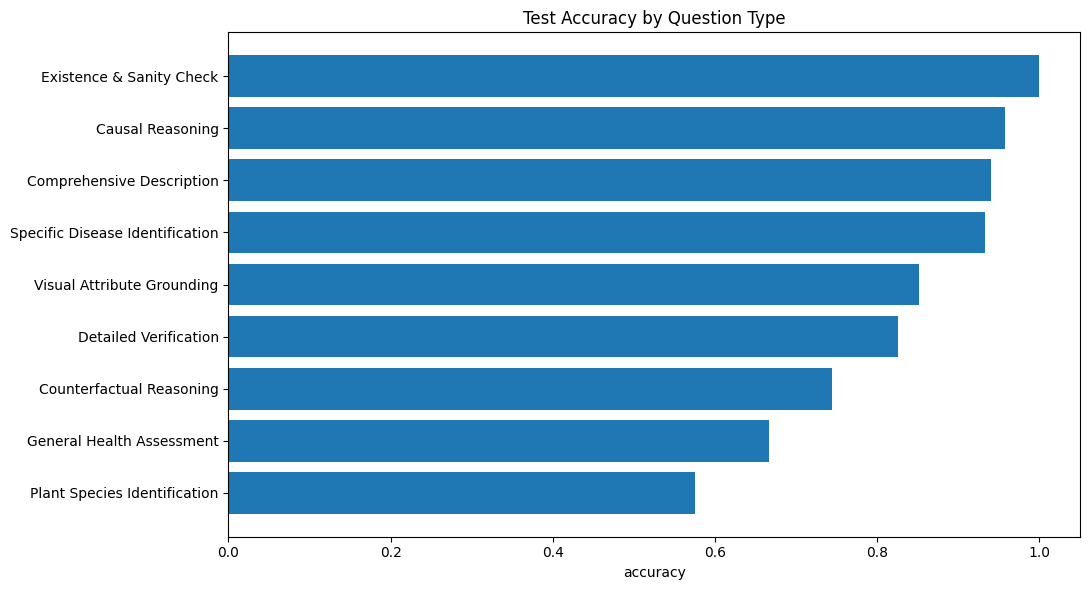

Saved: /kaggle/working/tinyagrivqa_bn_portion4/figures/test_question_type_accuracy.png
Hardest question types:


,question_type,rows,accuracy,macro_f1,weighted_f1,mean_confidence,error_rate,split
0,Counterfactual Reasoning,2021,0.744186,0.426667,0.635039,0.755614,0.255814,test
1,Visual Attribute Grounding,3205,0.851794,0.459983,0.783622,0.866359,0.148206,test
2,General Health Assessment,6365,0.666143,0.574809,0.620538,0.667706,0.333857,test
3,Plant Species Identification,6794,0.575066,0.637424,0.529526,0.593513,0.424934,test
4,Detailed Verification,2848,0.825492,0.737485,0.801529,0.836580,0.174508,test


Saved: /kaggle/working/tinyagrivqa_bn_portion4/error_analysis/hardest_question_types.csv


In [6]:
# ============================================================
# Portion 4 / Cell P4-05: Question-type breakdown
# ============================================================

print("=" * 90)
print("QUESTION-TYPE BREAKDOWN")
print("=" * 90)

val_qtype = grouped_metrics(val_pred, "question_type", min_rows=1)
test_qtype = grouped_metrics(test_pred, "question_type", min_rows=1)

val_qtype["split"] = "validation"
test_qtype["split"] = "test"

qtype_metrics = pd.concat([val_qtype, test_qtype], axis=0).reset_index(drop=True)

qtype_save = P4_TABLE_DIR / "question_type_metrics.csv"
qtype_metrics.to_csv(qtype_save, index=False)

display(qtype_metrics)

print("Saved:", qtype_save)

# Separate test question-type figure.
test_qtype_plot = test_qtype.sort_values("macro_f1", ascending=True)

save_barh(
    test_qtype_plot,
    label_col="question_type",
    value_col="macro_f1",
    title="Test Macro-F1 by Question Type",
    save_path=P4_FIG_DIR / "test_question_type_macro_f1.png",
    figsize=(11, 6),
)

save_barh(
    test_qtype_plot,
    label_col="question_type",
    value_col="accuracy",
    title="Test Accuracy by Question Type",
    save_path=P4_FIG_DIR / "test_question_type_accuracy.png",
    figsize=(11, 6),
)

# Hardest question types
hard_qtypes = test_qtype.sort_values(["macro_f1", "accuracy"], ascending=[True, True]).head(5)
hard_qtypes_save = P4_ERROR_DIR / "hardest_question_types.csv"
hard_qtypes.to_csv(hard_qtypes_save, index=False)

print("Hardest question types:")
display(hard_qtypes)
print("Saved:", hard_qtypes_save)

CROP / DISEASE / CLASS BREAKDOWN

CROP metrics


,p2_crop_label,rows,accuracy,macro_f1,weighted_f1,mean_confidence,error_rate,split
0,peach,34,0.617647,0.254545,0.763636,0.698603,0.382353,validation
1,unknown,9905,0.723978,0.303767,0.730991,0.766795,0.276022,validation
2,potato,93,0.870968,0.310345,0.931034,0.574479,0.129032,validation
3,soybean,69,0.884058,0.312821,0.938462,0.736395,0.115942,validation
4,squash,21,0.904762,0.475000,0.947619,0.838584,0.095238,validation
5,cherry,20,0.750000,0.604938,0.851852,0.758651,0.250000,validation
6,strawberry,41,0.878049,0.622222,0.930081,0.790573,0.121951,validation
7,apple,57,0.842105,0.663636,0.903509,0.712842,0.157895,validation
8,corn_maize,105,0.828571,0.684357,0.883483,0.846482,0.171429,validation
9,grape,108,0.888889,0.691336,0.933545,0.865736,0.111111,validation


Saved: /kaggle/working/tinyagrivqa_bn_portion4/tables/crop_metrics.csv


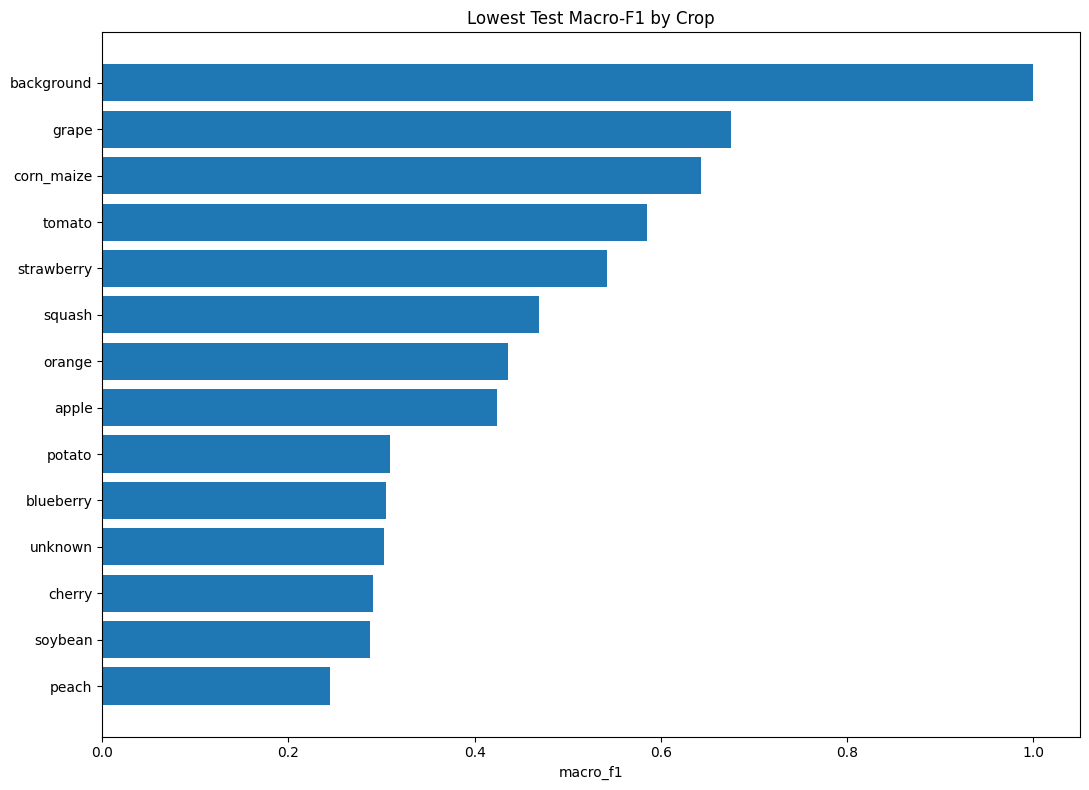

Saved: /kaggle/working/tinyagrivqa_bn_portion4/figures/test_crop_macro_f1_lowest.png

DISEASE metrics


,p2_disease_label,rows,accuracy,macro_f1,weighted_f1,mean_confidence,error_rate,split
0,early_blight_general,474,0.955696,0.162891,0.977346,0.978298,0.044304,validation
1,healthy,547,0.601463,0.215554,0.622348,0.653607,0.398537,validation
2,late_blight_general,702,0.984330,0.248026,0.992102,0.987101,0.015670,validation
3,bacterial_spot_general,624,0.985577,0.248177,0.992736,0.986891,0.014423,validation
4,powdery_mildew_general,46,0.891304,0.297512,0.936794,0.951180,0.108696,validation
5,tomato_target_spot,330,0.981818,0.330275,0.990826,0.983912,0.018182,validation
6,black_rot_general,27,0.888889,0.431686,0.934755,0.928412,0.111111,validation
7,unknown,8857,0.695495,0.446524,0.692433,0.706598,0.304505,validation
8,tomato_spider_mites_two_spotted_spider_mite,405,0.987654,0.496893,0.993786,0.979631,0.012346,validation
9,tomato_septoria_leaf_spot,435,0.993103,0.498270,0.996540,0.988587,0.006897,validation


Saved: /kaggle/working/tinyagrivqa_bn_portion4/tables/disease_metrics.csv


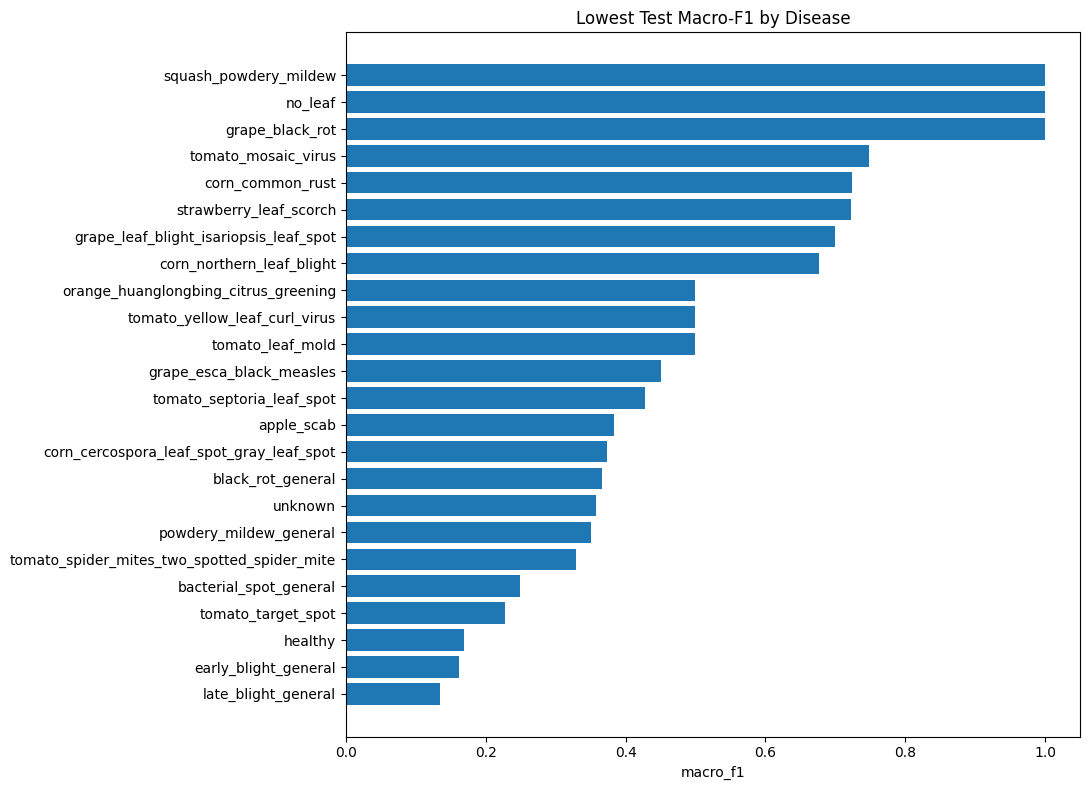

Saved: /kaggle/working/tinyagrivqa_bn_portion4/figures/test_disease_macro_f1_lowest.png

CLASS metrics


,p2_class_label,rows,accuracy,macro_f1,weighted_f1,mean_confidence,error_rate,split
0,early_blight_general,474,0.955696,0.162891,0.977346,0.978298,0.044304,validation
1,healthy_general,547,0.601463,0.215554,0.622348,0.653607,0.398537,validation
2,late_blight_general,702,0.984330,0.248026,0.992102,0.987101,0.015670,validation
3,bacterial_spot_general,624,0.985577,0.248177,0.992736,0.986891,0.014423,validation
4,powdery_mildew_general,46,0.891304,0.297512,0.936794,0.951180,0.108696,validation
5,tomato_target_spot,330,0.981818,0.330275,0.990826,0.983912,0.018182,validation
6,black_rot_general,27,0.888889,0.431686,0.934755,0.928412,0.111111,validation
7,unknown_unknown,8857,0.695495,0.446524,0.692433,0.706598,0.304505,validation
8,tomato_spider_mites_two_spotted_spider_mite,405,0.987654,0.496893,0.993786,0.979631,0.012346,validation
9,tomato_septoria_leaf_spot,435,0.993103,0.498270,0.996540,0.988587,0.006897,validation


Saved: /kaggle/working/tinyagrivqa_bn_portion4/tables/class_metrics.csv


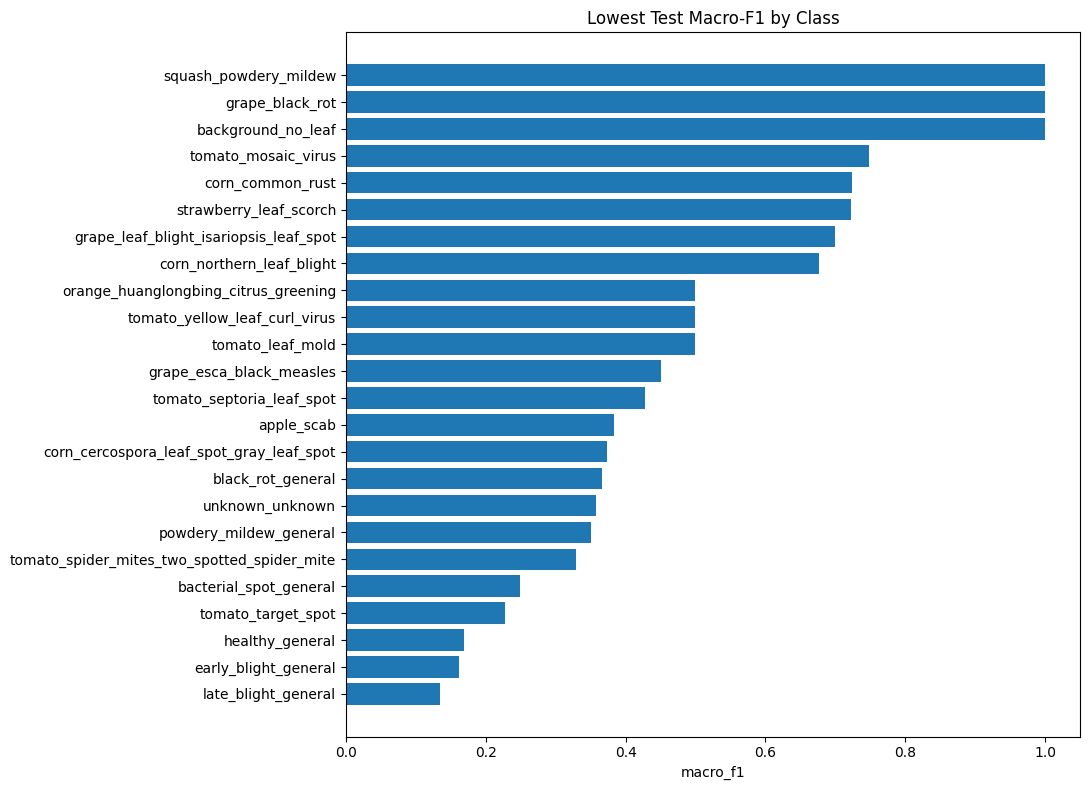

Saved: /kaggle/working/tinyagrivqa_bn_portion4/figures/test_class_macro_f1_lowest.png

Hardest disease labels:


,p2_disease_label,rows,accuracy,macro_f1,weighted_f1,mean_confidence,error_rate
0,late_blight_general,1716,0.975524,0.134674,0.987609,0.983038,0.024476
1,early_blight_general,1263,0.943785,0.161847,0.971079,0.978237,0.056215
2,healthy,1364,0.590909,0.168605,0.605069,0.657729,0.409091
3,tomato_target_spot,921,0.972856,0.227594,0.986240,0.980851,0.027144
4,bacterial_spot_general,1433,0.991626,0.248955,0.995795,0.986344,0.008374
5,tomato_spider_mites_two_spotted_spider_mite,984,0.973577,0.328870,0.986611,0.979750,0.026423
6,powdery_mildew_general,119,0.865546,0.351123,0.917741,0.923690,0.134454
7,unknown,21800,0.695734,0.357569,0.692980,0.706248,0.304266
8,black_rot_general,82,0.890244,0.366095,0.937259,0.906290,0.109756
9,tomato_septoria_leaf_spot,951,0.995794,0.427668,0.997892,0.986142,0.004206



Hardest class labels:


,p2_class_label,rows,accuracy,macro_f1,weighted_f1,mean_confidence,error_rate
0,late_blight_general,1716,0.975524,0.134674,0.987609,0.983038,0.024476
1,early_blight_general,1263,0.943785,0.161847,0.971079,0.978237,0.056215
2,healthy_general,1364,0.590909,0.168605,0.605069,0.657729,0.409091
3,tomato_target_spot,921,0.972856,0.227594,0.986240,0.980851,0.027144
4,bacterial_spot_general,1433,0.991626,0.248955,0.995795,0.986344,0.008374
5,tomato_spider_mites_two_spotted_spider_mite,984,0.973577,0.328870,0.986611,0.979750,0.026423
6,powdery_mildew_general,119,0.865546,0.351123,0.917741,0.923690,0.134454
7,unknown_unknown,21800,0.695734,0.357569,0.692980,0.706248,0.304266
8,black_rot_general,82,0.890244,0.366095,0.937259,0.906290,0.109756
9,tomato_septoria_leaf_spot,951,0.995794,0.427668,0.997892,0.986142,0.004206


In [7]:
# ============================================================
# Portion 4 / Cell P4-06: Crop/Disease/Class breakdown
# ============================================================

print("=" * 90)
print("CROP / DISEASE / CLASS BREAKDOWN")
print("=" * 90)

breakdown_configs = [
    ("p2_crop_label", "crop"),
    ("p2_disease_label", "disease"),
    ("p2_class_label", "class"),
]

all_breakdowns = []

for col, short_name in breakdown_configs:
    val_m = grouped_metrics(val_pred, col, min_rows=20)
    test_m = grouped_metrics(test_pred, col, min_rows=20)

    val_m["split"] = "validation"
    test_m["split"] = "test"

    merged = pd.concat([val_m, test_m], axis=0).reset_index(drop=True)
    save_path = P4_TABLE_DIR / f"{short_name}_metrics.csv"
    merged.to_csv(save_path, index=False)

    all_breakdowns.append(merged)

    print("\n" + "=" * 70)
    print(short_name.upper(), "metrics")
    print("=" * 70)
    display(merged.head(30))
    print("Saved:", save_path)

    # Test plot
    test_plot = test_m.sort_values("macro_f1", ascending=True).head(25)

    save_barh(
        test_plot,
        label_col=col,
        value_col="macro_f1",
        title=f"Lowest Test Macro-F1 by {short_name.capitalize()}",
        save_path=P4_FIG_DIR / f"test_{short_name}_macro_f1_lowest.png",
        figsize=(11, 8),
    )

# Compact hardest classes/diseases
hard_disease = grouped_metrics(test_pred, "p2_disease_label", min_rows=50).sort_values("macro_f1").head(15)
hard_class = grouped_metrics(test_pred, "p2_class_label", min_rows=50).sort_values("macro_f1").head(15)

hard_disease.to_csv(P4_ERROR_DIR / "hardest_disease_labels.csv", index=False)
hard_class.to_csv(P4_ERROR_DIR / "hardest_class_labels.csv", index=False)

print("\nHardest disease labels:")
display(hard_disease)

print("\nHardest class labels:")
display(hard_class)

ANSWER CONFUSION ANALYSIS
Top test confusion pairs:


,gold_answer_id,pred_answer_id,gold_answer_text,pred_answer_text,count,split
0,1,0,হ্যাঁ।,না।,2350,test
1,0,1,না।,হ্যাঁ।,1191,test
2,0,2,না।,এটি টমেটো গাছের পাতা।,563,test
3,16,3,"যেহেতু পাতাটি সুস্থ, রোগজনিত অতিরিক্ত পরিবর্তন...",বিকল্প পরিস্থিতি নির্ভরযোগ্যভাবে ব্যাখ্যা করা ...,517,test
4,1,2,হ্যাঁ।,এটি টমেটো গাছের পাতা।,353,test
5,28,18,নির্দিষ্ট রোগ নির্ভরযোগ্যভাবে শনাক্ত করা যায়নি।,পাতাটি সুস্থ; নির্দিষ্ট রোগের লক্ষণ দেখা যাচ্ছ...,292,test
6,2,1,এটি টমেটো গাছের পাতা।,হ্যাঁ।,270,test
7,1,13,হ্যাঁ।,এটি কমলা গাছের পাতা।,243,test
8,33,29,ছবির পাতার অবস্থা স্পষ্টভাবে নির্ধারণ করা যায়নি।,ছবিতে পাতার সুস্থ অবস্থা দেখা যাচ্ছে; উল্লেখযো...,214,test
9,0,13,না।,এটি কমলা গাছের পাতা।,168,test


Saved: /kaggle/working/tinyagrivqa_bn_portion4/error_analysis/answer_confusion_pairs.csv


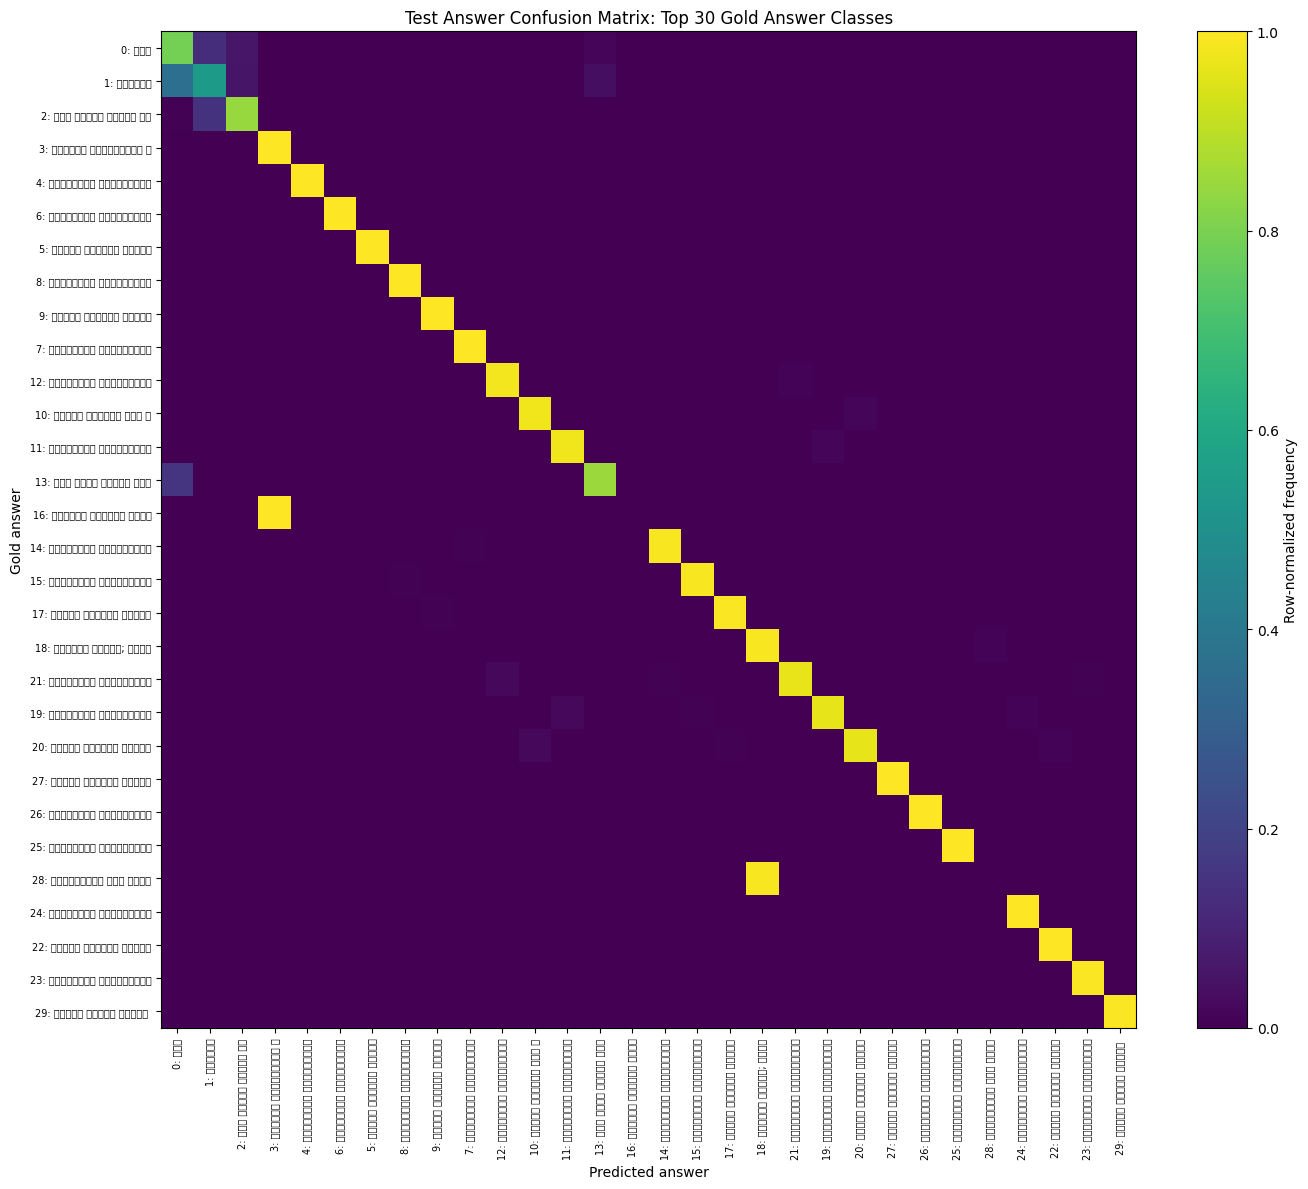

Saved: /kaggle/working/tinyagrivqa_bn_portion4/figures/test_answer_confusion_matrix_top30.png
Saved: /kaggle/working/tinyagrivqa_bn_portion4/tables/test_answer_confusion_matrix_top30_norm.csv


In [8]:
# ============================================================
# Portion 4 / Cell P4-07: Answer confusion matrix and confusion pairs
# ============================================================

print("=" * 90)
print("ANSWER CONFUSION ANALYSIS")
print("=" * 90)

id_to_answer = {int(v): k for k, v in label_mapping["answer_to_id"].items()}


def build_confusion_pair_table(pred_df, split_name):
    wrong = pred_df[pred_df["correct"] == 0].copy()

    pair_counts = (
        wrong.groupby(["gold_answer_id", "pred_answer_id", "gold_answer_text", "pred_answer_text"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .reset_index(drop=True)
    )

    pair_counts["split"] = split_name
    return pair_counts


val_pairs = build_confusion_pair_table(val_pred, "validation")
test_pairs = build_confusion_pair_table(test_pred, "test")

conf_pairs = pd.concat([val_pairs, test_pairs], axis=0).reset_index(drop=True)
conf_pairs_save = P4_ERROR_DIR / "answer_confusion_pairs.csv"
conf_pairs.to_csv(conf_pairs_save, index=False)

print("Top test confusion pairs:")
display(test_pairs.head(30))

print("Saved:", conf_pairs_save)


# ------------------------------------------------------------
# Top-N answer confusion matrix on test
# ------------------------------------------------------------
TOP_N = 30

top_answer_ids = (
    test_pred["gold_answer_id"]
    .value_counts()
    .head(TOP_N)
    .index
    .astype(int)
    .tolist()
)

cm_df = test_pred[
    test_pred["gold_answer_id"].isin(top_answer_ids)
    & test_pred["pred_answer_id"].isin(top_answer_ids)
].copy()

labels = top_answer_ids
cm = confusion_matrix(
    cm_df["gold_answer_id"].astype(int),
    cm_df["pred_answer_id"].astype(int),
    labels=labels,
)

row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)

short_labels = [
    str(i) + ": " + id_to_answer.get(i, "")[:18].replace("\n", " ")
    for i in labels
]

plt.figure(figsize=(14, 12))
plt.imshow(cm_norm, aspect="auto")
plt.colorbar(label="Row-normalized frequency")
plt.xticks(range(len(labels)), short_labels, rotation=90, fontsize=7)
plt.yticks(range(len(labels)), short_labels, fontsize=7)
plt.title(f"Test Answer Confusion Matrix: Top {TOP_N} Gold Answer Classes")
plt.xlabel("Predicted answer")
plt.ylabel("Gold answer")
plt.tight_layout()

cm_fig_path = P4_FIG_DIR / "test_answer_confusion_matrix_top30.png"
plt.savefig(cm_fig_path, dpi=240, bbox_inches="tight")
plt.show()

print("Saved:", cm_fig_path)

# Save matrix as CSV
cm_norm_df = pd.DataFrame(cm_norm, index=short_labels, columns=short_labels)
cm_norm_df.to_csv(P4_TABLE_DIR / "test_answer_confusion_matrix_top30_norm.csv")

print("Saved:", P4_TABLE_DIR / "test_answer_confusion_matrix_top30_norm.csv")

ERROR CASE MINING
Test high-confidence wrong examples:


,qa_id,image_id,gold_answer_id,pred_answer_id,confidence,gold_answer_text,pred_answer_text,correct,resolved_image_path,question_type,bangla_question,p2_answer_text,p2_crop_label,p2_disease_label,p2_class_label
3642,d9305f17206cdddf,image_045587.JPG,11,19,0.994442,সম্ভাব্য নির্দিষ্ট রোগ হলো লেট ব্লাইট।,সম্ভাব্য নির্দিষ্ট রোগ হলো আর্লি ব্লাইট।,0,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,Specific Disease Identification,ছবির পাতাটিতে কোন রোগ বা সমস্যা আছে?,সম্ভাব্য নির্দিষ্ট রোগ হলো লেট ব্লাইট।,unknown,late_blight_general,late_blight_general
16328,4172aeaf56753b61,image_049910.JPG,6,14,0.993423,দৃশ্যমান লক্ষণগুলো সম্ভবত কমলার হুয়াংলংবিং বা ...,দৃশ্যমান লক্ষণগুলো সম্ভবত ব্যাকটেরিয়াল স্পট-এর...,0,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,Causal Reasoning,দৃশ্যমান লক্ষণ দেখে সম্ভাব্য কারণ কী বলা যায়?,দৃশ্যমান লক্ষণগুলো সম্ভবত কমলার হুয়াংলংবিং বা ...,orange,orange_huanglongbing_citrus_greening,orange_huanglongbing_citrus_greening
3637,32c9e94a6149359c,image_045587.JPG,12,21,0.993394,দৃশ্যমান লক্ষণগুলো সম্ভবত লেট ব্লাইট-এর কারণে ...,দৃশ্যমান লক্ষণগুলো সম্ভবত আর্লি ব্লাইট-এর কারণ...,0,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,Causal Reasoning,পাতার এই লক্ষণগুলো কোন কারণে হতে পারে?,দৃশ্যমান লক্ষণগুলো সম্ভবত লেট ব্লাইট-এর কারণে ...,unknown,late_blight_general,late_blight_general
14226,3498c2ad5ae2ddb1,image_049210.JPG,32,27,0.993328,ছবিতে পাতায় টমেটোর টার্গেট স্পট-এর লক্ষণ দেখা...,ছবিতে পাতায় টমেটোর টু-স্পটেড স্পাইডার মাইট-এর...,0,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,Comprehensive Description,ছবির পাতাটির অবস্থা বিস্তারিতভাবে বর্ণনা করুন।,ছবিতে পাতায় টমেটোর টার্গেট স্পট-এর লক্ষণ দেখা...,tomato,tomato_target_spot,tomato_target_spot
14225,c6b2fe52a0f205f8,image_049210.JPG,31,26,0.993245,দৃশ্যমান লক্ষণগুলো সম্ভবত টমেটোর টার্গেট স্পট-...,দৃশ্যমান লক্ষণগুলো সম্ভবত টমেটোর টু-স্পটেড স্প...,0,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,Causal Reasoning,এই পাতার সমস্যার সম্ভাব্য রোগগত কারণ কী?,দৃশ্যমান লক্ষণগুলো সম্ভবত টমেটোর টার্গেট স্পট-...,tomato,tomato_target_spot,tomato_target_spot
16332,a1603cc4f6006f47,image_049910.JPG,4,15,0.993164,সম্ভাব্য নির্দিষ্ট রোগ হলো কমলার হুয়াংলংবিং বা...,সম্ভাব্য নির্দিষ্ট রোগ হলো ব্যাকটেরিয়াল স্পট।,0,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,Specific Disease Identification,ছবির পাতাটিতে কোন রোগ বা সমস্যা আছে?,সম্ভাব্য নির্দিষ্ট রোগ হলো কমলার হুয়াংলংবিং বা...,orange,orange_huanglongbing_citrus_greening,orange_huanglongbing_citrus_greening
24439,ce20a3ea58e2f37c,image_052686.JPG,20,10,0.992898,ছবিতে পাতায় আর্লি ব্লাইট-এর লক্ষণ দেখা যাচ্ছে।,ছবিতে পাতায় লেট ব্লাইট-এর লক্ষণ দেখা যাচ্ছে।,0,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,Comprehensive Description,পাতাটির দৃশ্যমান লক্ষণ ও স্বাস্থ্য অবস্থা ব্যা...,ছবিতে পাতায় আর্লি ব্লাইট-এর লক্ষণ দেখা যাচ্ছে।,unknown,early_blight_general,early_blight_general
4982,909fc2b15d283d97,image_046058.JPG,20,32,0.992747,ছবিতে পাতায় আর্লি ব্লাইট-এর লক্ষণ দেখা যাচ্ছে।,ছবিতে পাতায় টমেটোর টার্গেট স্পট-এর লক্ষণ দেখা...,0,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,Comprehensive Description,ছবির পাতাটির অবস্থা বিস্তারিতভাবে বর্ণনা করুন।,ছবিতে পাতায় আর্লি ব্লাইট-এর লক্ষণ দেখা যাচ্ছে।,unknown,early_blight_general,early_blight_general
24438,0ff9ba62de4d9466,image_052686.JPG,21,12,0.992728,দৃশ্যমান লক্ষণগুলো সম্ভবত আর্লি ব্লাইট-এর কারণ...,দৃশ্যমান লক্ষণগুলো সম্ভবত লেট ব্লাইট-এর কারণে ...,0,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,Causal Reasoning,এই পাতার সমস্যার সম্ভাব্য রোগগত কারণ কী?,দৃশ্যমান লক্ষণগুলো সম্ভবত আর্লি ব্লাইট-এর কারণ...,unknown,early_blight_general,early_blight_general
1066,7ef89f6cc080215c,image_044686.JPG,21,12,0.992693,দৃশ্যমান লক্ষণগুলো সম্ভবত আর্লি ব্লাইট-এর কারণ...,দৃশ্যমান লক্ষণগুলো সম্ভবত লেট ব্লাইট-এর কারণে ...,0,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,Causal Reasoning,দৃশ্যমান লক্ষণ দেখে সম্ভাব্য কারণ কী বলা যায়?,দৃশ্যমান লক্ষণগুলো সম্ভবত আর্লি ব্লাইট-এর কারণ...,unknown,early_blight_general,early_blight_general



Test low-confidence correct examples:


,qa_id,image_id,gold_answer_id,pred_answer_id,confidence,gold_answer_text,pred_answer_text,correct,resolved_image_path,question_type,bangla_question,p2_answer_text,p2_crop_label,p2_disease_label,p2_class_label
17407,339e89af39272e44,image_050289.JPG,34,34,0.333908,এটি আলু গাছের পাতা।,এটি আলু গাছের পাতা।,1,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,Plant Species Identification,এই ছবিতে কোন উদ্ভিদের পাতা দেখা যাচ্ছে?,এটি আলু গাছের পাতা।,potato,unknown,unknown_unknown
25740,517133085b0b2fec,image_053122.JPG,2,2,0.345629,এটি টমেটো গাছের পাতা।,এটি টমেটো গাছের পাতা।,1,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,Plant Species Identification,এই ছবিতে কোন উদ্ভিদের পাতা দেখা যাচ্ছে?,এটি টমেটো গাছের পাতা।,tomato,unknown,unknown_unknown
4221,4e6c17f97bbb81ce,image_045781.JPG,0,0,0.350268,না।,না।,1,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,Plant Species Identification,এই পাতাটি কোন গাছের বলে মনে হচ্ছে?,না।,unknown,unknown,unknown_unknown
22847,0d03e9dd79a1918b,image_052155.JPG,25,25,0.351119,সম্ভাব্য নির্দিষ্ট রোগ হলো টমেটোর টু-স্পটেড স্...,সম্ভাব্য নির্দিষ্ট রোগ হলো টমেটোর টু-স্পটেড স্...,1,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,Specific Disease Identification,এই পাতার সম্ভাব্য রোগ কী?,সম্ভাব্য নির্দিষ্ট রোগ হলো টমেটোর টু-স্পটেড স্...,tomato,tomato_spider_mites_two_spotted_spider_mite,tomato_spider_mites_two_spotted_spider_mite
9102,9ab9ccd04d0c0340,image_047465.JPG,49,49,0.355387,এটি চেরি গাছের পাতা।,এটি চেরি গাছের পাতা।,1,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,Plant Species Identification,এই ছবিতে কোন উদ্ভিদের পাতা দেখা যাচ্ছে?,এটি চেরি গাছের পাতা।,cherry,unknown,unknown_unknown
24888,210ace7dd77d1d34,image_052838.JPG,42,42,0.356063,দৃশ্যমানভাবে রোগজনিত কারণের শক্ত প্রমাণ নেই।,দৃশ্যমানভাবে রোগজনিত কারণের শক্ত প্রমাণ নেই।,1,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,Causal Reasoning,এই পাতার সমস্যার সম্ভাব্য রোগগত কারণ কী?,দৃশ্যমানভাবে রোগজনিত কারণের শক্ত প্রমাণ নেই।,unknown,healthy,healthy_general
4217,a0bd40c7d88d73d1,image_045780.JPG,44,44,0.358101,লক্ষণগুলোর কারণ নিশ্চিতভাবে বলা যাচ্ছে না।,লক্ষণগুলোর কারণ নিশ্চিতভাবে বলা যাচ্ছে না।,1,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,Causal Reasoning,এই পাতার সমস্যার সম্ভাব্য রোগগত কারণ কী?,লক্ষণগুলোর কারণ নিশ্চিতভাবে বলা যাচ্ছে না।,unknown,unknown,unknown_unknown
23271,4ddf5f817d986626,image_052301.JPG,1,1,0.360585,হ্যাঁ।,হ্যাঁ।,1,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,Plant Species Identification,এই পাতাটি কোন গাছের বলে মনে হচ্ছে?,হ্যাঁ।,unknown,unknown,unknown_unknown
5842,6c78cdd8837627b2,image_046342.JPG,1,1,0.362070,হ্যাঁ।,হ্যাঁ।,1,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,Plant Species Identification,এই ছবিতে কোন উদ্ভিদের পাতা দেখা যাচ্ছে?,হ্যাঁ।,unknown,unknown,unknown_unknown
31666,d02abc77e19ddf6c,image_055142.JPG,1,1,0.362190,হ্যাঁ।,হ্যাঁ।,1,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,Plant Species Identification,এই ছবিতে কোন উদ্ভিদের পাতা দেখা যাচ্ছে?,হ্যাঁ।,unknown,unknown,unknown_unknown



Test error by question type:


,question_type,wrong_count,total_count,error_rate
5,Plant Species Identification,2887,6794,0.424934
4,General Health Assessment,2125,6365,0.333857
2,Counterfactual Reasoning,517,2021,0.255814
3,Detailed Verification,497,2848,0.174508
7,Visual Attribute Grounding,475,3205,0.148206
6,Specific Disease Identification,398,5979,0.066566
1,Comprehensive Description,330,5573,0.059214
0,Causal Reasoning,220,5230,0.042065


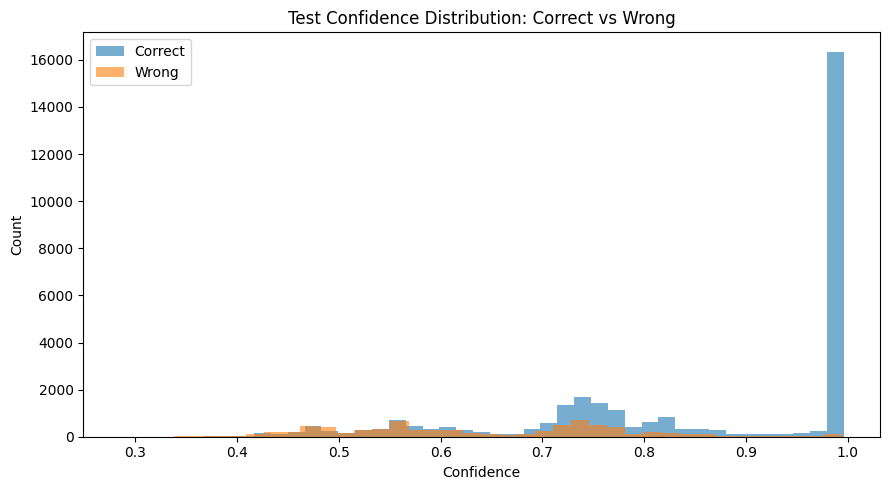

Saved: /kaggle/working/tinyagrivqa_bn_portion4/figures/test_confidence_distribution_correct_vs_wrong.png


In [9]:
# ============================================================
# Portion 4 / Cell P4-08: Error case mining
# ============================================================

print("=" * 90)
print("ERROR CASE MINING")
print("=" * 90)


def build_error_tables(pred_df, split_name):
    wrong = pred_df[pred_df["correct"] == 0].copy()
    correct = pred_df[pred_df["correct"] == 1].copy()

    high_conf_wrong = wrong.sort_values("confidence", ascending=False).head(250)
    low_conf_correct = correct.sort_values("confidence", ascending=True).head(250)
    lowest_conf_all = pred_df.sort_values("confidence", ascending=True).head(250)

    high_conf_wrong.to_csv(P4_ERROR_DIR / f"{split_name}_high_conf_wrong.csv", index=False)
    low_conf_correct.to_csv(P4_ERROR_DIR / f"{split_name}_low_conf_correct.csv", index=False)
    lowest_conf_all.to_csv(P4_ERROR_DIR / f"{split_name}_lowest_confidence_all.csv", index=False)

    error_by_qtype = (
        wrong.groupby("question_type")
        .size()
        .reset_index(name="wrong_count")
        .merge(
            pred_df.groupby("question_type").size().reset_index(name="total_count"),
            on="question_type",
            how="left",
        )
    )
    error_by_qtype["error_rate"] = error_by_qtype["wrong_count"] / error_by_qtype["total_count"]
    error_by_qtype = error_by_qtype.sort_values("error_rate", ascending=False)
    error_by_qtype.to_csv(P4_ERROR_DIR / f"{split_name}_error_by_question_type.csv", index=False)

    return {
        "wrong": wrong,
        "high_conf_wrong": high_conf_wrong,
        "low_conf_correct": low_conf_correct,
        "lowest_conf_all": lowest_conf_all,
        "error_by_qtype": error_by_qtype,
    }


val_err = build_error_tables(val_pred, "val")
test_err = build_error_tables(test_pred, "test")

print("Test high-confidence wrong examples:")
display(test_err["high_conf_wrong"].head(20))

print("\nTest low-confidence correct examples:")
display(test_err["low_conf_correct"].head(20))

print("\nTest error by question type:")
display(test_err["error_by_qtype"])

# Confidence distribution
plt.figure(figsize=(9, 5))
plt.hist(test_pred.loc[test_pred["correct"] == 1, "confidence"], bins=40, alpha=0.6, label="Correct")
plt.hist(test_pred.loc[test_pred["correct"] == 0, "confidence"], bins=40, alpha=0.6, label="Wrong")
plt.xlabel("Confidence")
plt.ylabel("Count")
plt.title("Test Confidence Distribution: Correct vs Wrong")
plt.legend()
plt.tight_layout()

conf_hist_path = P4_FIG_DIR / "test_confidence_distribution_correct_vs_wrong.png"
plt.savefig(conf_hist_path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", conf_hist_path)

CALIBRATION ANALYSIS


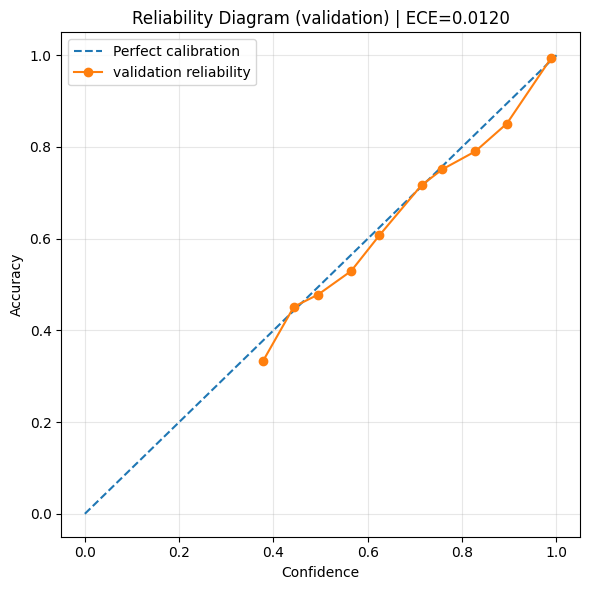

validation ECE: 0.012040258474336544
Saved: /kaggle/working/tinyagrivqa_bn_portion4/calibration/validation_reliability_bins.csv
Saved: /kaggle/working/tinyagrivqa_bn_portion4/figures/validation_reliability_diagram.png


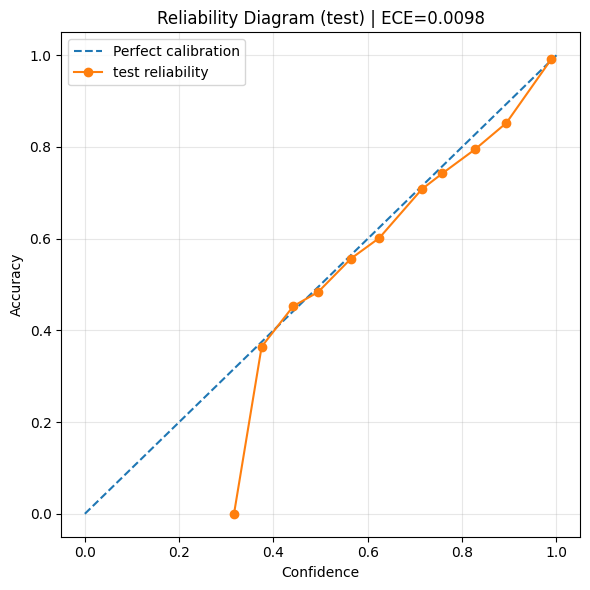

test ECE: 0.009827596856542305
Saved: /kaggle/working/tinyagrivqa_bn_portion4/calibration/test_reliability_bins.csv
Saved: /kaggle/working/tinyagrivqa_bn_portion4/figures/test_reliability_diagram.png


,split,ece
0,validation,0.012040
1,test,0.009828


In [10]:
# ============================================================
# Portion 4 / Cell P4-09: Calibration curves and reliability diagrams
# ============================================================

print("=" * 90)
print("CALIBRATION ANALYSIS")
print("=" * 90)


def reliability_analysis(pred_df, split_name, n_bins=15):
    ece, bin_df = expected_calibration_error_from_conf(
        pred_df["confidence"].values,
        pred_df["correct"].values,
        n_bins=n_bins,
    )

    bin_df["split"] = split_name
    bin_df["ece"] = ece

    save_path = P4_CALIB_DIR / f"{split_name}_reliability_bins.csv"
    bin_df.to_csv(save_path, index=False)

    # Plot reliability diagram
    plot_df = bin_df[bin_df["count"] > 0].copy()
    centers = (plot_df["bin_low"] + plot_df["bin_high"]) / 2.0

    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    plt.plot(plot_df["avg_confidence"], plot_df["accuracy"], marker="o", label=f"{split_name} reliability")
    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.title(f"Reliability Diagram ({split_name}) | ECE={ece:.4f}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    fig_path = P4_FIG_DIR / f"{split_name}_reliability_diagram.png"
    plt.savefig(fig_path, dpi=220, bbox_inches="tight")
    plt.show()

    print(f"{split_name} ECE:", ece)
    print("Saved:", save_path)
    print("Saved:", fig_path)

    return ece, bin_df


val_ece, val_bins = reliability_analysis(val_pred, "validation", n_bins=15)
test_ece, test_bins = reliability_analysis(test_pred, "test", n_bins=15)

calib_summary = pd.DataFrame([
    {"split": "validation", "ece": val_ece},
    {"split": "test", "ece": test_ece},
])

calib_summary.to_csv(P4_CALIB_DIR / "calibration_summary.csv", index=False)

display(calib_summary)

CONFIDENCE THRESHOLD FILTERING


,split,threshold,coverage,kept,rejected,accuracy_on_kept,macro_f1_on_kept,mean_confidence_on_kept,risk_on_kept
0,validation,0.00,1.000000,15596,0,0.807771,0.834537,0.814228,0.192229
1,validation,0.05,1.000000,15596,0,0.807771,0.834537,0.814228,0.192229
2,validation,0.10,1.000000,15596,0,0.807771,0.834537,0.814228,0.192229
3,validation,0.15,1.000000,15596,0,0.807771,0.834537,0.814228,0.192229
4,validation,0.20,1.000000,15596,0,0.807771,0.834537,0.814228,0.192229
5,validation,0.25,1.000000,15596,0,0.807771,0.834537,0.814228,0.192229
6,validation,0.30,1.000000,15596,0,0.807771,0.834537,0.814228,0.192229
7,validation,0.35,0.999744,15592,4,0.807914,0.836355,0.814350,0.192086
8,validation,0.40,0.997115,15551,45,0.809144,0.837466,0.815490,0.190856
9,validation,0.45,0.980828,15297,299,0.814866,0.844987,0.821859,0.185134


Saved: /kaggle/working/tinyagrivqa_bn_portion4/calibration/confidence_threshold_table.csv


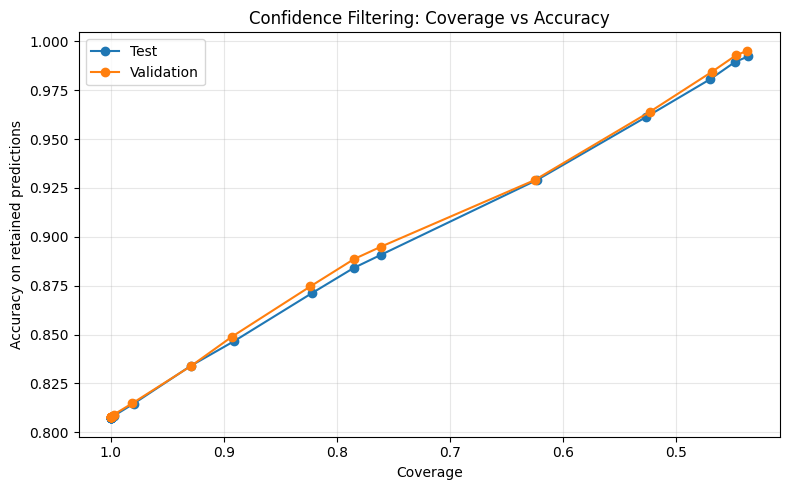

Saved: /kaggle/working/tinyagrivqa_bn_portion4/figures/confidence_filtering_coverage_accuracy.png


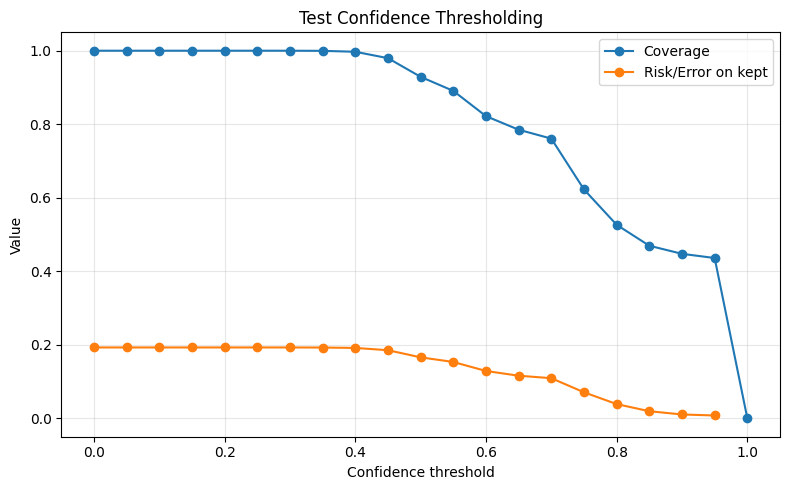

Saved: /kaggle/working/tinyagrivqa_bn_portion4/figures/test_confidence_thresholding.png

Recommended thresholds:


,split,threshold,coverage,kept,rejected,accuracy_on_kept,macro_f1_on_kept,mean_confidence_on_kept,risk_on_kept
14,test,0.70,0.760872,29394,9238,0.890794,0.895242,0.897324,0.109206
13,test,0.65,0.785100,30330,8302,0.884042,0.883399,0.890671,0.115958
12,test,0.60,0.822013,31756,6876,0.871174,0.872926,0.878488,0.128826
11,test,0.55,0.890712,34410,4222,0.846672,0.864691,0.854670,0.153328
10,test,0.50,0.928919,35886,2746,0.834086,0.858120,0.841314,0.165914
9,test,0.45,0.979732,37849,783,0.814658,0.847442,0.822388,0.185342
8,test,0.40,0.997127,38521,111,0.808494,0.838594,0.815563,0.191506
7,test,0.35,0.999663,38619,13,0.807401,0.834726,0.814452,0.192599
6,test,0.30,0.999974,38631,1,0.807201,0.834154,0.814304,0.192799
0,test,0.00,1.000000,38632,0,0.807181,0.834119,0.814290,0.192819


Saved: /kaggle/working/tinyagrivqa_bn_portion4/calibration/recommended_confidence_thresholds.csv


In [11]:
# ============================================================
# Portion 4 / Cell P4-10: Confidence-threshold filtering
# ============================================================

print("=" * 90)
print("CONFIDENCE THRESHOLD FILTERING")
print("=" * 90)


def threshold_table(pred_df, split_name, thresholds=None):
    if thresholds is None:
        thresholds = np.round(np.arange(0.00, 1.001, 0.05), 2)

    rows = []

    total = len(pred_df)

    for th in thresholds:
        kept = pred_df[pred_df["confidence"] >= th].copy()
        rejected = total - len(kept)

        if len(kept) > 0:
            acc = float(kept["correct"].mean())
            y_true = kept["gold_answer_id"].astype(int).values
            y_pred = kept["pred_answer_id"].astype(int).values
            macro_f1 = float(f1_score(y_true, y_pred, average="macro", zero_division=0))
            mean_conf = float(kept["confidence"].mean())
        else:
            acc = np.nan
            macro_f1 = np.nan
            mean_conf = np.nan

        rows.append({
            "split": split_name,
            "threshold": float(th),
            "coverage": float(len(kept) / total),
            "kept": int(len(kept)),
            "rejected": int(rejected),
            "accuracy_on_kept": acc,
            "macro_f1_on_kept": macro_f1,
            "mean_confidence_on_kept": mean_conf,
            "risk_on_kept": float(1.0 - acc) if not np.isnan(acc) else np.nan,
        })

    return pd.DataFrame(rows)


val_thresholds = threshold_table(val_pred, "validation")
test_thresholds = threshold_table(test_pred, "test")

thresholds_all = pd.concat([val_thresholds, test_thresholds], axis=0).reset_index(drop=True)
thresholds_save = P4_CALIB_DIR / "confidence_threshold_table.csv"
thresholds_all.to_csv(thresholds_save, index=False)

display(thresholds_all)

print("Saved:", thresholds_save)

# Plot coverage vs accuracy
plt.figure(figsize=(8, 5))
plt.plot(test_thresholds["coverage"], test_thresholds["accuracy_on_kept"], marker="o", label="Test")
plt.plot(val_thresholds["coverage"], val_thresholds["accuracy_on_kept"], marker="o", label="Validation")
plt.xlabel("Coverage")
plt.ylabel("Accuracy on retained predictions")
plt.title("Confidence Filtering: Coverage vs Accuracy")
plt.gca().invert_xaxis()
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

fig_path = P4_FIG_DIR / "confidence_filtering_coverage_accuracy.png"
plt.savefig(fig_path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

# Plot threshold vs coverage/risk
plt.figure(figsize=(8, 5))
plt.plot(test_thresholds["threshold"], test_thresholds["coverage"], marker="o", label="Coverage")
plt.plot(test_thresholds["threshold"], test_thresholds["risk_on_kept"], marker="o", label="Risk/Error on kept")
plt.xlabel("Confidence threshold")
plt.ylabel("Value")
plt.title("Test Confidence Thresholding")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

fig_path = P4_FIG_DIR / "test_confidence_thresholding.png"
plt.savefig(fig_path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

# Recommended thresholds
recommended = test_thresholds[
    (test_thresholds["coverage"] >= 0.70)
    & (test_thresholds["accuracy_on_kept"] >= test_pred["correct"].mean())
].sort_values(["accuracy_on_kept", "coverage"], ascending=[False, False])

recommended_save = P4_CALIB_DIR / "recommended_confidence_thresholds.csv"
recommended.to_csv(recommended_save, index=False)

print("\nRecommended thresholds:")
display(recommended.head(10))
print("Saved:", recommended_save)

In [12]:
# ============================================================
# Portion 4 / Cell P4-11: Rebuild model and dataset for ablation/Grad-CAM
# ============================================================

print("=" * 90)
print("REBUILD MODEL AND DATASET")
print("=" * 90)

TOKEN_RE = re.compile(r"[\u0980-\u09FF]+|[A-Za-z0-9]+|[^\s]", flags=re.UNICODE)


class BengaliWordTokenizer:
    def __init__(self, max_vocab_size=12000, min_freq=1, max_len=48):
        self.max_vocab_size = max_vocab_size
        self.min_freq = min_freq
        self.max_len = max_len

        self.pad_token = "<pad>"
        self.unk_token = "<unk>"
        self.cls_token = "<cls>"
        self.sep_token = "<sep>"

        self.token_to_id = {
            self.pad_token: 0,
            self.unk_token: 1,
            self.cls_token: 2,
            self.sep_token: 3,
        }
        self.id_to_token = {v: k for k, v in self.token_to_id.items()}

    def tokenize(self, text):
        text = "" if pd.isna(text) else str(text)
        return TOKEN_RE.findall(text.strip())

    def encode(self, text):
        tokens = [self.cls_token] + self.tokenize(text)[: self.max_len - 2] + [self.sep_token]
        ids = [self.token_to_id.get(tok, self.token_to_id[self.unk_token]) for tok in tokens]

        attention_mask = [1] * len(ids)

        pad_len = self.max_len - len(ids)
        if pad_len > 0:
            ids += [self.token_to_id[self.pad_token]] * pad_len
            attention_mask += [0] * pad_len

        return np.array(ids, dtype=np.int64), np.array(attention_mask, dtype=np.int64)

    def encode_empty(self):
        ids = [self.token_to_id[self.cls_token], self.token_to_id[self.sep_token]]
        mask = [1, 1]

        pad_len = self.max_len - len(ids)
        ids += [self.token_to_id[self.pad_token]] * pad_len
        mask += [0] * pad_len

        return np.array(ids, dtype=np.int64), np.array(mask, dtype=np.int64)

    @classmethod
    def load(cls, path):
        with open(path, "r", encoding="utf-8") as f:
            obj = json.load(f)

        tok = cls(
            max_vocab_size=obj["max_vocab_size"],
            min_freq=obj["min_freq"],
            max_len=obj["max_len"],
        )

        tok.token_to_id = {k: int(v) for k, v in obj["token_to_id"].items()}
        tok.id_to_token = {int(v): k for k, v in tok.token_to_id.items()}
        return tok


tokenizer = BengaliWordTokenizer.load(P2_TOKENIZER_JSON)


try:
    import torchvision
    from torchvision import transforms
    TORCHVISION_OK = True
    print("torchvision:", torchvision.__version__)
except Exception as e:
    TORCHVISION_OK = False
    print("torchvision unavailable:", repr(e))


class SimpleImageTransform:
    def __init__(self, image_size=224):
        self.image_size = image_size
        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self.std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    def __call__(self, img):
        img = img.resize((self.image_size, self.image_size))
        arr = np.array(img).astype(np.float32) / 255.0
        x = torch.from_numpy(arr).permute(2, 0, 1)
        x = (x - self.mean) / self.std
        return x


def build_image_transform(image_size=224):
    if TORCHVISION_OK:
        return transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
            ),
        ])

    return SimpleImageTransform(image_size=image_size)


class TinyAgriVQAFastEvalDataset(Dataset):
    def __init__(self, df, tokenizer, image_transform=None, split_name="test", text_mode="normal"):
        self.df = df.reset_index(drop=True).copy()
        self.tokenizer = tokenizer
        self.image_transform = image_transform
        self.split_name = split_name
        self.text_mode = text_mode

        self.image_paths = self.df["resolved_image_path"].astype(str).tolist()
        self.qa_ids = self.df["qa_id"].astype(str).tolist()
        self.image_ids = self.df["image_id"].astype(str).tolist()

        questions = self.df["bangla_question"].fillna("").astype(str).tolist()

        ids_list = []
        mask_list = []

        for q in tqdm(questions, desc=f"pre-encode {split_name} | text_mode={text_mode}"):
            if text_mode == "empty":
                ids, mask = tokenizer.encode_empty()
            else:
                ids, mask = tokenizer.encode(q)

            ids_list.append(ids)
            mask_list.append(mask)

        self.input_ids = np.stack(ids_list, axis=0).astype(np.int64)
        self.attention_masks = np.stack(mask_list, axis=0).astype(np.int64)

        self.answer_ids = self.df["p2_answer_id"].astype(np.int64).values
        self.crop_ids = self.df["p2_crop_id"].astype(np.int64).values
        self.disease_ids = self.df["p2_disease_id"].astype(np.int64).values
        self.class_ids = self.df["p2_class_id"].astype(np.int64).values

        self.crop_masks = self.df["p2_crop_loss_mask"].astype(np.float32).values
        self.disease_masks = self.df["p2_disease_loss_mask"].astype(np.float32).values
        self.class_masks = self.df["p2_class_loss_mask"].astype(np.float32).values

    def __len__(self):
        return len(self.df)

    def _load_image(self, path):
        try:
            with Image.open(path) as img:
                return img.convert("RGB")
        except Exception:
            return Image.new("RGB", (224, 224), color=(0, 0, 0))

    def __getitem__(self, idx):
        img = self._load_image(self.image_paths[idx])

        if self.image_transform is not None:
            img = self.image_transform(img)

        return {
            "image": img.float(),
            "input_ids": torch.from_numpy(self.input_ids[idx]).long(),
            "attention_mask": torch.from_numpy(self.attention_masks[idx]).long(),

            "answer_id": torch.tensor(self.answer_ids[idx], dtype=torch.long),
            "crop_id": torch.tensor(self.crop_ids[idx], dtype=torch.long),
            "disease_id": torch.tensor(self.disease_ids[idx], dtype=torch.long),
            "class_id": torch.tensor(self.class_ids[idx], dtype=torch.long),

            "crop_loss_mask": torch.tensor(self.crop_masks[idx], dtype=torch.float32),
            "disease_loss_mask": torch.tensor(self.disease_masks[idx], dtype=torch.float32),
            "class_loss_mask": torch.tensor(self.class_masks[idx], dtype=torch.float32),

            "qa_id": self.qa_ids[idx],
            "image_id": self.image_ids[idx],
        }


class FallbackTinyCNN(nn.Module):
    def __init__(self, out_dim=512):
        super().__init__()
        self.out_dim = out_dim

        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.SiLU(),

            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.SiLU(),

            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.SiLU(),

            nn.Conv2d(128, 256, 3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.SiLU(),

            nn.Conv2d(256, out_dim, 3, stride=2, padding=1),
            nn.BatchNorm2d(out_dim),
            nn.SiLU(),

            nn.AdaptiveAvgPool2d(1),
        )

    def forward(self, x):
        return self.net(x).flatten(1)


class ImageEncoder(nn.Module):
    def __init__(self, backbone_name="resnet34", pretrained=False):
        super().__init__()

        if TORCHVISION_OK and backbone_name == "resnet34":
            from torchvision import models
            weights = None
            model = models.resnet34(weights=weights)
            self.out_dim = model.fc.in_features
            model.fc = nn.Identity()
            self.encoder = model

        elif TORCHVISION_OK and backbone_name == "resnet18":
            from torchvision import models
            weights = None
            model = models.resnet18(weights=weights)
            self.out_dim = model.fc.in_features
            model.fc = nn.Identity()
            self.encoder = model

        else:
            self.out_dim = 512
            self.encoder = FallbackTinyCNN(out_dim=self.out_dim)

    def forward(self, images):
        return self.encoder(images)


class TinyTextTransformer(nn.Module):
    def __init__(
        self,
        vocab_size,
        max_len=48,
        d_model=256,
        n_heads=4,
        n_layers=3,
        ff_dim=768,
        dropout=0.10,
        pad_id=0,
    ):
        super().__init__()

        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.pos_emb = nn.Parameter(torch.zeros(1, max_len, d_model))

        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )

        self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

        nn.init.normal_(self.pos_emb, mean=0.0, std=0.02)

    def forward(self, input_ids, attention_mask):
        B, L = input_ids.shape

        x = self.token_emb(input_ids)
        x = x + self.pos_emb[:, :L, :]
        x = self.dropout(x)

        key_padding_mask = attention_mask.eq(0)

        h = self.encoder(x, src_key_padding_mask=key_padding_mask)
        h = self.norm(h)

        mask = attention_mask.unsqueeze(-1).float()
        pooled = (h * mask).sum(dim=1) / mask.sum(dim=1).clamp_min(1.0)

        return pooled, h


class GatedMultimodalFusion(nn.Module):
    def __init__(self, image_dim, text_dim, fusion_dim=512, dropout=0.10):
        super().__init__()

        self.image_proj = nn.Sequential(
            nn.Linear(image_dim, fusion_dim),
            nn.LayerNorm(fusion_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.text_proj = nn.Sequential(
            nn.Linear(text_dim, fusion_dim),
            nn.LayerNorm(fusion_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.gate = nn.Sequential(
            nn.Linear(fusion_dim * 4, fusion_dim),
            nn.GELU(),
            nn.Linear(fusion_dim, fusion_dim),
            nn.Sigmoid(),
        )

        self.out = nn.Sequential(
            nn.LayerNorm(fusion_dim),
            nn.Dropout(dropout),
        )

    def forward(self, image_feat, text_feat):
        v = self.image_proj(image_feat)
        t = self.text_proj(text_feat)
        z = torch.cat([v, t, v * t, torch.abs(v - t)], dim=-1)
        g = self.gate(z)
        fused = g * v + (1.0 - g) * t
        return self.out(fused)


class TinyAgriVQABN(nn.Module):
    def __init__(
        self,
        vocab_size,
        num_answers,
        num_crops,
        num_diseases,
        num_classes,
        max_len=48,
        image_backbone="resnet34",
        image_pretrained=False,
        text_dim=256,
        text_layers=3,
        text_heads=4,
        text_ff_dim=768,
        fusion_dim=512,
        dropout=0.10,
        pad_id=0,
    ):
        super().__init__()

        self.image_encoder = ImageEncoder(
            backbone_name=image_backbone,
            pretrained=image_pretrained,
        )

        self.text_encoder = TinyTextTransformer(
            vocab_size=vocab_size,
            max_len=max_len,
            d_model=text_dim,
            n_heads=text_heads,
            n_layers=text_layers,
            ff_dim=text_ff_dim,
            dropout=dropout,
            pad_id=pad_id,
        )

        self.fusion = GatedMultimodalFusion(
            image_dim=self.image_encoder.out_dim,
            text_dim=text_dim,
            fusion_dim=fusion_dim,
            dropout=dropout,
        )

        self.answer_head = nn.Sequential(
            nn.Linear(fusion_dim, fusion_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_dim, num_answers),
        )

        self.crop_head = nn.Linear(fusion_dim, num_crops)
        self.disease_head = nn.Linear(fusion_dim, num_diseases)
        self.class_head = nn.Linear(fusion_dim, num_classes)

        self.confidence_head = nn.Sequential(
            nn.Linear(fusion_dim, fusion_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_dim // 2, 1),
        )

    def forward(self, images, input_ids, attention_mask):
        image_feat = self.image_encoder(images)
        text_feat, token_features = self.text_encoder(input_ids, attention_mask)
        fused = self.fusion(image_feat, text_feat)

        return {
            "answer_logits": self.answer_head(fused),
            "crop_logits": self.crop_head(fused),
            "disease_logits": self.disease_head(fused),
            "class_logits": self.class_head(fused),
            "confidence_logit": self.confidence_head(fused).squeeze(-1),
            "fused_features": fused,
            "image_features": image_feat,
            "text_features": text_feat,
            "token_features": token_features,
        }


def build_model_from_config(config):
    return TinyAgriVQABN(
        vocab_size=config["vocab_size"],
        num_answers=config["num_answers"],
        num_crops=config["num_crops"],
        num_diseases=config["num_diseases"],
        num_classes=config["num_classes"],
        max_len=config["max_len"],
        image_backbone=config["image_backbone"],
        image_pretrained=config.get("image_pretrained", False),
        text_dim=config["text_dim"],
        text_layers=config["text_layers"],
        text_heads=config["text_heads"],
        text_ff_dim=config["text_ff_dim"],
        fusion_dim=config["fusion_dim"],
        dropout=config["dropout"],
        pad_id=config["pad_id"],
    )


def safe_torch_load(path, map_location="cpu"):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)


ckpt = safe_torch_load(BEST_CKPT, map_location="cpu")

eval_model = build_model_from_config(ckpt["model_config"])
eval_model.load_state_dict(ckpt["model_state_dict"], strict=True)
eval_model = eval_model.to(DEVICE)
eval_model.eval()

eval_transform = build_image_transform(image_size=ckpt["model_config"].get("image_size", 224))

print("Model loaded.")
print("Checkpoint epoch:", ckpt["epoch"])
print("Best metric:", ckpt["best_metric"])

REBUILD MODEL AND DATASET
torchvision: 0.25.0+cu128
Model loaded.
Checkpoint epoch: 11
Best metric: 0.834537089217096


INFERENCE-TIME MODALITY ABLATIONS


pre-encode test_empty | text_mode=empty:   0%|          | 0/38632 [00:00<?, ?it/s]

ablation empty_text_real_image:   0%|          | 0/302 [00:00<?, ?it/s]

pre-encode test_normal | text_mode=normal:   0%|          | 0/38632 [00:00<?, ?it/s]

ablation zero_image_real_text:   0%|          | 0/302 [00:00<?, ?it/s]

,mode,rows,accuracy,macro_f1,weighted_f1,ece,mean_confidence,accuracy_drop_vs_full,macro_f1_drop_vs_full
0,full,38632,0.807181,0.834119,0.794158,0.009828,0.814290,0.000000,0.000000
1,empty_text_real_image,38632,0.247179,0.004556,0.097977,0.262307,0.509485,0.560002,0.829563
2,zero_image_real_text,38632,0.373628,0.045733,0.312972,0.468184,0.841631,0.433552,0.788385


Saved: /kaggle/working/tinyagrivqa_bn_portion4/ablation/inference_modality_ablation.csv


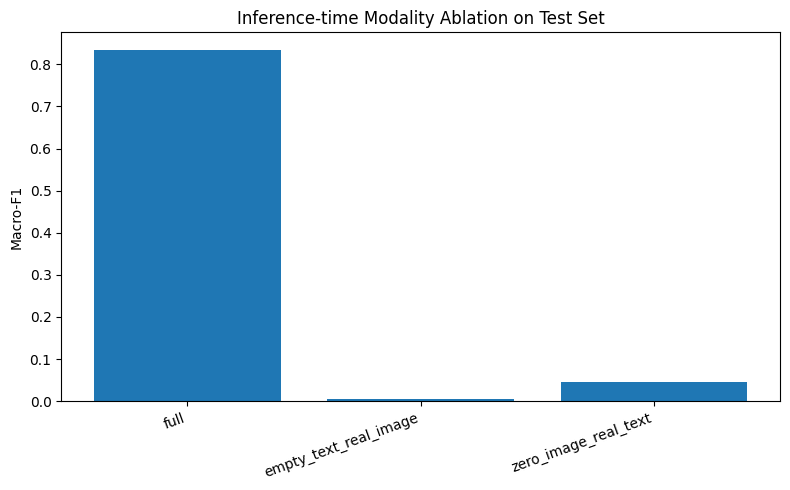

Saved: /kaggle/working/tinyagrivqa_bn_portion4/figures/test_modality_ablation_macro_f1.png


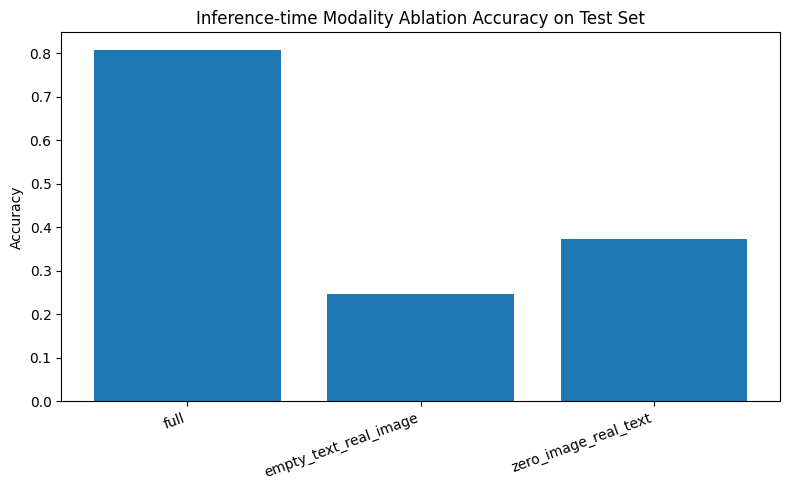

Saved: /kaggle/working/tinyagrivqa_bn_portion4/figures/test_modality_ablation_accuracy.png


In [13]:
# ============================================================
# Portion 4 / Cell P4-12: Inference-time modality ablations
# ============================================================

print("=" * 90)
print("INFERENCE-TIME MODALITY ABLATIONS")
print("=" * 90)


class P4EvalConfig:
    eval_batch_size = 128
    num_workers = 0
    pin_memory = True


def build_eval_loader(df, text_mode="normal"):
    ds = TinyAgriVQAFastEvalDataset(
        df,
        tokenizer,
        image_transform=eval_transform,
        split_name=f"test_{text_mode}",
        text_mode=text_mode,
    )

    loader = DataLoader(
        ds,
        batch_size=P4EvalConfig.eval_batch_size,
        shuffle=False,
        num_workers=P4EvalConfig.num_workers,
        pin_memory=bool(torch.cuda.is_available() and P4EvalConfig.pin_memory),
        drop_last=False,
    )

    return loader


def evaluate_ablation_mode(model, loader, device, mode="full"):
    model.eval()

    all_pred = []
    all_gold = []
    all_conf = []

    with torch.no_grad():
        for batch in tqdm(loader, desc=f"ablation {mode}"):
            images = batch["image"].to(device, non_blocking=True)
            input_ids = batch["input_ids"].to(device, non_blocking=True)
            attention_mask = batch["attention_mask"].to(device, non_blocking=True)
            gold = batch["answer_id"].to(device, non_blocking=True)

            if mode == "zero_image":
                images = torch.zeros_like(images)

            outputs = model(
                images=images,
                input_ids=input_ids,
                attention_mask=attention_mask,
            )

            probs = F.softmax(outputs["answer_logits"], dim=-1)
            conf, pred = probs.max(dim=-1)

            all_pred.append(pred.detach().cpu())
            all_gold.append(gold.detach().cpu())
            all_conf.append(conf.detach().cpu())

    y_pred = torch.cat(all_pred).numpy()
    y_true = torch.cat(all_gold).numpy()
    conf = torch.cat(all_conf).numpy()
    correct = (y_true == y_pred).astype(np.int64)

    ece, _ = expected_calibration_error_from_conf(conf, correct, n_bins=15)

    return {
        "mode": mode,
        "rows": int(len(y_true)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "ece": float(ece),
        "mean_confidence": float(np.mean(conf)),
    }


# Full model metrics from saved predictions.
full_test_metrics = prediction_summary_metrics(test_pred, "test")
full_test_metrics["mode"] = "full"

# Text ablation: empty question, real image.
empty_text_loader = build_eval_loader(p2_test, text_mode="empty")
text_abl_metrics = evaluate_ablation_mode(
    eval_model,
    empty_text_loader,
    DEVICE,
    mode="empty_text_real_image",
)

# Image ablation: real question, zero image.
normal_text_loader = build_eval_loader(p2_test, text_mode="normal")
image_abl_metrics = evaluate_ablation_mode(
    eval_model,
    normal_text_loader,
    DEVICE,
    mode="zero_image_real_text",
)

ablation_df = pd.DataFrame([
    {
        "mode": "full",
        "rows": full_test_metrics["rows"],
        "accuracy": full_test_metrics["accuracy"],
        "macro_f1": full_test_metrics["macro_f1"],
        "weighted_f1": full_test_metrics["weighted_f1"],
        "ece": full_test_metrics["ece"],
        "mean_confidence": full_test_metrics["mean_confidence"],
    },
    text_abl_metrics,
    image_abl_metrics,
])

# Add drops relative to full.
full_acc = float(ablation_df.loc[ablation_df["mode"] == "full", "accuracy"].iloc[0])
full_f1 = float(ablation_df.loc[ablation_df["mode"] == "full", "macro_f1"].iloc[0])

ablation_df["accuracy_drop_vs_full"] = full_acc - ablation_df["accuracy"]
ablation_df["macro_f1_drop_vs_full"] = full_f1 - ablation_df["macro_f1"]

ablation_save = P4_ABLATION_DIR / "inference_modality_ablation.csv"
ablation_df.to_csv(ablation_save, index=False)

display(ablation_df)
print("Saved:", ablation_save)

# Plot ablation macro-F1
plt.figure(figsize=(8, 5))
plt.bar(ablation_df["mode"], ablation_df["macro_f1"])
plt.ylabel("Macro-F1")
plt.title("Inference-time Modality Ablation on Test Set")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

fig_path = P4_FIG_DIR / "test_modality_ablation_macro_f1.png"
plt.savefig(fig_path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

# Plot accuracy
plt.figure(figsize=(8, 5))
plt.bar(ablation_df["mode"], ablation_df["accuracy"])
plt.ylabel("Accuracy")
plt.title("Inference-time Modality Ablation Accuracy on Test Set")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

fig_path = P4_FIG_DIR / "test_modality_ablation_accuracy.png"
plt.savefig(fig_path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

ROBUSTNESS SUBGROUP ANALYSIS


,group_type,group_value,rows,accuracy,macro_f1,mean_confidence
0,has_unknown_crop,False,14240,0.951124,0.763986,0.897121
1,has_unknown_crop,True,24392,0.723147,0.302294,0.765934
2,has_unknown_disease,False,16832,0.951521,0.873798,0.954222
3,has_unknown_disease,True,21800,0.695734,0.357569,0.706248
4,has_unknown_class,False,16832,0.951521,0.873798,0.954222
5,has_unknown_class,True,21800,0.695734,0.357569,0.706248
6,any_unknown_aux,False,10855,0.990051,0.768301,0.980585
7,any_unknown_aux,True,27777,0.735717,0.455220,0.749304
8,confidence_quartile,Q1_lowest,9658,0.548354,0.459517,0.556870
9,confidence_quartile,Q2,9658,0.740733,0.701964,0.754231


Saved: /kaggle/working/tinyagrivqa_bn_portion4/tables/robustness_subgroup_metrics.csv


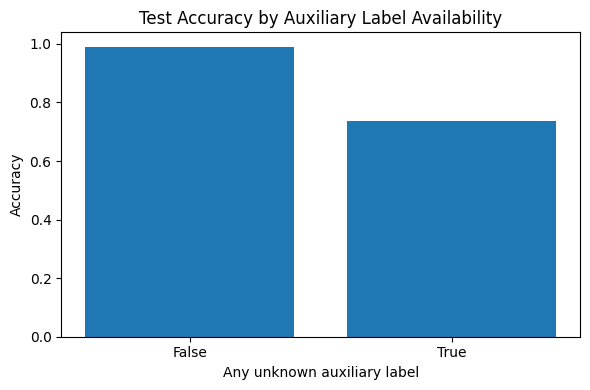

Saved: /kaggle/working/tinyagrivqa_bn_portion4/figures/test_accuracy_by_unknown_aux_label.png


In [14]:
# ============================================================
# Portion 4 / Cell P4-13: Robustness-style subgroup analysis
# ============================================================

print("=" * 90)
print("ROBUSTNESS SUBGROUP ANALYSIS")
print("=" * 90)

robust_rows = []

# 1. Manual-like label quality proxy using unknown labels.
test_aug = test_pred.copy()

test_aug["has_unknown_crop"] = test_aug["p2_crop_label"].eq("unknown")
test_aug["has_unknown_disease"] = test_aug["p2_disease_label"].eq("unknown")
test_aug["has_unknown_class"] = test_aug["p2_class_label"].eq("unknown_unknown")
test_aug["any_unknown_aux"] = (
    test_aug["has_unknown_crop"] |
    test_aug["has_unknown_disease"] |
    test_aug["has_unknown_class"]
)

for col in ["has_unknown_crop", "has_unknown_disease", "has_unknown_class", "any_unknown_aux"]:
    for val, g in test_aug.groupby(col):
        if len(g) == 0:
            continue

        robust_rows.append({
            "group_type": col,
            "group_value": str(val),
            "rows": int(len(g)),
            "accuracy": float(g["correct"].mean()),
            "macro_f1": float(f1_score(g["gold_answer_id"], g["pred_answer_id"], average="macro", zero_division=0)),
            "mean_confidence": float(g["confidence"].mean()),
        })

# 2. Confidence quartiles.
test_aug["confidence_quartile"] = pd.qcut(
    test_aug["confidence"],
    q=4,
    labels=["Q1_lowest", "Q2", "Q3", "Q4_highest"],
    duplicates="drop",
)

for val, g in test_aug.groupby("confidence_quartile"):
    robust_rows.append({
        "group_type": "confidence_quartile",
        "group_value": str(val),
        "rows": int(len(g)),
        "accuracy": float(g["correct"].mean()),
        "macro_f1": float(f1_score(g["gold_answer_id"], g["pred_answer_id"], average="macro", zero_division=0)),
        "mean_confidence": float(g["confidence"].mean()),
    })

robust_df = pd.DataFrame(robust_rows)

robust_save = P4_TABLE_DIR / "robustness_subgroup_metrics.csv"
robust_df.to_csv(robust_save, index=False)

display(robust_df)

print("Saved:", robust_save)

# Plot unknown aux group
unknown_plot = robust_df[robust_df["group_type"] == "any_unknown_aux"].copy()

plt.figure(figsize=(6, 4))
plt.bar(unknown_plot["group_value"], unknown_plot["accuracy"])
plt.xlabel("Any unknown auxiliary label")
plt.ylabel("Accuracy")
plt.title("Test Accuracy by Auxiliary Label Availability")
plt.tight_layout()

fig_path = P4_FIG_DIR / "test_accuracy_by_unknown_aux_label.png"
plt.savefig(fig_path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

In [15]:
# ============================================================
# Portion 4 / Cell P4-14: Grad-CAM utility
# ============================================================

print("=" * 90)
print("GRAD-CAM UTILITY")
print("=" * 90)


def denormalize_image_tensor(x):
    """
    x: [3, H, W], normalized tensor
    """
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    y = x.detach().cpu() * std + mean
    y = y.clamp(0, 1)
    return y.permute(1, 2, 0).numpy()


class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        self.fwd_handle = self.target_layer.register_forward_hook(self.forward_hook)
        self.bwd_handle = self.target_layer.register_full_backward_hook(self.backward_hook)

    def forward_hook(self, module, inp, out):
        self.activations = out.detach()

    def backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def remove(self):
        self.fwd_handle.remove()
        self.bwd_handle.remove()

    def __call__(self, images, input_ids, attention_mask, target_class=None):
        self.model.zero_grad(set_to_none=True)

        outputs = self.model(
            images=images,
            input_ids=input_ids,
            attention_mask=attention_mask,
        )

        logits = outputs["answer_logits"]

        if target_class is None:
            target_class = logits.argmax(dim=-1)

        score = logits[torch.arange(logits.shape[0], device=logits.device), target_class]
        score.sum().backward()

        # activations: [B, C, H, W]
        # gradients: [B, C, H, W]
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1)
        cam = F.relu(cam)

        cam = F.interpolate(
            cam.unsqueeze(1),
            size=images.shape[-2:],
            mode="bilinear",
            align_corners=False,
        ).squeeze(1)

        cam_min = cam.flatten(1).min(dim=1)[0].view(-1, 1, 1)
        cam_max = cam.flatten(1).max(dim=1)[0].view(-1, 1, 1)

        cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)

        return cam.detach(), outputs


def find_resnet_last_conv_layer(model):
    """
    For torchvision ResNet: model.image_encoder.encoder.layer4[-1].conv2.
    """
    try:
        return model.image_encoder.encoder.layer4[-1].conv2
    except Exception:
        pass

    # Fallback: last Conv2d in image encoder
    last_conv = None
    for module in model.image_encoder.modules():
        if isinstance(module, nn.Conv2d):
            last_conv = module

    if last_conv is None:
        raise RuntimeError("Could not find Conv2d layer for Grad-CAM.")

    return last_conv


target_layer = find_resnet_last_conv_layer(eval_model)
print("Grad-CAM target layer:", target_layer)


def make_single_item_from_row(row, tokenizer, transform):
    img_path = row["resolved_image_path"]

    try:
        img_raw = Image.open(img_path).convert("RGB")
    except Exception:
        img_raw = Image.new("RGB", (224, 224), color=(0, 0, 0))

    img_tensor = transform(img_raw).float()

    ids, mask = tokenizer.encode(row["bangla_question"])

    item = {
        "image": img_tensor.unsqueeze(0),
        "input_ids": torch.from_numpy(ids).long().unsqueeze(0),
        "attention_mask": torch.from_numpy(mask).long().unsqueeze(0),
        "raw_image": img_raw,
    }

    return item


def save_gradcam_overlay(row, save_path, title=None):
    eval_model.eval()

    item = make_single_item_from_row(row, tokenizer, eval_transform)

    images = item["image"].to(DEVICE)
    input_ids = item["input_ids"].to(DEVICE)
    attention_mask = item["attention_mask"].to(DEVICE)

    gradcam = GradCAM(eval_model, target_layer)

    cam, outputs = gradcam(
        images=images,
        input_ids=input_ids,
        attention_mask=attention_mask,
        target_class=None,
    )

    gradcam.remove()

    probs = F.softmax(outputs["answer_logits"], dim=-1)
    conf, pred = probs.max(dim=-1)

    img_np = denormalize_image_tensor(item["image"][0])
    cam_np = cam[0].detach().cpu().numpy()

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(img_np)
    plt.axis("off")
    plt.title("Image")

    plt.subplot(1, 3, 2)
    plt.imshow(cam_np, cmap="jet")
    plt.axis("off")
    plt.title("Grad-CAM")

    plt.subplot(1, 3, 3)
    plt.imshow(img_np)
    plt.imshow(cam_np, cmap="jet", alpha=0.45)
    plt.axis("off")
    plt.title("Overlay")

    if title is not None:
        plt.suptitle(title, fontsize=10)

    plt.tight_layout()
    plt.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.show()

    return {
        "pred_answer_id": int(pred.item()),
        "confidence": float(conf.item()),
        "save_path": str(save_path),
    }


print("Grad-CAM utilities ready.")

GRAD-CAM UTILITY
Grad-CAM target layer: Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
Grad-CAM utilities ready.


GENERATING GRAD-CAM VISUAL EVIDENCE


gradcam:   0%|          | 0/20 [00:00<?, ?it/s]

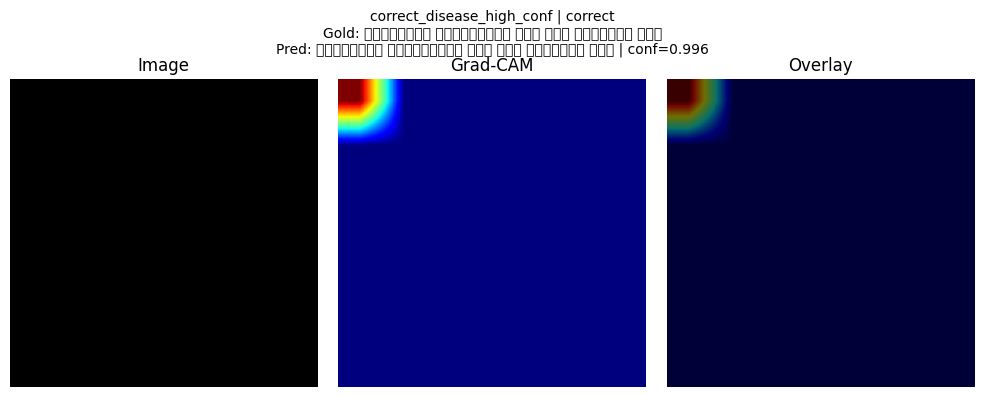

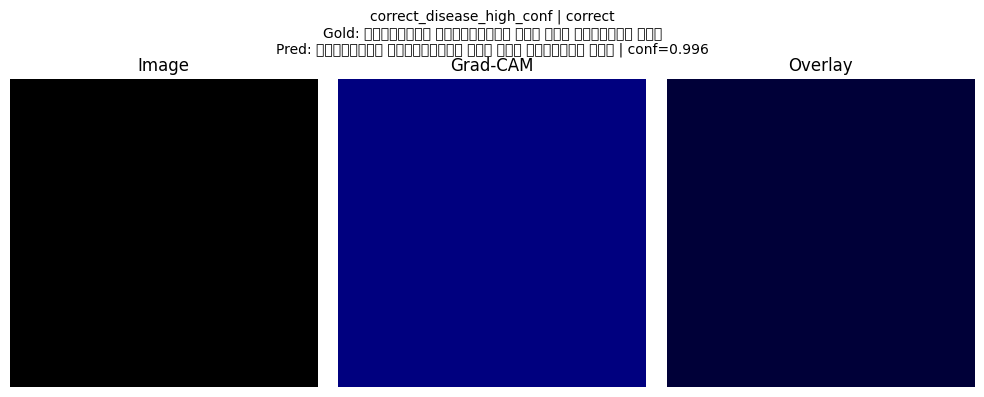

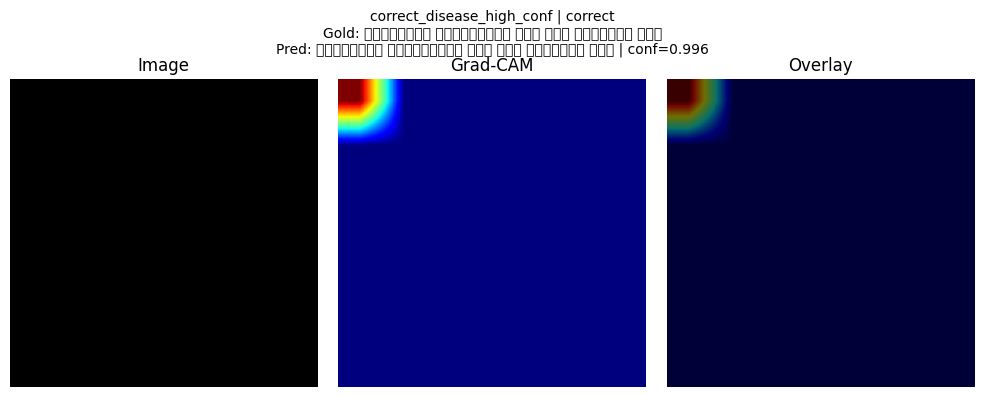

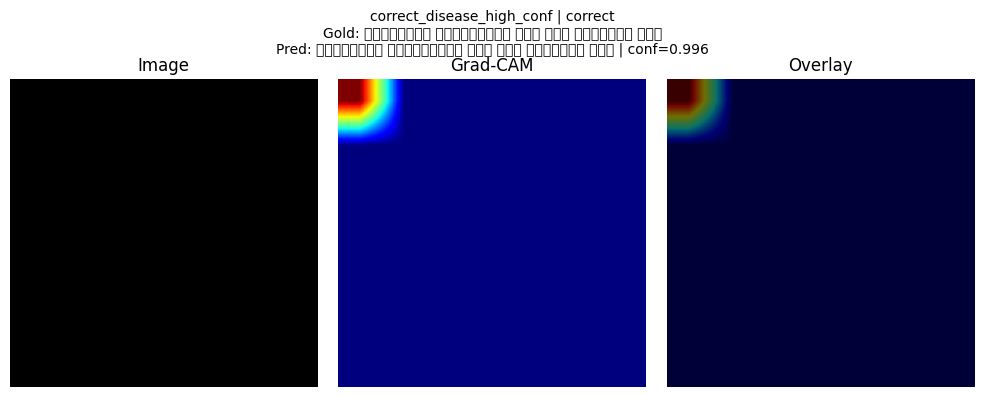

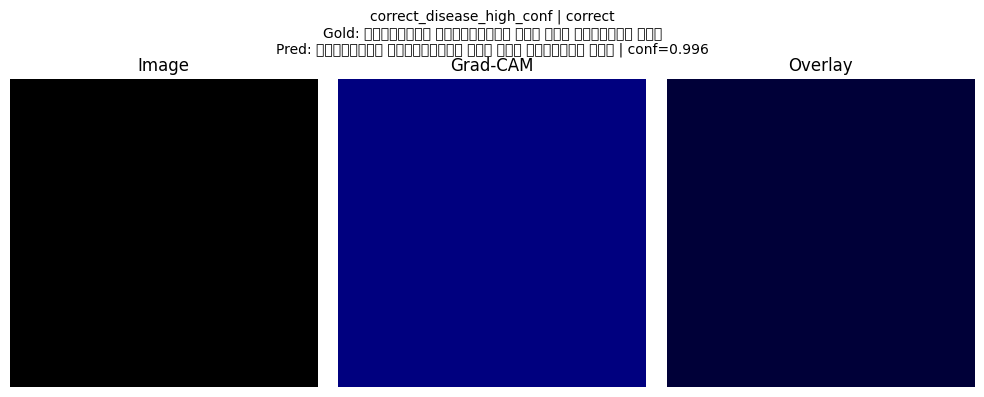

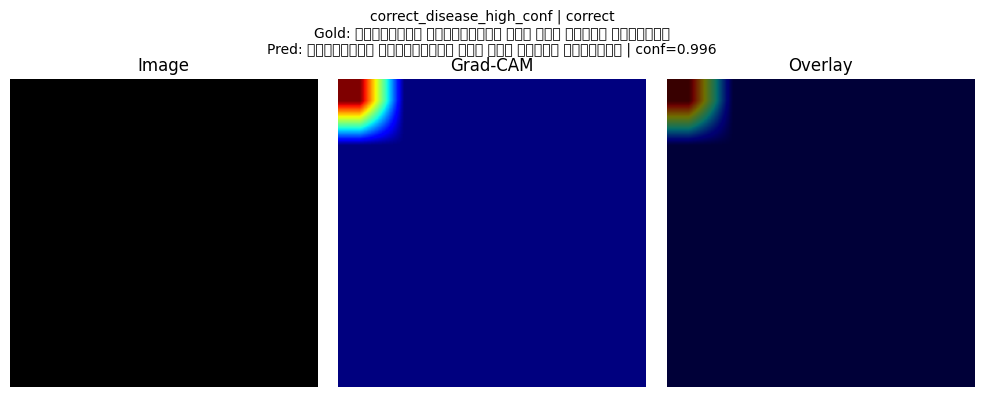

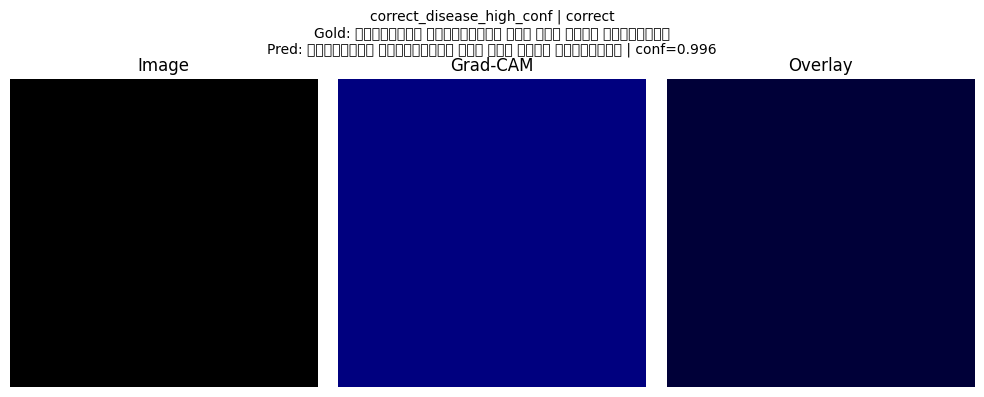

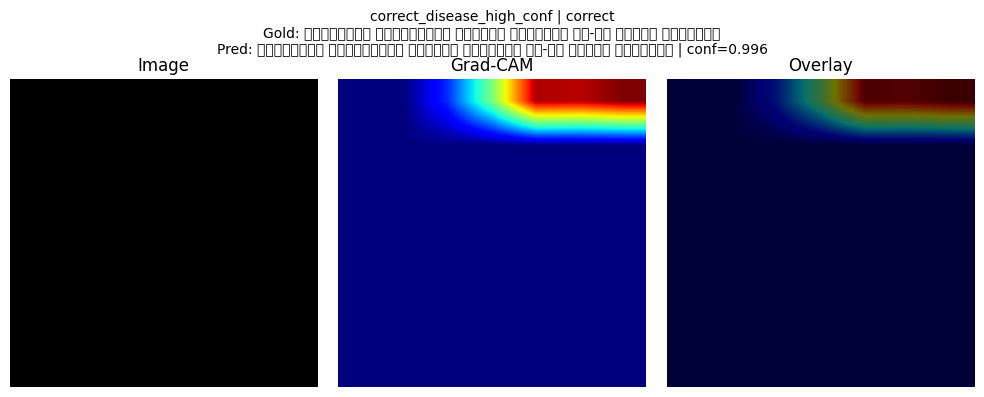

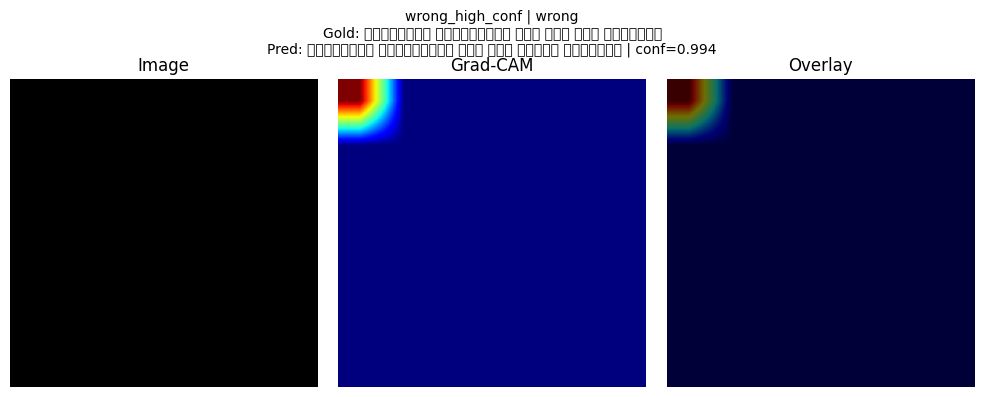

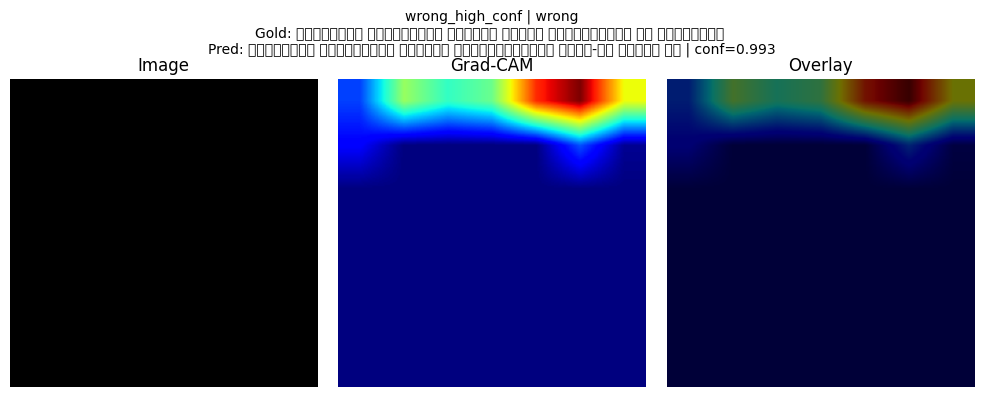

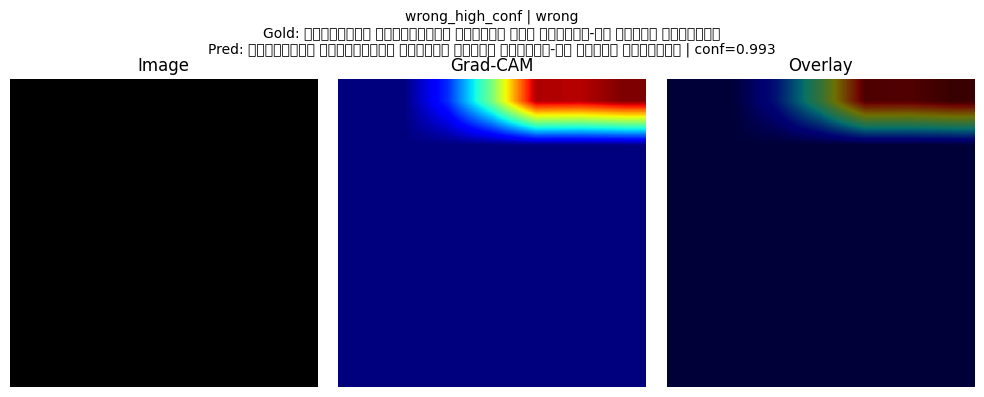

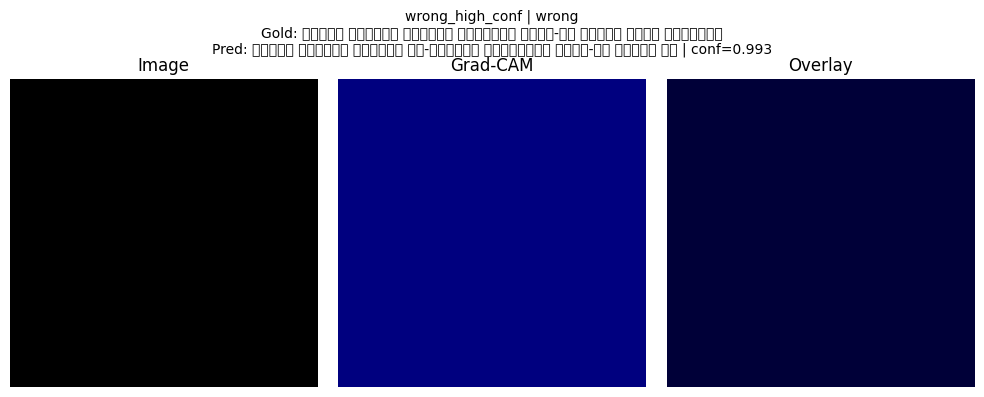

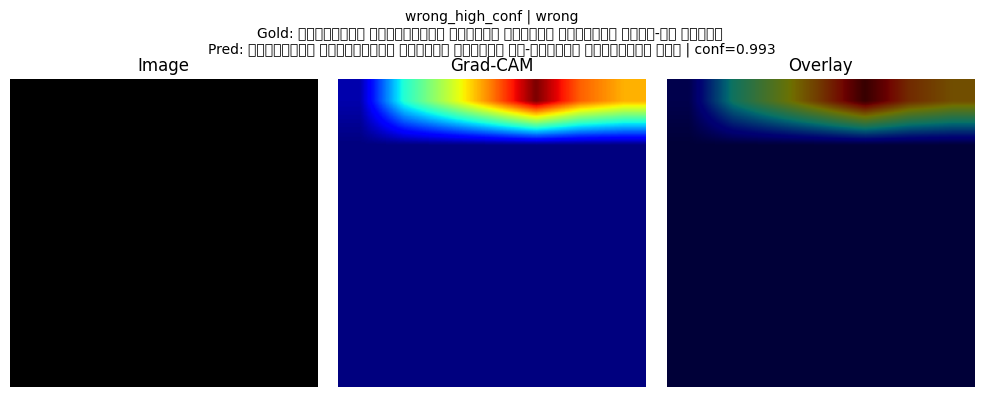

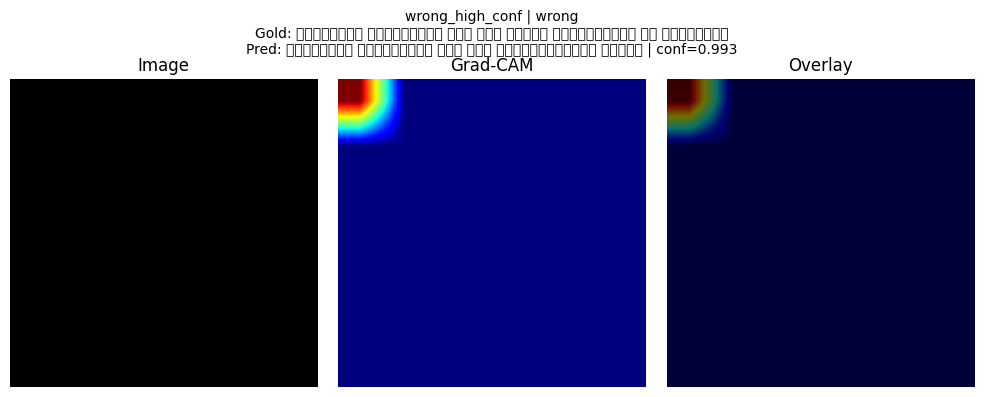

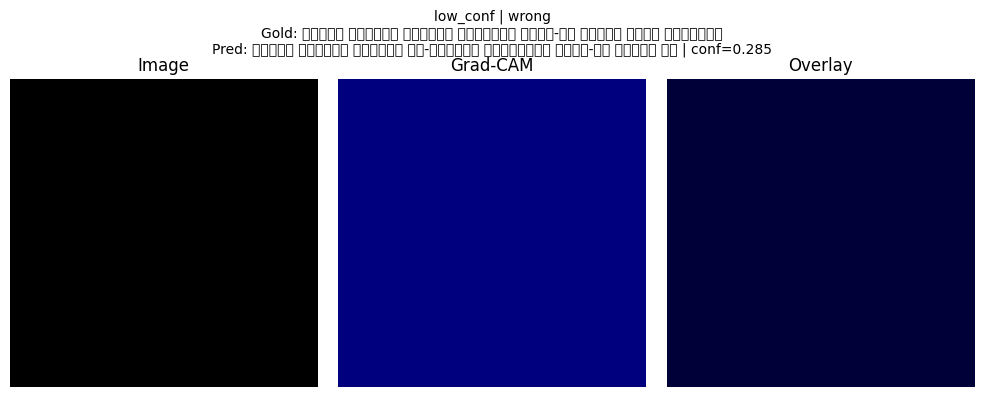

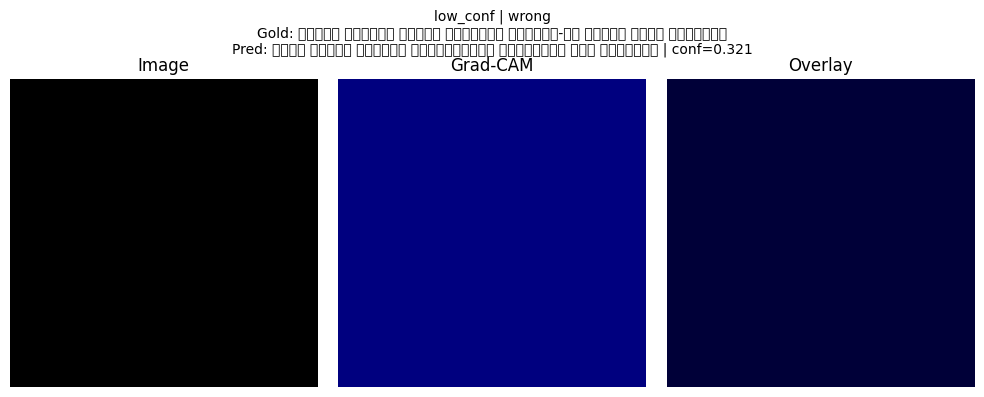

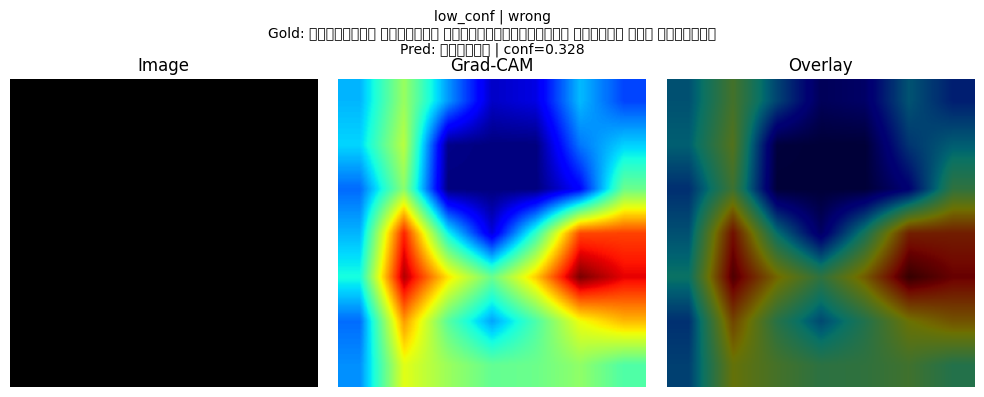

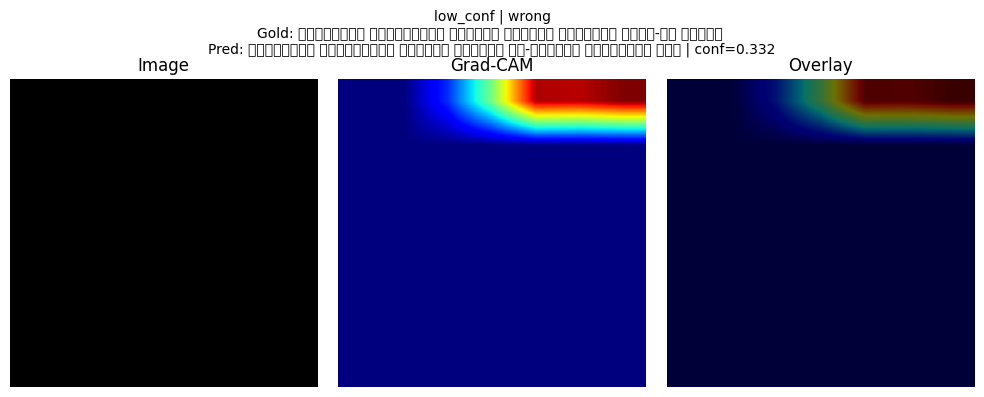

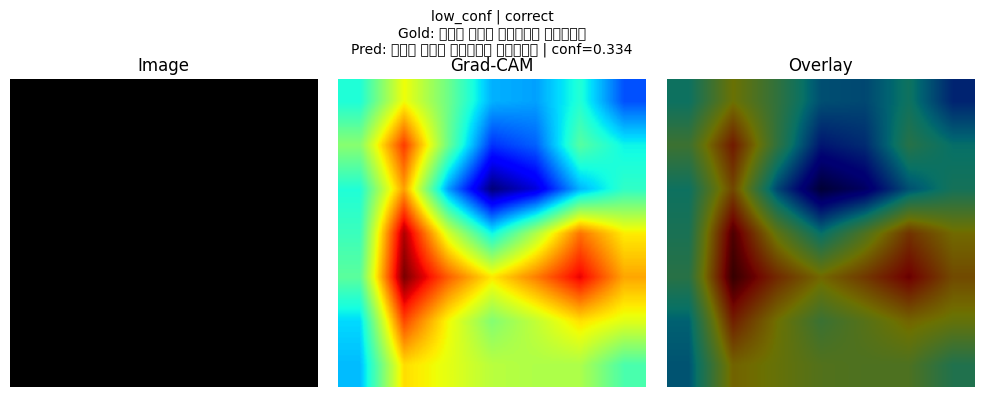

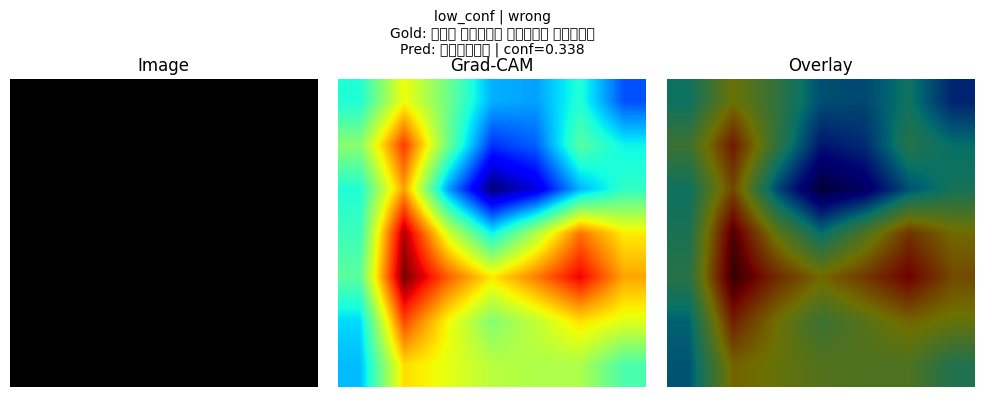

,idx,qa_id,image_id,group,correct,gold_answer_text,pred_answer_text,confidence,question_type,p2_crop_label,p2_disease_label,p2_class_label,gradcam_path
0,0,f92ee4d5846d3849,image_044662.JPG,correct_disease_high_conf,1,সম্ভাব্য নির্দিষ্ট রোগ হলো ব্ল্যাক রট।,সম্ভাব্য নির্দিষ্ট রোগ হলো ব্ল্যাক রট।,0.996026,Specific Disease Identification,unknown,black_rot_general,black_rot_general,/kaggle/working/tinyagrivqa_bn_portion4/gradca...
1,1,c83c5b3cf8689844,image_046769.JPG,correct_disease_high_conf,1,সম্ভাব্য নির্দিষ্ট রোগ হলো ব্ল্যাক রট।,সম্ভাব্য নির্দিষ্ট রোগ হলো ব্ল্যাক রট।,0.995966,Specific Disease Identification,unknown,black_rot_general,black_rot_general,/kaggle/working/tinyagrivqa_bn_portion4/gradca...
2,2,87564df13bfced6e,image_053991.JPG,correct_disease_high_conf,1,সম্ভাব্য নির্দিষ্ট রোগ হলো ব্ল্যাক রট।,সম্ভাব্য নির্দিষ্ট রোগ হলো ব্ল্যাক রট।,0.995924,Specific Disease Identification,unknown,black_rot_general,black_rot_general,/kaggle/working/tinyagrivqa_bn_portion4/gradca...
3,3,7a01774eb838ca31,image_048446.JPG,correct_disease_high_conf,1,সম্ভাব্য নির্দিষ্ট রোগ হলো ব্ল্যাক রট।,সম্ভাব্য নির্দিষ্ট রোগ হলো ব্ল্যাক রট।,0.995730,Specific Disease Identification,unknown,black_rot_general,black_rot_general,/kaggle/working/tinyagrivqa_bn_portion4/gradca...
4,4,5e3ca0650b254a55,image_047410.JPG,correct_disease_high_conf,1,সম্ভাব্য নির্দিষ্ট রোগ হলো ব্ল্যাক রট।,সম্ভাব্য নির্দিষ্ট রোগ হলো ব্ল্যাক রট।,0.995690,Specific Disease Identification,unknown,black_rot_general,black_rot_general,/kaggle/working/tinyagrivqa_bn_portion4/gradca...
5,5,c60f2d639ed5ed38,image_052890.JPG,correct_disease_high_conf,1,সম্ভাব্য নির্দিষ্ট রোগ হলো আর্লি ব্লাইট।,সম্ভাব্য নির্দিষ্ট রোগ হলো আর্লি ব্লাইট।,0.995682,Specific Disease Identification,unknown,early_blight_general,early_blight_general,/kaggle/working/tinyagrivqa_bn_portion4/gradca...
6,6,e6e933f56fb59302,image_052702.JPG,correct_disease_high_conf,1,সম্ভাব্য নির্দিষ্ট রোগ হলো আপেল স্ক্যাব।,সম্ভাব্য নির্দিষ্ট রোগ হলো আপেল স্ক্যাব।,0.995606,Specific Disease Identification,apple,apple_scab,apple_scab,/kaggle/working/tinyagrivqa_bn_portion4/gradca...
7,7,443ed4d6c38de02c,image_053721.JPG,correct_disease_high_conf,1,দৃশ্যমান লক্ষণগুলো সম্ভবত ব্ল্যাক রট-এর কারণে ...,দৃশ্যমান লক্ষণগুলো সম্ভবত ব্ল্যাক রট-এর কারণে ...,0.995601,Causal Reasoning,unknown,black_rot_general,black_rot_general,/kaggle/working/tinyagrivqa_bn_portion4/gradca...
8,8,d9305f17206cdddf,image_045587.JPG,wrong_high_conf,0,সম্ভাব্য নির্দিষ্ট রোগ হলো লেট ব্লাইট।,সম্ভাব্য নির্দিষ্ট রোগ হলো আর্লি ব্লাইট।,0.994442,Specific Disease Identification,unknown,late_blight_general,late_blight_general,/kaggle/working/tinyagrivqa_bn_portion4/gradca...
9,9,4172aeaf56753b61,image_049910.JPG,wrong_high_conf,0,দৃশ্যমান লক্ষণগুলো সম্ভবত কমলার হুয়াংলংবিং বা ...,দৃশ্যমান লক্ষণগুলো সম্ভবত ব্যাকটেরিয়াল স্পট-এর...,0.993423,Causal Reasoning,orange,orange_huanglongbing_citrus_greening,orange_huanglongbing_citrus_greening,/kaggle/working/tinyagrivqa_bn_portion4/gradca...


Saved: /kaggle/working/tinyagrivqa_bn_portion4/gradcam/gradcam_manifest.csv
Grad-CAM images saved to: /kaggle/working/tinyagrivqa_bn_portion4/gradcam


In [16]:
# ============================================================
# Portion 4 / Cell P4-15: Generate Grad-CAM visual evidence
# ============================================================

print("=" * 90)
print("GENERATING GRAD-CAM VISUAL EVIDENCE")
print("=" * 90)

# Select diverse examples:
# - high-confidence correct disease cases
# - high-confidence wrong cases
# - low-confidence cases
# Limit total examples to keep runtime manageable.

gradcam_candidates = []

# Correct disease examples
correct_disease = test_pred[
    (test_pred["correct"] == 1)
    & (~test_pred["p2_disease_label"].isin(["unknown", "healthy", "no_leaf"]))
].sort_values("confidence", ascending=False).head(8)

# Wrong high-confidence examples
wrong_high = test_pred[test_pred["correct"] == 0].sort_values("confidence", ascending=False).head(6)

# Low-confidence mixed examples
low_conf = test_pred.sort_values("confidence", ascending=True).head(6)

for tag, df_ in [
    ("correct_disease_high_conf", correct_disease),
    ("wrong_high_conf", wrong_high),
    ("low_conf", low_conf),
]:
    for _, row in df_.iterrows():
        r = row.copy()
        r["gradcam_group"] = tag
        gradcam_candidates.append(r)

gradcam_df = pd.DataFrame(gradcam_candidates).drop_duplicates("qa_id").reset_index(drop=True)

gradcam_manifest_rows = []

for idx, row in tqdm(gradcam_df.iterrows(), total=len(gradcam_df), desc="gradcam"):
    safe_group = str(row["gradcam_group"])
    correct_flag = "correct" if int(row["correct"]) == 1 else "wrong"

    save_path = P4_GRADCAM_DIR / f"{idx:02d}_{safe_group}_{correct_flag}_{row['qa_id']}.png"

    title = (
        f"{safe_group} | {correct_flag}\n"
        f"Gold: {str(row['gold_answer_text'])[:55]}\n"
        f"Pred: {str(row['pred_answer_text'])[:55]} | conf={float(row['confidence']):.3f}"
    )

    try:
        info = save_gradcam_overlay(row, save_path, title=title)

        gradcam_manifest_rows.append({
            "idx": idx,
            "qa_id": row["qa_id"],
            "image_id": row["image_id"],
            "group": safe_group,
            "correct": int(row["correct"]),
            "gold_answer_text": row["gold_answer_text"],
            "pred_answer_text": row["pred_answer_text"],
            "confidence": float(row["confidence"]),
            "question_type": row["question_type"],
            "p2_crop_label": row["p2_crop_label"],
            "p2_disease_label": row["p2_disease_label"],
            "p2_class_label": row["p2_class_label"],
            "gradcam_path": str(save_path),
        })

    except Exception as e:
        gradcam_manifest_rows.append({
            "idx": idx,
            "qa_id": row["qa_id"],
            "image_id": row["image_id"],
            "group": safe_group,
            "correct": int(row["correct"]),
            "error": repr(e),
            "gradcam_path": str(save_path),
        })

gradcam_manifest = pd.DataFrame(gradcam_manifest_rows)
gradcam_manifest_save = P4_GRADCAM_DIR / "gradcam_manifest.csv"
gradcam_manifest.to_csv(gradcam_manifest_save, index=False)

display(gradcam_manifest)

print("Saved:", gradcam_manifest_save)
print("Grad-CAM images saved to:", P4_GRADCAM_DIR)

In [17]:
# ============================================================
# Portion 4 / Cell P4-16: Paper-ready LaTeX tables
# ============================================================

print("=" * 90)
print("PAPER-READY LATEX TABLES")
print("=" * 90)

# Main metrics LaTeX
main_latex_df = paper_main_table.copy()

main_latex = main_latex_df.to_latex(
    index=False,
    float_format=lambda x: f"{x:.2f}",
    caption="TinyAgriVQA-BN performance on validation and held-out test splits.",
    label="tab:main_results",
)

with open(P4_PAPER_DIR / "table_main_results.tex", "w", encoding="utf-8") as f:
    f.write(main_latex)

print("Saved:", P4_PAPER_DIR / "table_main_results.tex")
print(main_latex)


# Question-type table
qtype_test_table = test_qtype.copy()
qtype_test_table["Accuracy (%)"] = qtype_test_table["accuracy"] * 100
qtype_test_table["Macro-F1 (%)"] = qtype_test_table["macro_f1"] * 100
qtype_test_table["Weighted-F1 (%)"] = qtype_test_table["weighted_f1"] * 100

qtype_latex_df = qtype_test_table[
    ["question_type", "rows", "Accuracy (%)", "Macro-F1 (%)", "Weighted-F1 (%)"]
].rename(columns={
    "question_type": "Question type",
    "rows": "Rows",
})

qtype_latex = qtype_latex_df.to_latex(
    index=False,
    float_format=lambda x: f"{x:.2f}",
    caption="Test performance by question type.",
    label="tab:question_type_results",
)

with open(P4_PAPER_DIR / "table_question_type_results.tex", "w", encoding="utf-8") as f:
    f.write(qtype_latex)

print("\nSaved:", P4_PAPER_DIR / "table_question_type_results.tex")
print(qtype_latex[:2000])


# Ablation table
ablation_latex_df = ablation_df.copy()
ablation_latex_df["Accuracy (%)"] = ablation_latex_df["accuracy"] * 100
ablation_latex_df["Macro-F1 (%)"] = ablation_latex_df["macro_f1"] * 100
ablation_latex_df["Macro-F1 Drop"] = ablation_latex_df["macro_f1_drop_vs_full"] * 100

ablation_latex_df = ablation_latex_df[
    ["mode", "Accuracy (%)", "Macro-F1 (%)", "Macro-F1 Drop", "ece"]
].rename(columns={
    "mode": "Inference mode",
    "ece": "ECE",
})

ablation_latex = ablation_latex_df.to_latex(
    index=False,
    float_format=lambda x: f"{x:.3f}",
    caption="Inference-time modality ablation on the held-out test split.",
    label="tab:modality_ablation",
)

with open(P4_PAPER_DIR / "table_modality_ablation.tex", "w", encoding="utf-8") as f:
    f.write(ablation_latex)

print("\nSaved:", P4_PAPER_DIR / "table_modality_ablation.tex")
print(ablation_latex)

PAPER-READY LATEX TABLES
Saved: /kaggle/working/tinyagrivqa_bn_portion4/paper_ready/table_main_results.tex
\begin{table}
\caption{TinyAgriVQA-BN performance on validation and held-out test splits.}
\label{tab:main_results}
\begin{tabular}{lrrrrr}
\toprule
Split & Rows & Accuracy (%) & Macro-F1 (%) & Weighted-F1 (%) & ECE (%) \\
\midrule
validation & 15596 & 80.78 & 83.45 & 79.48 & 1.20 \\
test & 38632 & 80.72 & 83.41 & 79.42 & 0.98 \\
\bottomrule
\end{tabular}
\end{table}


Saved: /kaggle/working/tinyagrivqa_bn_portion4/paper_ready/table_question_type_results.tex
\begin{table}
\caption{Test performance by question type.}
\label{tab:question_type_results}
\begin{tabular}{lrrrr}
\toprule
Question type & Rows & Accuracy (%) & Macro-F1 (%) & Weighted-F1 (%) \\
\midrule
Counterfactual Reasoning & 2021 & 74.42 & 42.67 & 63.50 \\
Visual Attribute Grounding & 3205 & 85.18 & 46.00 & 78.36 \\
General Health Assessment & 6365 & 66.61 & 57.48 & 62.05 \\
Plant Species Identification & 6794 & 57.51 

In [18]:
# ============================================================
# Portion 4 / Cell P4-17: Final consolidated report
# ============================================================

print("=" * 90)
print("FINAL CONSOLIDATED PORTION 4 REPORT")
print("=" * 90)

# Build compact final report.
p4_final_report = {
    "portion": 4,
    "status": "complete",
    "input_root": str(INPUT_ROOT),
    "work_root": str(WORK_ROOT),
    "best_checkpoint": str(BEST_CKPT),
    "best_epoch": int(p3_train_report["best_epoch"]),
    "main_results": p4_main_summary,
    "artifacts": {
        "overall_metrics": str(P4_TABLE_DIR / "overall_metrics.csv"),
        "question_type_metrics": str(P4_TABLE_DIR / "question_type_metrics.csv"),
        "crop_metrics": str(P4_TABLE_DIR / "crop_metrics.csv"),
        "disease_metrics": str(P4_TABLE_DIR / "disease_metrics.csv"),
        "class_metrics": str(P4_TABLE_DIR / "class_metrics.csv"),
        "answer_confusion_pairs": str(P4_ERROR_DIR / "answer_confusion_pairs.csv"),
        "high_conf_wrong_test": str(P4_ERROR_DIR / "test_high_conf_wrong.csv"),
        "low_conf_correct_test": str(P4_ERROR_DIR / "test_low_conf_correct.csv"),
        "calibration_summary": str(P4_CALIB_DIR / "calibration_summary.csv"),
        "confidence_threshold_table": str(P4_CALIB_DIR / "confidence_threshold_table.csv"),
        "modality_ablation": str(P4_ABLATION_DIR / "inference_modality_ablation.csv"),
        "gradcam_manifest": str(P4_GRADCAM_DIR / "gradcam_manifest.csv"),
        "paper_main_result_table": str(P4_PAPER_DIR / "paper_main_result_table.csv"),
        "latex_main_results": str(P4_PAPER_DIR / "table_main_results.tex"),
        "latex_question_type": str(P4_PAPER_DIR / "table_question_type_results.tex"),
        "latex_ablation": str(P4_PAPER_DIR / "table_modality_ablation.tex"),
    },
    "figures": {
        "training_val_scores": str(P4_FIG_DIR / "training_val_scores.png"),
        "training_loss_curves": str(P4_FIG_DIR / "training_loss_curves.png"),
        "training_ece_curve": str(P4_FIG_DIR / "training_ece_curve.png"),
        "test_question_type_macro_f1": str(P4_FIG_DIR / "test_question_type_macro_f1.png"),
        "test_answer_confusion_matrix_top30": str(P4_FIG_DIR / "test_answer_confusion_matrix_top30.png"),
        "test_reliability_diagram": str(P4_FIG_DIR / "test_reliability_diagram.png"),
        "confidence_filtering_coverage_accuracy": str(P4_FIG_DIR / "confidence_filtering_coverage_accuracy.png"),
        "test_modality_ablation_macro_f1": str(P4_FIG_DIR / "test_modality_ablation_macro_f1.png"),
    },
}

final_report_path = P4_REPORT_DIR / "p4_final_report.json"

with open(final_report_path, "w", encoding="utf-8") as f:
    json.dump(p4_final_report, f, ensure_ascii=False, indent=2)

print("Saved:", final_report_path)

print("\nFinal report preview:")
print(json.dumps(p4_final_report, ensure_ascii=False, indent=2)[:4000])

FINAL CONSOLIDATED PORTION 4 REPORT
Saved: /kaggle/working/tinyagrivqa_bn_portion4/reports/p4_final_report.json

Final report preview:
{
  "portion": 4,
  "status": "complete",
  "input_root": "/kaggle/input/notebooks/nabidnur/iciset-2026",
  "work_root": "/kaggle/working/tinyagrivqa_bn_portion4",
  "best_checkpoint": "/kaggle/input/notebooks/nabidnur/iciset-2026/tinyagrivqa_bn/portion3_training_final/checkpoints/best_tinyagrivqa_bn_p3_final.pt",
  "best_epoch": 11,
  "main_results": {
    "best_epoch": 11,
    "best_checkpoint": "/kaggle/input/notebooks/nabidnur/iciset-2026/tinyagrivqa_bn/portion3_training_final/checkpoints/best_tinyagrivqa_bn_p3_final.pt",
    "validation": {
      "split": "validation",
      "rows": 15596,
      "accuracy": 0.807771223390613,
      "macro_f1": 0.834537089217096,
      "weighted_f1": 0.7947919567919506,
      "ece": 0.012040258474336544,
      "mean_confidence": 0.814227550721193,
      "median_confidence": 0.8177013695240021,
      "mean_confidence

# **PORTION 5**

In [19]:
# ============================================================
# Portion 5 / Cell P5-00: Setup, paths, and publication style
# ============================================================

!pip install -q matplotlib pandas numpy scikit-learn pillow tqdm

import os
import re
import gc
import json
import math
import shutil
import zipfile
import textwrap
import warnings
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
from PIL import Image

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

from sklearn.metrics import accuracy_score, f1_score
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
P4_ROOT = Path("/kaggle/working/tinyagrivqa_bn_portion4")
P5_ROOT = Path("/kaggle/working/tinyagrivqa_bn_portion5_publication")

P5_FIG_DIR = P5_ROOT / "figures_highres"
P5_TABLE_DIR = P5_ROOT / "tables_latex"
P5_REPORT_DIR = P5_ROOT / "reports"
P5_APPENDIX_DIR = P5_ROOT / "appendix"
P5_CAMERA_DIR = P5_ROOT / "camera_ready_assets"
P5_PACKAGE_DIR = P5_ROOT / "package"

for d in [
    P5_ROOT,
    P5_FIG_DIR,
    P5_TABLE_DIR,
    P5_REPORT_DIR,
    P5_APPENDIX_DIR,
    P5_CAMERA_DIR,
    P5_PACKAGE_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Portion 4 expected paths
# ------------------------------------------------------------
P4_TABLE_DIR = P4_ROOT / "tables"
P4_FIG_DIR = P4_ROOT / "figures"
P4_REPORT_DIR = P4_ROOT / "reports"
P4_ERROR_DIR = P4_ROOT / "error_analysis"
P4_CALIB_DIR = P4_ROOT / "calibration"
P4_ABLATION_DIR = P4_ROOT / "ablation"
P4_GRADCAM_DIR = P4_ROOT / "gradcam"
P4_PAPER_DIR = P4_ROOT / "paper_ready"

print("=" * 90)
print("PORTION 5 SETUP")
print("=" * 90)
print("P4 root:", P4_ROOT)
print("P5 root:", P5_ROOT)


# ------------------------------------------------------------
# ACL-style plotting configuration
# ------------------------------------------------------------
# Notes:
# - Use vector PDF/SVG plus high-DPI PNG.
# - Avoid heavy decoration.
# - Prioritize legibility in two-column papers.
# ------------------------------------------------------------
FIG_DPI = 600
SAVE_DPI = 600

mpl.rcParams.update({
    "figure.dpi": 160,
    "savefig.dpi": SAVE_DPI,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.titlesize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.6,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})


def save_figure(fig, stem, directory=P5_FIG_DIR, tight=True):
    """
    Saves each figure as high-DPI PNG, vector PDF, and SVG.
    """
    directory.mkdir(parents=True, exist_ok=True)

    if tight:
        fig.tight_layout()

    png_path = directory / f"{stem}.png"
    pdf_path = directory / f"{stem}.pdf"
    svg_path = directory / f"{stem}.svg"

    fig.savefig(png_path, dpi=SAVE_DPI, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(svg_path, bbox_inches="tight")

    print("Saved:")
    print(" ", png_path)
    print(" ", pdf_path)
    print(" ", svg_path)

    return {
        "png": str(png_path),
        "pdf": str(pdf_path),
        "svg": str(svg_path),
    }


def pct(x):
    return 100.0 * float(x)


def safe_read_csv(path, required=True):
    path = Path(path)

    if not path.exists():
        if required:
            raise FileNotFoundError(path)
        return None

    return pd.read_csv(path)


def safe_read_json(path, required=True):
    path = Path(path)

    if not path.exists():
        if required:
            raise FileNotFoundError(path)
        return None

    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


print("Publication style configured.")

PORTION 5 SETUP
P4 root: /kaggle/working/tinyagrivqa_bn_portion4
P5 root: /kaggle/working/tinyagrivqa_bn_portion5_publication
Publication style configured.


In [20]:
# ============================================================
# Portion 5 / Cell P5-01: Load Portion 4 artifacts
# ============================================================

print("=" * 90)
print("LOADING PORTION 4 ARTIFACTS")
print("=" * 90)

# Core tables
overall_metrics = safe_read_csv(P4_TABLE_DIR / "overall_metrics.csv")
qtype_metrics = safe_read_csv(P4_TABLE_DIR / "question_type_metrics.csv")
crop_metrics = safe_read_csv(P4_TABLE_DIR / "crop_metrics.csv")
disease_metrics = safe_read_csv(P4_TABLE_DIR / "disease_metrics.csv")
class_metrics = safe_read_csv(P4_TABLE_DIR / "class_metrics.csv")
robustness_metrics = safe_read_csv(P4_TABLE_DIR / "robustness_subgroup_metrics.csv")

# Calibration / threshold / ablation
calibration_summary = safe_read_csv(P4_CALIB_DIR / "calibration_summary.csv")
threshold_table = safe_read_csv(P4_CALIB_DIR / "confidence_threshold_table.csv")
recommended_thresholds = safe_read_csv(P4_CALIB_DIR / "recommended_confidence_thresholds.csv", required=False)
ablation_metrics = safe_read_csv(P4_ABLATION_DIR / "inference_modality_ablation.csv")

# Error analysis
confusion_pairs = safe_read_csv(P4_ERROR_DIR / "answer_confusion_pairs.csv")
test_high_conf_wrong = safe_read_csv(P4_ERROR_DIR / "test_high_conf_wrong.csv")
test_low_conf_correct = safe_read_csv(P4_ERROR_DIR / "test_low_conf_correct.csv")
hardest_qtypes = safe_read_csv(P4_ERROR_DIR / "hardest_question_types.csv")
hardest_disease = safe_read_csv(P4_ERROR_DIR / "hardest_disease_labels.csv", required=False)
hardest_class = safe_read_csv(P4_ERROR_DIR / "hardest_class_labels.csv", required=False)

# Reports
p4_main_summary = safe_read_json(P4_REPORT_DIR / "p4_main_summary.json")
p4_final_report = safe_read_json(P4_REPORT_DIR / "p4_final_report.json")

# Prediction files from Portion 3/4 context if available in P4 report.
# Fallback: locate recursively under /kaggle/working and /kaggle/input.
def find_file_anywhere(filename, roots):
    for root in roots:
        root = Path(root)
        if root.exists():
            matches = sorted(root.rglob(filename), key=lambda p: len(str(p)))
            if matches:
                return matches[0]
    return None


VAL_PRED_PATH = find_file_anywhere("val_predictions.csv", [P4_ROOT, "/kaggle/working", "/kaggle/input"])
TEST_PRED_PATH = find_file_anywhere("test_predictions.csv", [P4_ROOT, "/kaggle/working", "/kaggle/input"])

if VAL_PRED_PATH is None or TEST_PRED_PATH is None:
    raise FileNotFoundError("Could not locate val_predictions.csv / test_predictions.csv.")

val_pred = pd.read_csv(VAL_PRED_PATH)
test_pred = pd.read_csv(TEST_PRED_PATH)

# Training history
history_path = find_file_anywhere("p3_final_history.csv", [P4_ROOT, "/kaggle/working", "/kaggle/input"])
if history_path is None:
    raise FileNotFoundError("Could not locate p3_final_history.csv.")

history_df = pd.read_csv(history_path)

print("Loaded:")
print("overall_metrics:", overall_metrics.shape)
print("qtype_metrics:", qtype_metrics.shape)
print("threshold_table:", threshold_table.shape)
print("ablation_metrics:", ablation_metrics.shape)
print("val_pred:", val_pred.shape)
print("test_pred:", test_pred.shape)
print("history_df:", history_df.shape)

display(overall_metrics)
display(ablation_metrics)

print("\nBest summary:")
print(json.dumps(p4_main_summary, ensure_ascii=False, indent=2)[:2500])

LOADING PORTION 4 ARTIFACTS
Loaded:
overall_metrics: (2, 10)
qtype_metrics: (18, 8)
threshold_table: (42, 9)
ablation_metrics: (3, 9)
val_pred: (15596, 15)
test_pred: (38632, 15)
history_df: (12, 20)


,split,rows,accuracy,macro_f1,weighted_f1,ece,mean_confidence,median_confidence,mean_confidence_correct,mean_confidence_wrong
0,validation,15596,0.807771,0.834537,0.794792,0.012040,0.814228,0.817701,0.856628,0.636054
1,test,38632,0.807181,0.834119,0.794158,0.009828,0.814290,0.818482,0.855887,0.640159


,mode,rows,accuracy,macro_f1,weighted_f1,ece,mean_confidence,accuracy_drop_vs_full,macro_f1_drop_vs_full
0,full,38632,0.807181,0.834119,0.794158,0.009828,0.814290,0.000000,0.000000
1,empty_text_real_image,38632,0.247179,0.004556,0.097977,0.262307,0.509485,0.560002,0.829563
2,zero_image_real_text,38632,0.373628,0.045733,0.312972,0.468184,0.841631,0.433552,0.788385



Best summary:
{
  "best_epoch": 11,
  "best_checkpoint": "/kaggle/input/notebooks/nabidnur/iciset-2026/tinyagrivqa_bn/portion3_training_final/checkpoints/best_tinyagrivqa_bn_p3_final.pt",
  "validation": {
    "split": "validation",
    "rows": 15596,
    "accuracy": 0.807771223390613,
    "macro_f1": 0.834537089217096,
    "weighted_f1": 0.7947919567919506,
    "ece": 0.012040258474336544,
    "mean_confidence": 0.814227550721193,
    "median_confidence": 0.8177013695240021,
    "mean_confidence_correct": 0.8566282240123593,
    "mean_confidence_wrong": 0.636054207785198
  },
  "test": {
    "split": "test",
    "rows": 38632,
    "accuracy": 0.8071805756885484,
    "macro_f1": 0.8341188395493343,
    "weighted_f1": 0.7941580835677382,
    "ece": 0.009827596856542305,
    "mean_confidence": 0.8142903974007056,
    "median_confidence": 0.8184817731380463,
    "mean_confidence_correct": 0.8558870231031405,
    "mean_confidence_wrong": 0.6401586241050925
  },
  "generalization_gap": {
 

In [21]:
# ============================================================
# Portion 5 / Cell P5-02: Final constants and paper labels
# ============================================================

print("=" * 90)
print("FINAL RESULT CONSTANTS")
print("=" * 90)

# Extract final validation/test metrics.
val_row = overall_metrics[overall_metrics["split"].astype(str).str.contains("validation", case=False)].iloc[0]
test_row = overall_metrics[overall_metrics["split"].astype(str).str.contains("test", case=False)].iloc[0]

BEST_EPOCH = int(p4_main_summary["best_epoch"])

FINAL_METRICS = {
    "best_epoch": BEST_EPOCH,
    "validation_accuracy": float(val_row["accuracy"]),
    "validation_macro_f1": float(val_row["macro_f1"]),
    "validation_weighted_f1": float(val_row["weighted_f1"]),
    "validation_ece": float(val_row["ece"]),
    "test_accuracy": float(test_row["accuracy"]),
    "test_macro_f1": float(test_row["macro_f1"]),
    "test_weighted_f1": float(test_row["weighted_f1"]),
    "test_ece": float(test_row["ece"]),
    "test_rows": int(test_row["rows"]),
    "val_rows": int(val_row["rows"]),
}

print(json.dumps(FINAL_METRICS, indent=2))

with open(P5_REPORT_DIR / "p5_final_metrics.json", "w", encoding="utf-8") as f:
    json.dump(FINAL_METRICS, f, ensure_ascii=False, indent=2)


# Short paper labels
QUESTION_TYPE_SHORT = {
    "Causal Reasoning": "Causal",
    "Comprehensive Description": "Description",
    "Counterfactual Reasoning": "Counterfactual",
    "Detailed Verification": "Verification",
    "Existence & Sanity Check": "Existence",
    "General Health Assessment": "Health",
    "Plant Species Identification": "Species",
    "Specific Disease Identification": "Disease ID",
    "Visual Attribute Grounding": "Visual Attr.",
}

MODE_LABELS = {
    "full": "Full model",
    "empty_text_real_image": "No question text",
    "zero_image_real_text": "No image signal",
}

print("Constants ready.")

FINAL RESULT CONSTANTS
{
  "best_epoch": 11,
  "validation_accuracy": 0.807771223390613,
  "validation_macro_f1": 0.834537089217096,
  "validation_weighted_f1": 0.7947919567919506,
  "validation_ece": 0.0120402584743365,
  "test_accuracy": 0.8071805756885484,
  "test_macro_f1": 0.8341188395493343,
  "test_weighted_f1": 0.7941580835677382,
  "test_ece": 0.0098275968565423,
  "test_rows": 38632,
  "val_rows": 15596
}
Constants ready.


MAIN RESULT FIGURE
Saved:
  /kaggle/working/tinyagrivqa_bn_portion5_publication/figures_highres/fig1_main_result_validation_test.png
  /kaggle/working/tinyagrivqa_bn_portion5_publication/figures_highres/fig1_main_result_validation_test.pdf
  /kaggle/working/tinyagrivqa_bn_portion5_publication/figures_highres/fig1_main_result_validation_test.svg


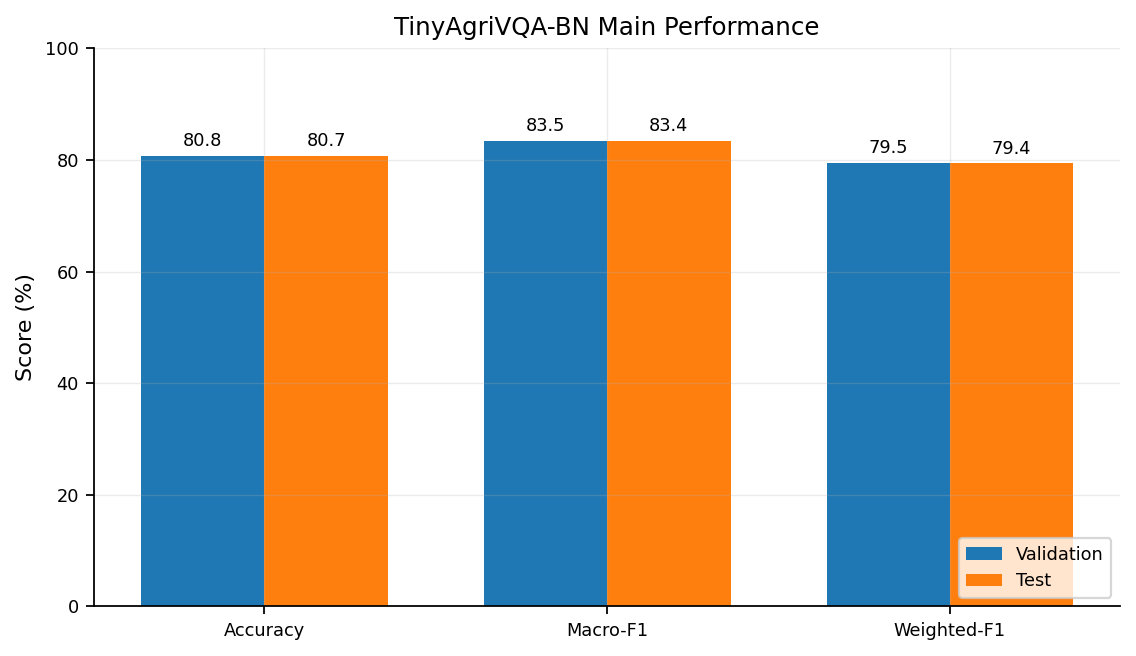

In [22]:
# ============================================================
# Portion 5 / Cell P5-03: Main result figure
# ============================================================

print("=" * 90)
print("MAIN RESULT FIGURE")
print("=" * 90)

plot_df = overall_metrics.copy()
plot_df["Split"] = plot_df["split"].map({
    "validation": "Validation",
    "test": "Test",
}).fillna(plot_df["split"])

metrics_to_plot = [
    ("accuracy", "Accuracy"),
    ("macro_f1", "Macro-F1"),
    ("weighted_f1", "Weighted-F1"),
]

x = np.arange(len(metrics_to_plot))
width = 0.36

fig, ax = plt.subplots(figsize=(7.2, 4.2))

val_vals = [pct(plot_df.loc[plot_df["Split"] == "Validation", m].iloc[0]) for m, _ in metrics_to_plot]
test_vals = [pct(plot_df.loc[plot_df["Split"] == "Test", m].iloc[0]) for m, _ in metrics_to_plot]

ax.bar(x - width / 2, val_vals, width, label="Validation")
ax.bar(x + width / 2, test_vals, width, label="Test")

ax.set_xticks(x)
ax.set_xticklabels([label for _, label in metrics_to_plot])
ax.set_ylabel("Score (%)")
ax.set_title("TinyAgriVQA-BN Main Performance")
ax.set_ylim(0, 100)
ax.legend(loc="lower right")

for i, v in enumerate(val_vals):
    ax.text(i - width / 2, v + 1.0, f"{v:.1f}", ha="center", va="bottom", fontsize=8)

for i, v in enumerate(test_vals):
    ax.text(i + width / 2, v + 1.0, f"{v:.1f}", ha="center", va="bottom", fontsize=8)

save_figure(fig, "fig1_main_result_validation_test")
plt.show()

TRAINING DYNAMICS FIGURE
Saved:
  /kaggle/working/tinyagrivqa_bn_portion5_publication/figures_highres/fig2_training_dynamics_4panel.png
  /kaggle/working/tinyagrivqa_bn_portion5_publication/figures_highres/fig2_training_dynamics_4panel.pdf
  /kaggle/working/tinyagrivqa_bn_portion5_publication/figures_highres/fig2_training_dynamics_4panel.svg


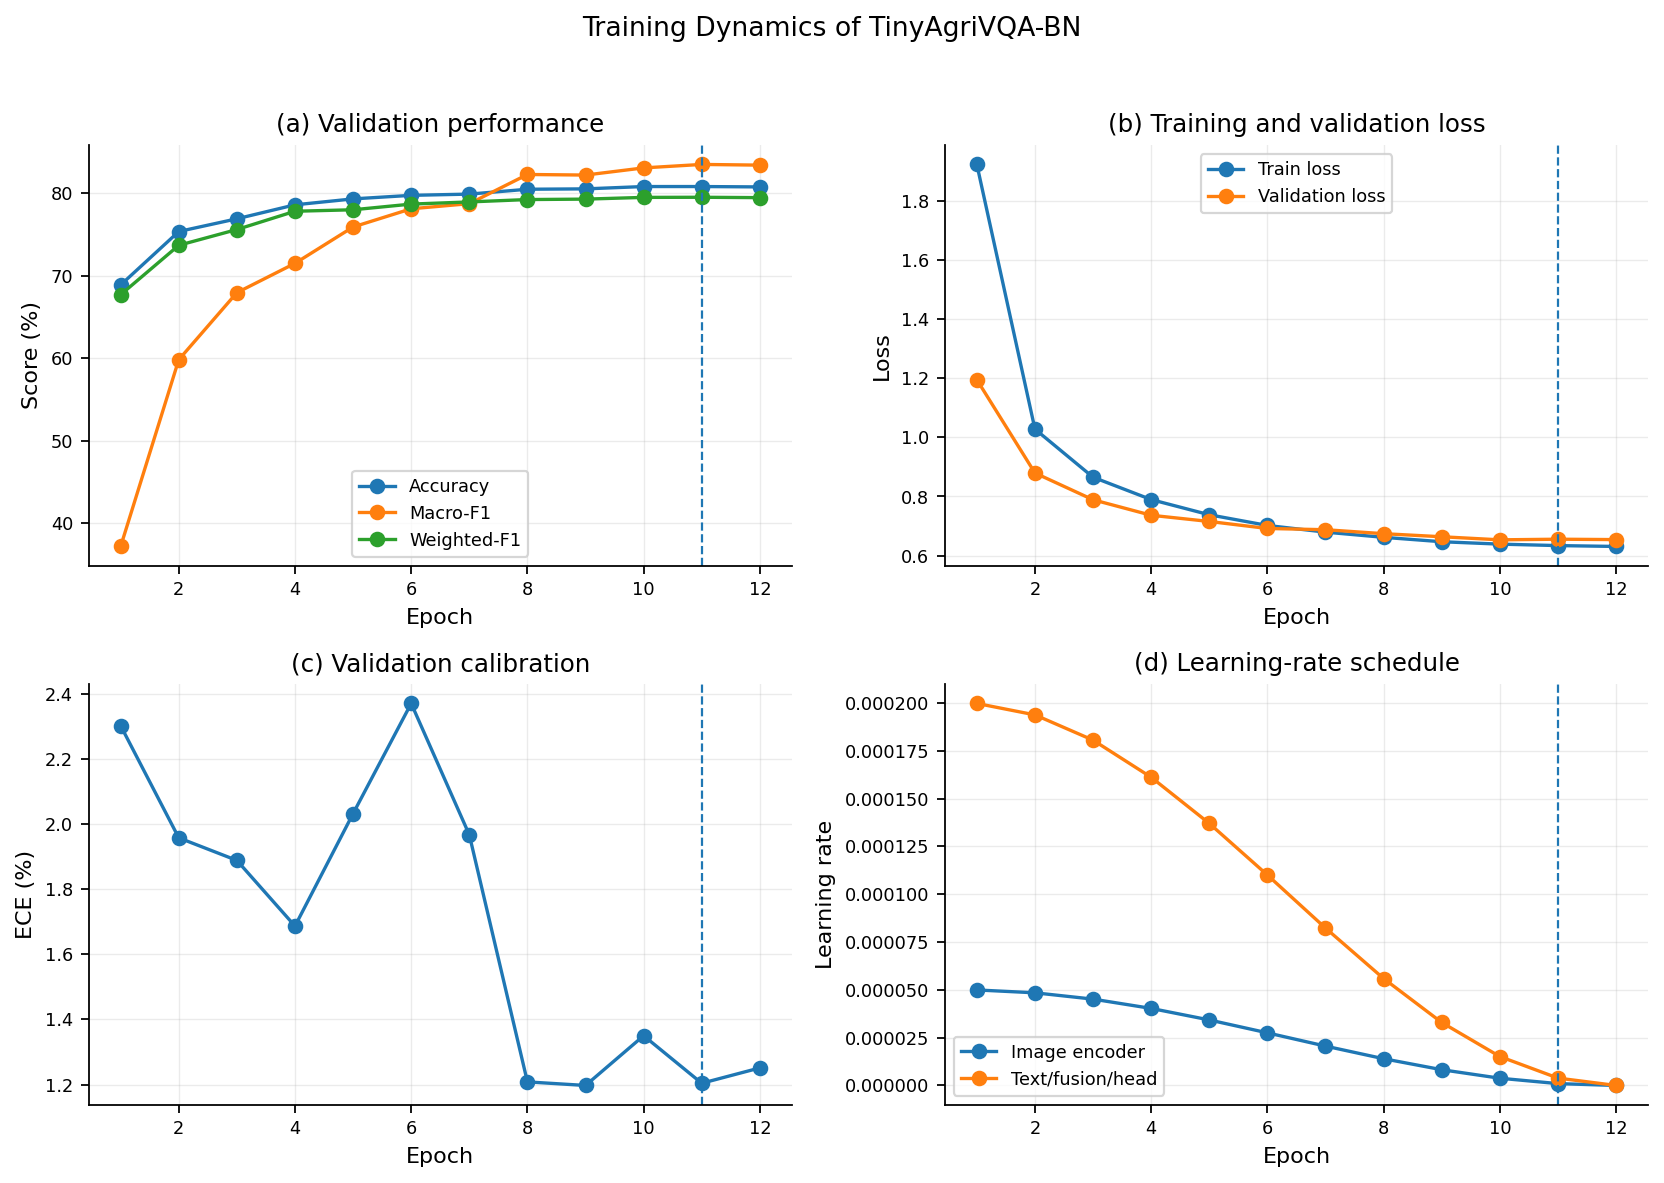

In [23]:
# ============================================================
# Portion 5 / Cell P5-04: Training dynamics figure
# ============================================================

print("=" * 90)
print("TRAINING DYNAMICS FIGURE")
print("=" * 90)

fig, axes = plt.subplots(2, 2, figsize=(10.5, 7.2))

# Panel A: score curves
ax = axes[0, 0]
ax.plot(history_df["epoch"], history_df["val_answer_accuracy"] * 100, marker="o", label="Accuracy")
ax.plot(history_df["epoch"], history_df["val_answer_macro_f1"] * 100, marker="o", label="Macro-F1")
ax.plot(history_df["epoch"], history_df["val_answer_weighted_f1"] * 100, marker="o", label="Weighted-F1")
ax.axvline(BEST_EPOCH, linestyle="--", linewidth=1)
ax.set_title("(a) Validation performance")
ax.set_xlabel("Epoch")
ax.set_ylabel("Score (%)")
ax.legend()

# Panel B: loss curves
ax = axes[0, 1]
ax.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train loss")
ax.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation loss")
ax.axvline(BEST_EPOCH, linestyle="--", linewidth=1)
ax.set_title("(b) Training and validation loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()

# Panel C: ECE
ax = axes[1, 0]
ax.plot(history_df["epoch"], history_df["val_answer_ece"] * 100, marker="o")
ax.axvline(BEST_EPOCH, linestyle="--", linewidth=1)
ax.set_title("(c) Validation calibration")
ax.set_xlabel("Epoch")
ax.set_ylabel("ECE (%)")

# Panel D: learning-rate schedule
ax = axes[1, 1]
ax.plot(history_df["epoch"], history_df["lr_image"], marker="o", label="Image encoder")
ax.plot(history_df["epoch"], history_df["lr_other"], marker="o", label="Text/fusion/head")
ax.axvline(BEST_EPOCH, linestyle="--", linewidth=1)
ax.set_title("(d) Learning-rate schedule")
ax.set_xlabel("Epoch")
ax.set_ylabel("Learning rate")
ax.legend()

fig.suptitle("Training Dynamics of TinyAgriVQA-BN", y=1.02)
save_figure(fig, "fig2_training_dynamics_4panel")
plt.show()

QUESTION-TYPE PERFORMANCE FIGURE
Saved:
  /kaggle/working/tinyagrivqa_bn_portion5_publication/figures_highres/fig3_question_type_macro_f1.png
  /kaggle/working/tinyagrivqa_bn_portion5_publication/figures_highres/fig3_question_type_macro_f1.pdf
  /kaggle/working/tinyagrivqa_bn_portion5_publication/figures_highres/fig3_question_type_macro_f1.svg


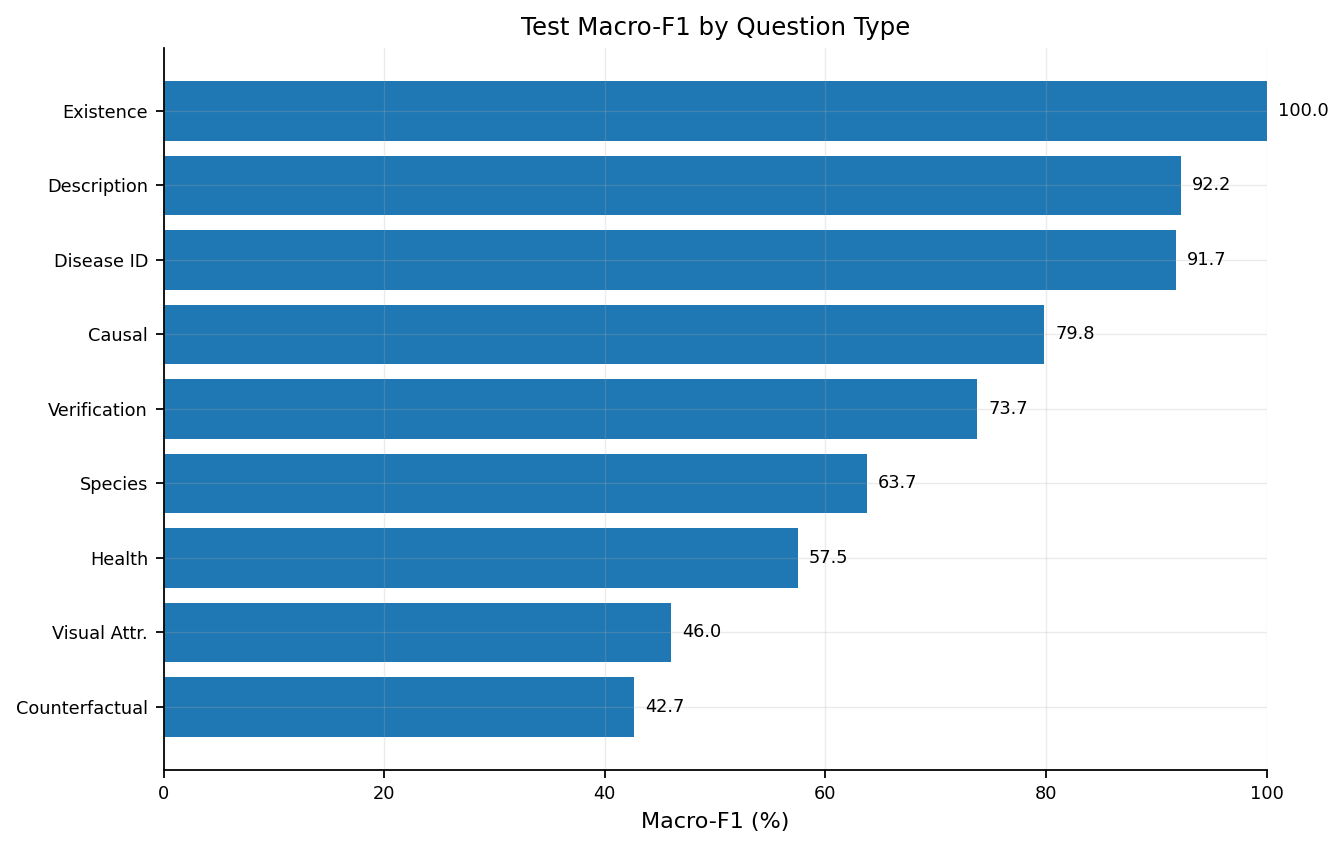

Saved:
  /kaggle/working/tinyagrivqa_bn_portion5_publication/figures_highres/fig3b_question_type_accuracy_macro_f1.png
  /kaggle/working/tinyagrivqa_bn_portion5_publication/figures_highres/fig3b_question_type_accuracy_macro_f1.pdf
  /kaggle/working/tinyagrivqa_bn_portion5_publication/figures_highres/fig3b_question_type_accuracy_macro_f1.svg


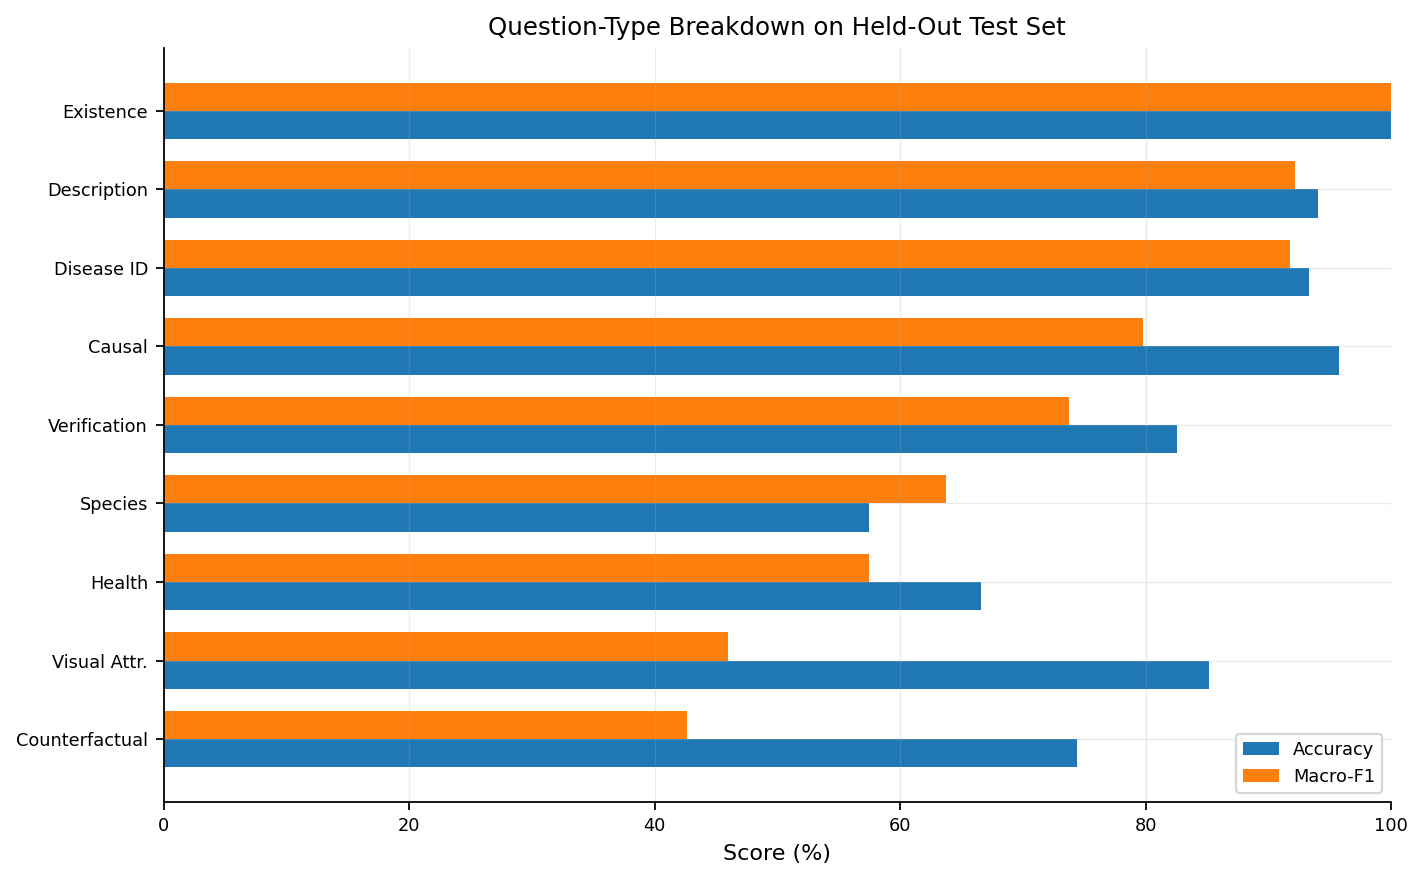

In [24]:
# ============================================================
# Portion 5 / Cell P5-05: Question-type performance figure
# ============================================================

print("=" * 90)
print("QUESTION-TYPE PERFORMANCE FIGURE")
print("=" * 90)

qt = qtype_metrics[qtype_metrics["split"].astype(str).str.contains("test", case=False)].copy()

qt["Question Type"] = qt["question_type"].map(QUESTION_TYPE_SHORT).fillna(qt["question_type"])
qt = qt.sort_values("macro_f1", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8.5, 5.4))

y = np.arange(len(qt))
ax.barh(y, qt["macro_f1"] * 100)
ax.set_yticks(y)
ax.set_yticklabels(qt["Question Type"])
ax.set_xlabel("Macro-F1 (%)")
ax.set_title("Test Macro-F1 by Question Type")
ax.set_xlim(0, 100)

for i, v in enumerate(qt["macro_f1"] * 100):
    ax.text(v + 1.0, i, f"{v:.1f}", va="center", fontsize=8)

save_figure(fig, "fig3_question_type_macro_f1")
plt.show()


# Accuracy + macro-F1 paired figure
fig, ax = plt.subplots(figsize=(9.0, 5.6))

y = np.arange(len(qt))
height = 0.36

ax.barh(y - height / 2, qt["accuracy"] * 100, height, label="Accuracy")
ax.barh(y + height / 2, qt["macro_f1"] * 100, height, label="Macro-F1")

ax.set_yticks(y)
ax.set_yticklabels(qt["Question Type"])
ax.set_xlabel("Score (%)")
ax.set_title("Question-Type Breakdown on Held-Out Test Set")
ax.set_xlim(0, 100)
ax.legend(loc="lower right")

save_figure(fig, "fig3b_question_type_accuracy_macro_f1")
plt.show()

CALIBRATION AND CONFIDENCE FILTERING
Saved:
  /kaggle/working/tinyagrivqa_bn_portion5_publication/figures_highres/fig4_reliability_diagram.png
  /kaggle/working/tinyagrivqa_bn_portion5_publication/figures_highres/fig4_reliability_diagram.pdf
  /kaggle/working/tinyagrivqa_bn_portion5_publication/figures_highres/fig4_reliability_diagram.svg


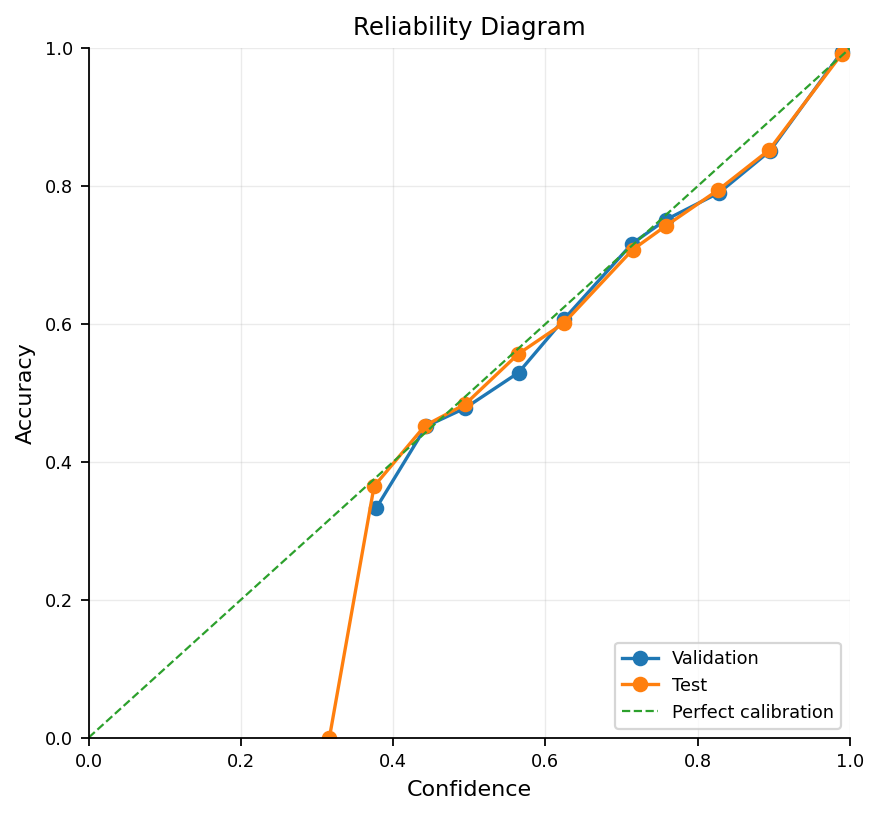

Saved:
  /kaggle/working/tinyagrivqa_bn_portion5_publication/figures_highres/fig5_confidence_distribution.png
  /kaggle/working/tinyagrivqa_bn_portion5_publication/figures_highres/fig5_confidence_distribution.pdf
  /kaggle/working/tinyagrivqa_bn_portion5_publication/figures_highres/fig5_confidence_distribution.svg


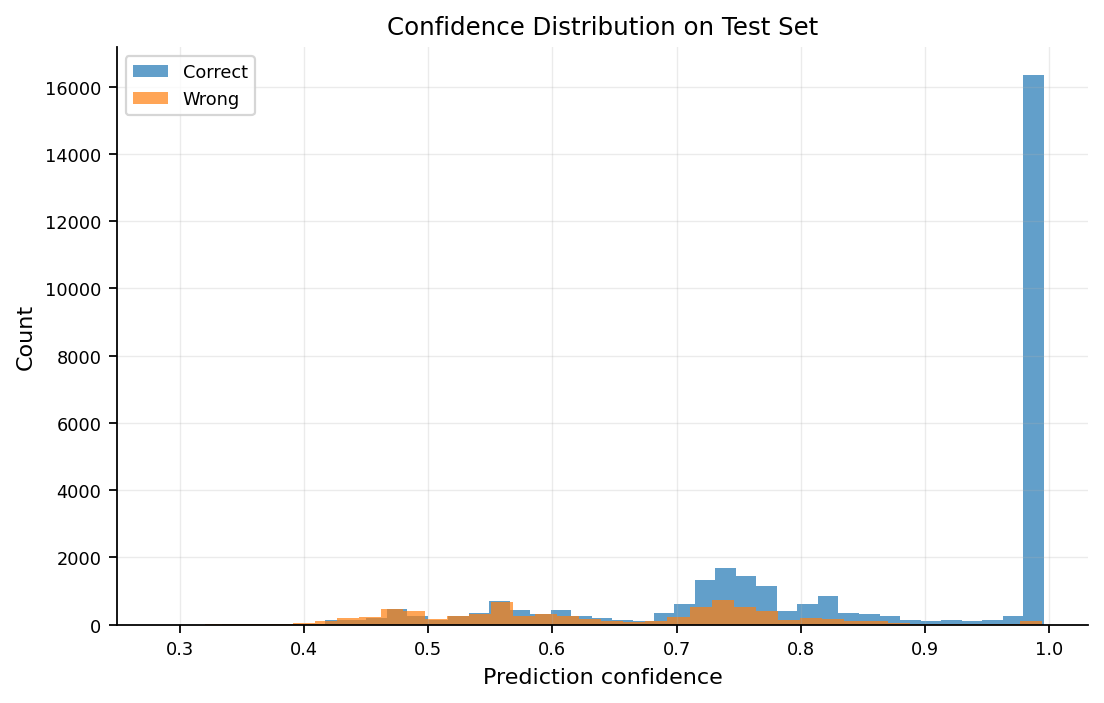

Saved:
  /kaggle/working/tinyagrivqa_bn_portion5_publication/figures_highres/fig6_confidence_threshold_filtering.png
  /kaggle/working/tinyagrivqa_bn_portion5_publication/figures_highres/fig6_confidence_threshold_filtering.pdf
  /kaggle/working/tinyagrivqa_bn_portion5_publication/figures_highres/fig6_confidence_threshold_filtering.svg


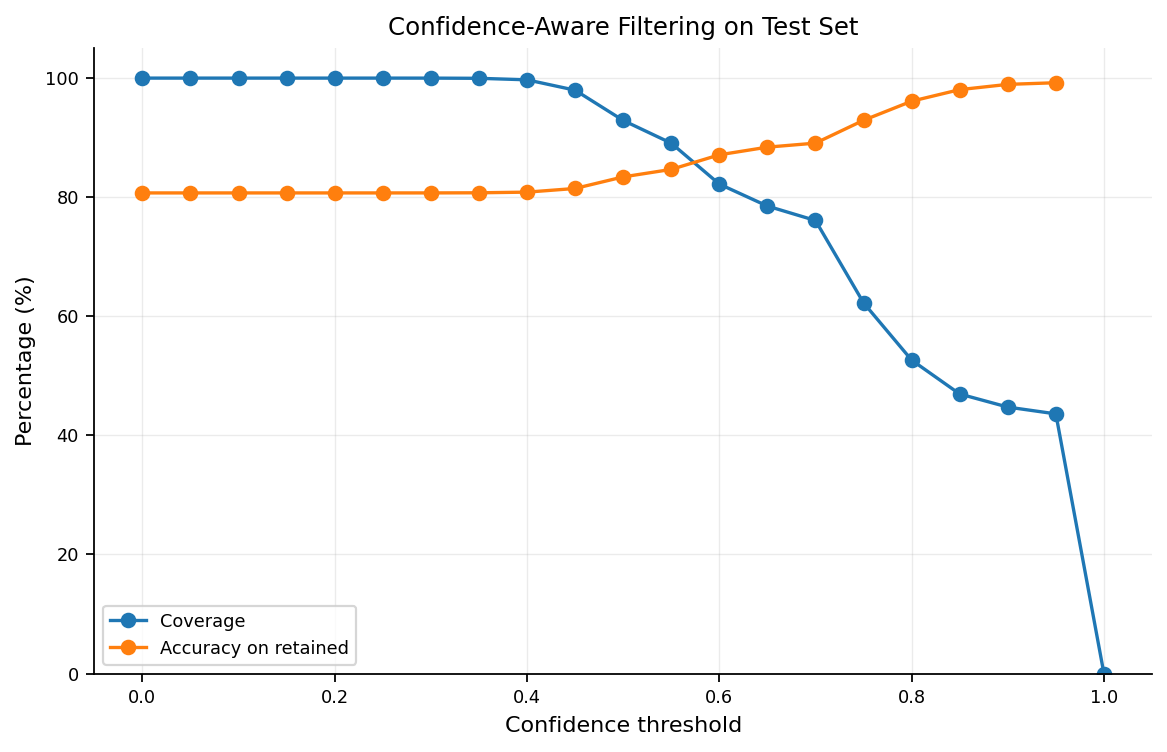

Saved:
  /kaggle/working/tinyagrivqa_bn_portion5_publication/figures_highres/fig7_coverage_risk_tradeoff.png
  /kaggle/working/tinyagrivqa_bn_portion5_publication/figures_highres/fig7_coverage_risk_tradeoff.pdf
  /kaggle/working/tinyagrivqa_bn_portion5_publication/figures_highres/fig7_coverage_risk_tradeoff.svg


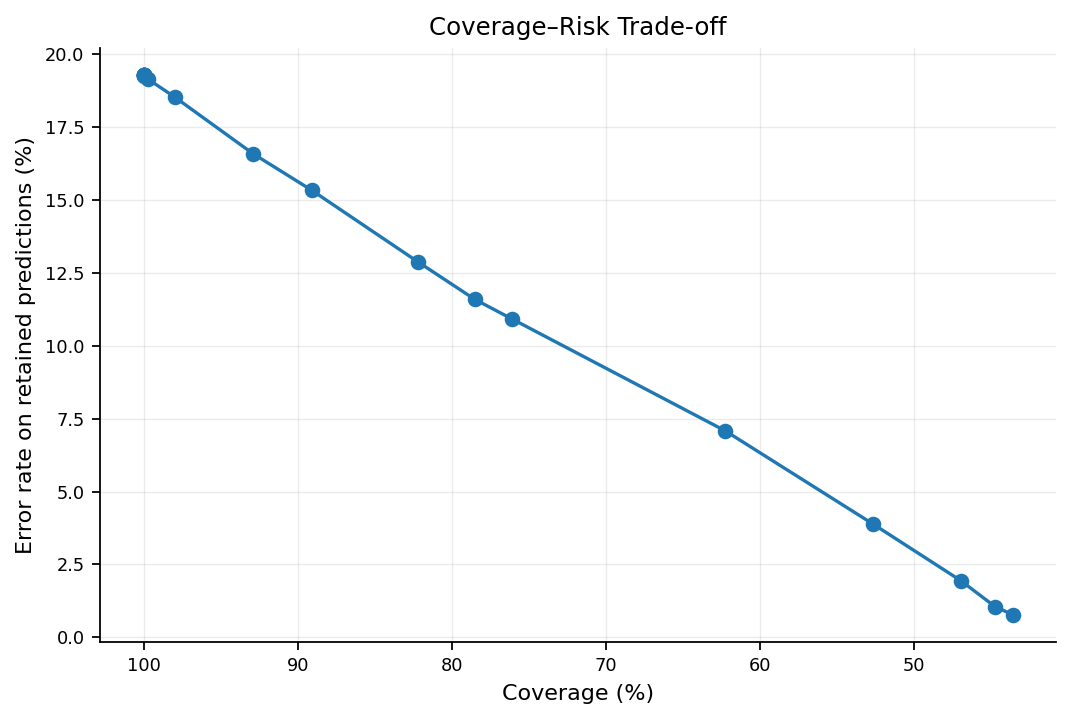

In [25]:
# ============================================================
# Portion 5 / Cell P5-06: Calibration and confidence filtering
# ============================================================

print("=" * 90)
print("CALIBRATION AND CONFIDENCE FILTERING")
print("=" * 90)

# Load reliability bins.
test_bins_path = P4_CALIB_DIR / "test_reliability_bins.csv"
val_bins_path = P4_CALIB_DIR / "validation_reliability_bins.csv"

test_bins = safe_read_csv(test_bins_path)
val_bins = safe_read_csv(val_bins_path)

# Reliability diagram.
fig, ax = plt.subplots(figsize=(5.6, 5.2))

for bins_df, label in [(val_bins, "Validation"), (test_bins, "Test")]:
    b = bins_df[bins_df["count"] > 0].copy()
    ax.plot(b["avg_confidence"], b["accuracy"], marker="o", label=label)

ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Perfect calibration")

ax.set_xlabel("Confidence")
ax.set_ylabel("Accuracy")
ax.set_title("Reliability Diagram")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc="lower right")

save_figure(fig, "fig4_reliability_diagram")
plt.show()


# Confidence distribution: correct vs wrong on test.
fig, ax = plt.subplots(figsize=(7.0, 4.5))

ax.hist(test_pred.loc[test_pred["correct"] == 1, "confidence"], bins=40, alpha=0.70, label="Correct")
ax.hist(test_pred.loc[test_pred["correct"] == 0, "confidence"], bins=40, alpha=0.70, label="Wrong")

ax.set_xlabel("Prediction confidence")
ax.set_ylabel("Count")
ax.set_title("Confidence Distribution on Test Set")
ax.legend()

save_figure(fig, "fig5_confidence_distribution")
plt.show()


# Confidence thresholding.
tt = threshold_table[threshold_table["split"].astype(str).str.contains("test", case=False)].copy()

fig, ax1 = plt.subplots(figsize=(7.4, 4.8))

ax1.plot(tt["threshold"], tt["coverage"] * 100, marker="o", label="Coverage")
ax1.plot(tt["threshold"], tt["accuracy_on_kept"] * 100, marker="o", label="Accuracy on retained")
ax1.set_xlabel("Confidence threshold")
ax1.set_ylabel("Percentage (%)")
ax1.set_title("Confidence-Aware Filtering on Test Set")
ax1.set_ylim(0, 105)
ax1.legend(loc="best")

save_figure(fig, "fig6_confidence_threshold_filtering")
plt.show()


# Coverage-risk tradeoff.
fig, ax = plt.subplots(figsize=(6.8, 4.6))

ax.plot(tt["coverage"] * 100, tt["risk_on_kept"] * 100, marker="o")
ax.set_xlabel("Coverage (%)")
ax.set_ylabel("Error rate on retained predictions (%)")
ax.set_title("Coverage–Risk Trade-off")
ax.invert_xaxis()

save_figure(fig, "fig7_coverage_risk_tradeoff")
plt.show()

MODALITY ABLATION FIGURE
Saved:
  /kaggle/working/tinyagrivqa_bn_portion5_publication/figures_highres/fig8_modality_ablation.png
  /kaggle/working/tinyagrivqa_bn_portion5_publication/figures_highres/fig8_modality_ablation.pdf
  /kaggle/working/tinyagrivqa_bn_portion5_publication/figures_highres/fig8_modality_ablation.svg


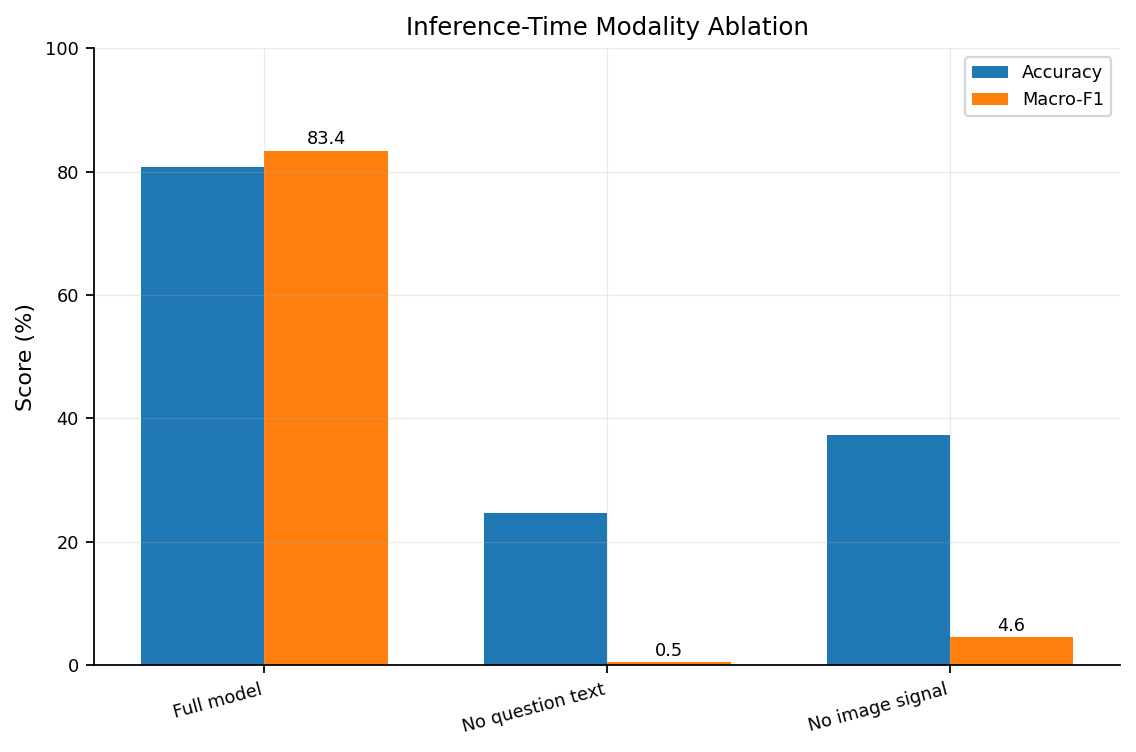

Saved:
  /kaggle/working/tinyagrivqa_bn_portion5_publication/figures_highres/fig8b_modality_ablation_drop.png
  /kaggle/working/tinyagrivqa_bn_portion5_publication/figures_highres/fig8b_modality_ablation_drop.pdf
  /kaggle/working/tinyagrivqa_bn_portion5_publication/figures_highres/fig8b_modality_ablation_drop.svg


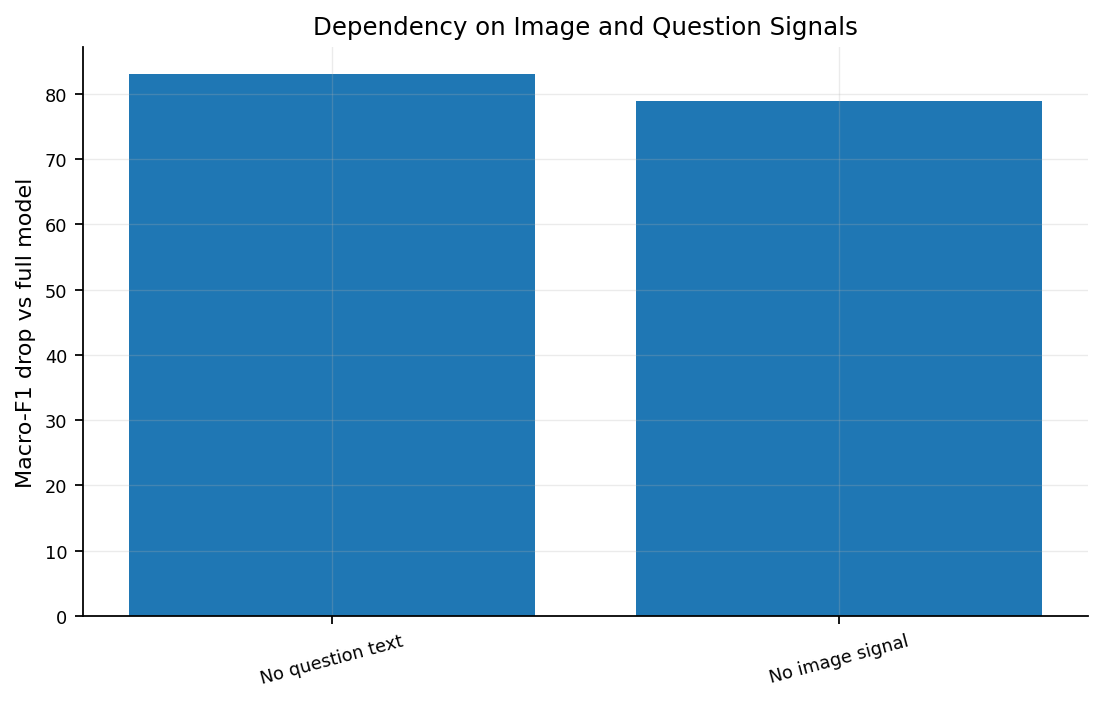

In [26]:
# ============================================================
# Portion 5 / Cell P5-07: Modality ablation figure
# ============================================================

print("=" * 90)
print("MODALITY ABLATION FIGURE")
print("=" * 90)

abl = ablation_metrics.copy()
abl["Mode"] = abl["mode"].map(MODE_LABELS).fillna(abl["mode"])

fig, ax = plt.subplots(figsize=(7.2, 4.8))

x = np.arange(len(abl))
width = 0.36

ax.bar(x - width / 2, abl["accuracy"] * 100, width, label="Accuracy")
ax.bar(x + width / 2, abl["macro_f1"] * 100, width, label="Macro-F1")

ax.set_xticks(x)
ax.set_xticklabels(abl["Mode"], rotation=15, ha="right")
ax.set_ylabel("Score (%)")
ax.set_title("Inference-Time Modality Ablation")
ax.set_ylim(0, 100)
ax.legend(loc="best")

for i, v in enumerate(abl["macro_f1"] * 100):
    ax.text(i + width / 2, v + 1.0, f"{v:.1f}", ha="center", fontsize=8)

save_figure(fig, "fig8_modality_ablation")
plt.show()


# Drop relative to full.
fig, ax = plt.subplots(figsize=(7.0, 4.5))

abl_drop = abl[abl["mode"] != "full"].copy()
ax.bar(abl_drop["Mode"], abl_drop["macro_f1_drop_vs_full"] * 100)
ax.set_ylabel("Macro-F1 drop vs full model")
ax.set_title("Dependency on Image and Question Signals")
ax.tick_params(axis="x", rotation=15)

save_figure(fig, "fig8b_modality_ablation_drop")
plt.show()

ERROR ANALYSIS FIGURES
Saved:
  /kaggle/working/tinyagrivqa_bn_portion5_publication/figures_highres/fig9_top_answer_confusions.png
  /kaggle/working/tinyagrivqa_bn_portion5_publication/figures_highres/fig9_top_answer_confusions.pdf
  /kaggle/working/tinyagrivqa_bn_portion5_publication/figures_highres/fig9_top_answer_confusions.svg


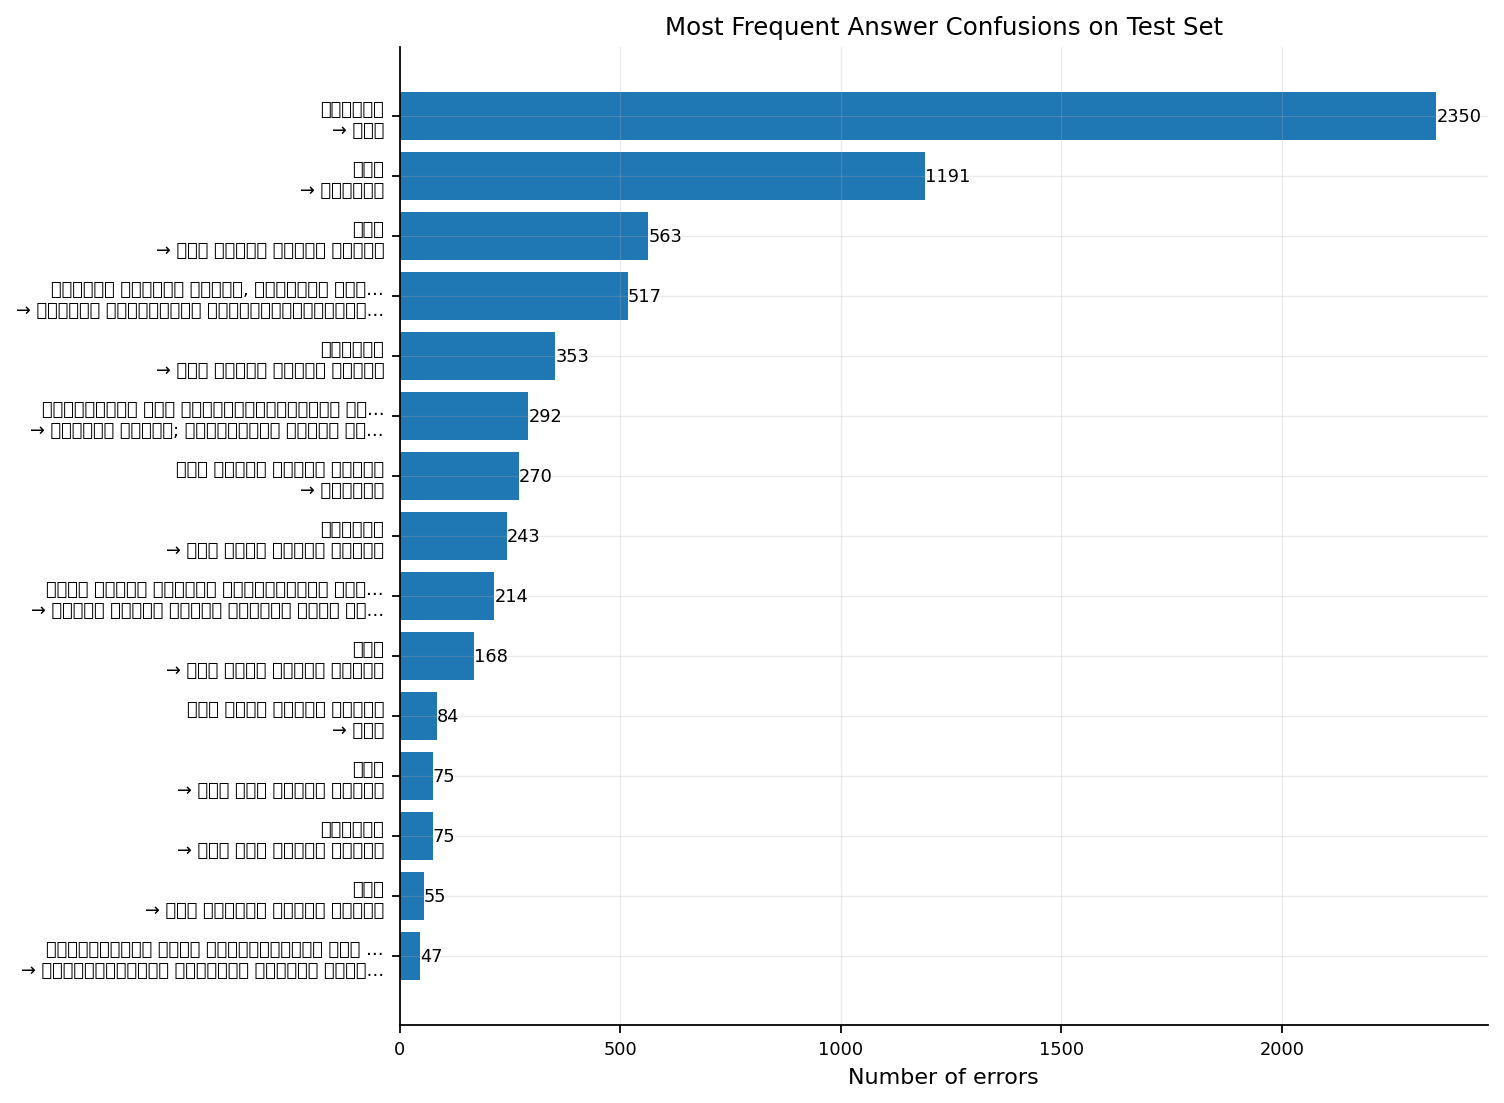

Saved:
  /kaggle/working/tinyagrivqa_bn_portion5_publication/figures_highres/fig10_high_conf_wrong_by_question_type.png
  /kaggle/working/tinyagrivqa_bn_portion5_publication/figures_highres/fig10_high_conf_wrong_by_question_type.pdf
  /kaggle/working/tinyagrivqa_bn_portion5_publication/figures_highres/fig10_high_conf_wrong_by_question_type.svg


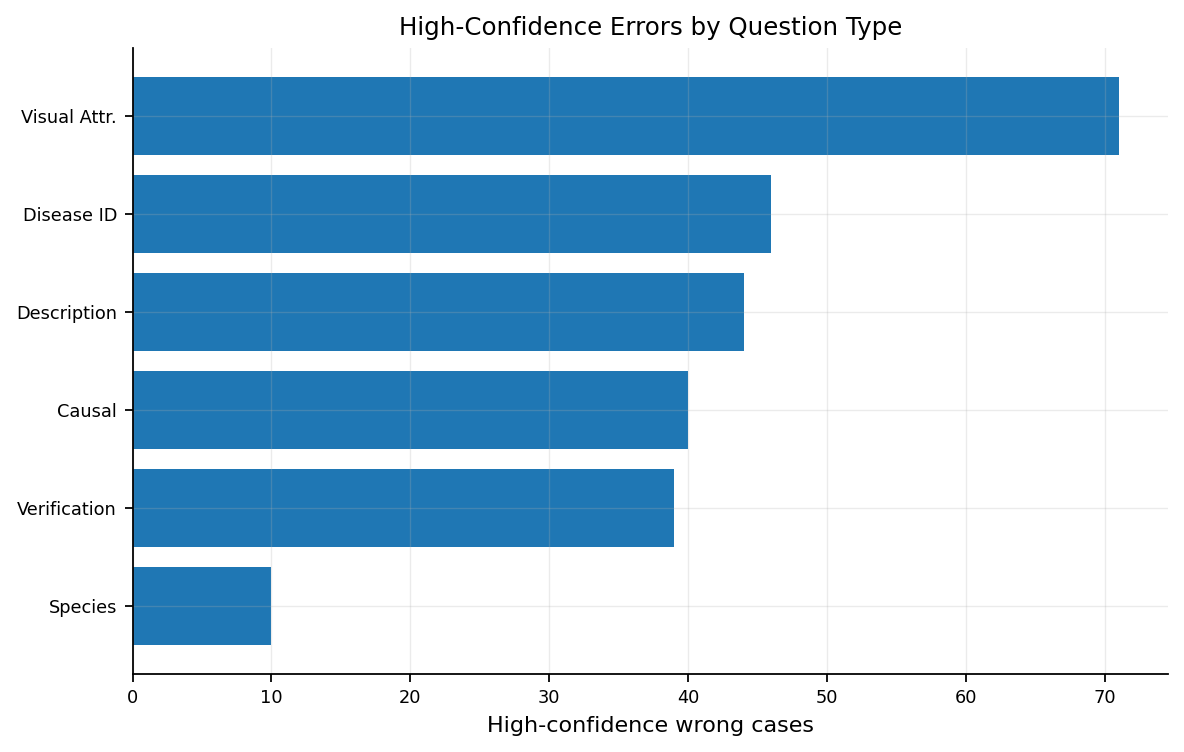

Saved:
  /kaggle/working/tinyagrivqa_bn_portion5_publication/figures_highres/fig11_hardest_disease_labels.png
  /kaggle/working/tinyagrivqa_bn_portion5_publication/figures_highres/fig11_hardest_disease_labels.pdf
  /kaggle/working/tinyagrivqa_bn_portion5_publication/figures_highres/fig11_hardest_disease_labels.svg


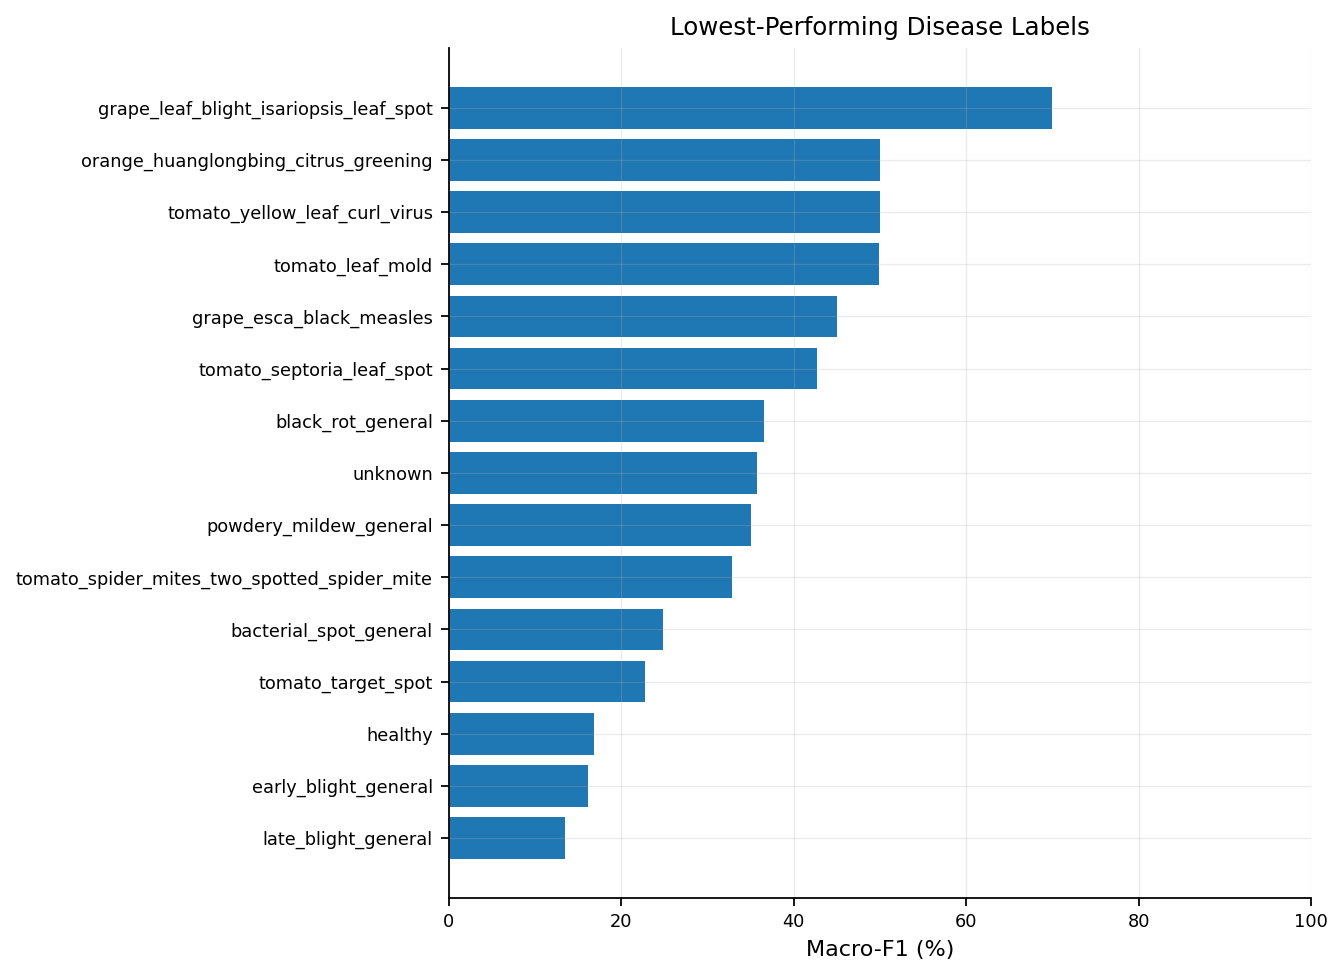

In [27]:
# ============================================================
# Portion 5 / Cell P5-08: Error analysis visual panels
# ============================================================

print("=" * 90)
print("ERROR ANALYSIS FIGURES")
print("=" * 90)

# Top confusion pairs.
cp = confusion_pairs[confusion_pairs["split"].astype(str).str.contains("test", case=False)].copy()
cp = cp.sort_values("count", ascending=False).head(15).reset_index(drop=True)

def shorten_text(x, n=42):
    x = str(x)
    x = x.replace("\n", " ")
    return x[:n] + ("…" if len(x) > n else "")

cp["Pair"] = [
    shorten_text(g, 32) + "\n→ " + shorten_text(p, 32)
    for g, p in zip(cp["gold_answer_text"], cp["pred_answer_text"])
]

fig, ax = plt.subplots(figsize=(9.5, 7.0))

y = np.arange(len(cp))
ax.barh(y, cp["count"])
ax.set_yticks(y)
ax.set_yticklabels(cp["Pair"])
ax.invert_yaxis()
ax.set_xlabel("Number of errors")
ax.set_title("Most Frequent Answer Confusions on Test Set")

for i, v in enumerate(cp["count"]):
    ax.text(v + 0.5, i, str(int(v)), va="center", fontsize=8)

save_figure(fig, "fig9_top_answer_confusions")
plt.show()


# High-confidence wrong: by question type.
hcw = test_high_conf_wrong.copy()
hcw_q = (
    hcw.groupby("question_type")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=True)
)
hcw_q["Question Type"] = hcw_q["question_type"].map(QUESTION_TYPE_SHORT).fillna(hcw_q["question_type"])

fig, ax = plt.subplots(figsize=(7.5, 4.8))

ax.barh(hcw_q["Question Type"], hcw_q["count"])
ax.set_xlabel("High-confidence wrong cases")
ax.set_title("High-Confidence Errors by Question Type")

save_figure(fig, "fig10_high_conf_wrong_by_question_type")
plt.show()


# Hardest disease labels if available.
if hardest_disease is not None and len(hardest_disease) > 0:
    hd = hardest_disease.head(15).copy()
    hd = hd.sort_values("macro_f1", ascending=True)

    fig, ax = plt.subplots(figsize=(8.5, 6.2))
    ax.barh(hd["p2_disease_label"].astype(str), hd["macro_f1"] * 100)
    ax.set_xlabel("Macro-F1 (%)")
    ax.set_title("Lowest-Performing Disease Labels")
    ax.set_xlim(0, 100)

    save_figure(fig, "fig11_hardest_disease_labels")
    plt.show()

GRAD-CAM MONTAGE
Available Grad-CAM panels: 20


,idx,qa_id,image_id,group,correct,gold_answer_text,pred_answer_text,confidence,question_type,p2_crop_label,p2_disease_label,p2_class_label,gradcam_path,exists
0,0,f92ee4d5846d3849,image_044662.JPG,correct_disease_high_conf,1,সম্ভাব্য নির্দিষ্ট রোগ হলো ব্ল্যাক রট।,সম্ভাব্য নির্দিষ্ট রোগ হলো ব্ল্যাক রট।,0.996026,Specific Disease Identification,unknown,black_rot_general,black_rot_general,/kaggle/working/tinyagrivqa_bn_portion4/gradca...,True
1,1,c83c5b3cf8689844,image_046769.JPG,correct_disease_high_conf,1,সম্ভাব্য নির্দিষ্ট রোগ হলো ব্ল্যাক রট।,সম্ভাব্য নির্দিষ্ট রোগ হলো ব্ল্যাক রট।,0.995966,Specific Disease Identification,unknown,black_rot_general,black_rot_general,/kaggle/working/tinyagrivqa_bn_portion4/gradca...,True
2,2,87564df13bfced6e,image_053991.JPG,correct_disease_high_conf,1,সম্ভাব্য নির্দিষ্ট রোগ হলো ব্ল্যাক রট।,সম্ভাব্য নির্দিষ্ট রোগ হলো ব্ল্যাক রট।,0.995924,Specific Disease Identification,unknown,black_rot_general,black_rot_general,/kaggle/working/tinyagrivqa_bn_portion4/gradca...,True
3,3,7a01774eb838ca31,image_048446.JPG,correct_disease_high_conf,1,সম্ভাব্য নির্দিষ্ট রোগ হলো ব্ল্যাক রট।,সম্ভাব্য নির্দিষ্ট রোগ হলো ব্ল্যাক রট।,0.995730,Specific Disease Identification,unknown,black_rot_general,black_rot_general,/kaggle/working/tinyagrivqa_bn_portion4/gradca...,True
4,4,5e3ca0650b254a55,image_047410.JPG,correct_disease_high_conf,1,সম্ভাব্য নির্দিষ্ট রোগ হলো ব্ল্যাক রট।,সম্ভাব্য নির্দিষ্ট রোগ হলো ব্ল্যাক রট।,0.995690,Specific Disease Identification,unknown,black_rot_general,black_rot_general,/kaggle/working/tinyagrivqa_bn_portion4/gradca...,True


Saved:
  /kaggle/working/tinyagrivqa_bn_portion5_publication/figures_highres/fig12_gradcam_montage.png
  /kaggle/working/tinyagrivqa_bn_portion5_publication/figures_highres/fig12_gradcam_montage.pdf
  /kaggle/working/tinyagrivqa_bn_portion5_publication/figures_highres/fig12_gradcam_montage.svg


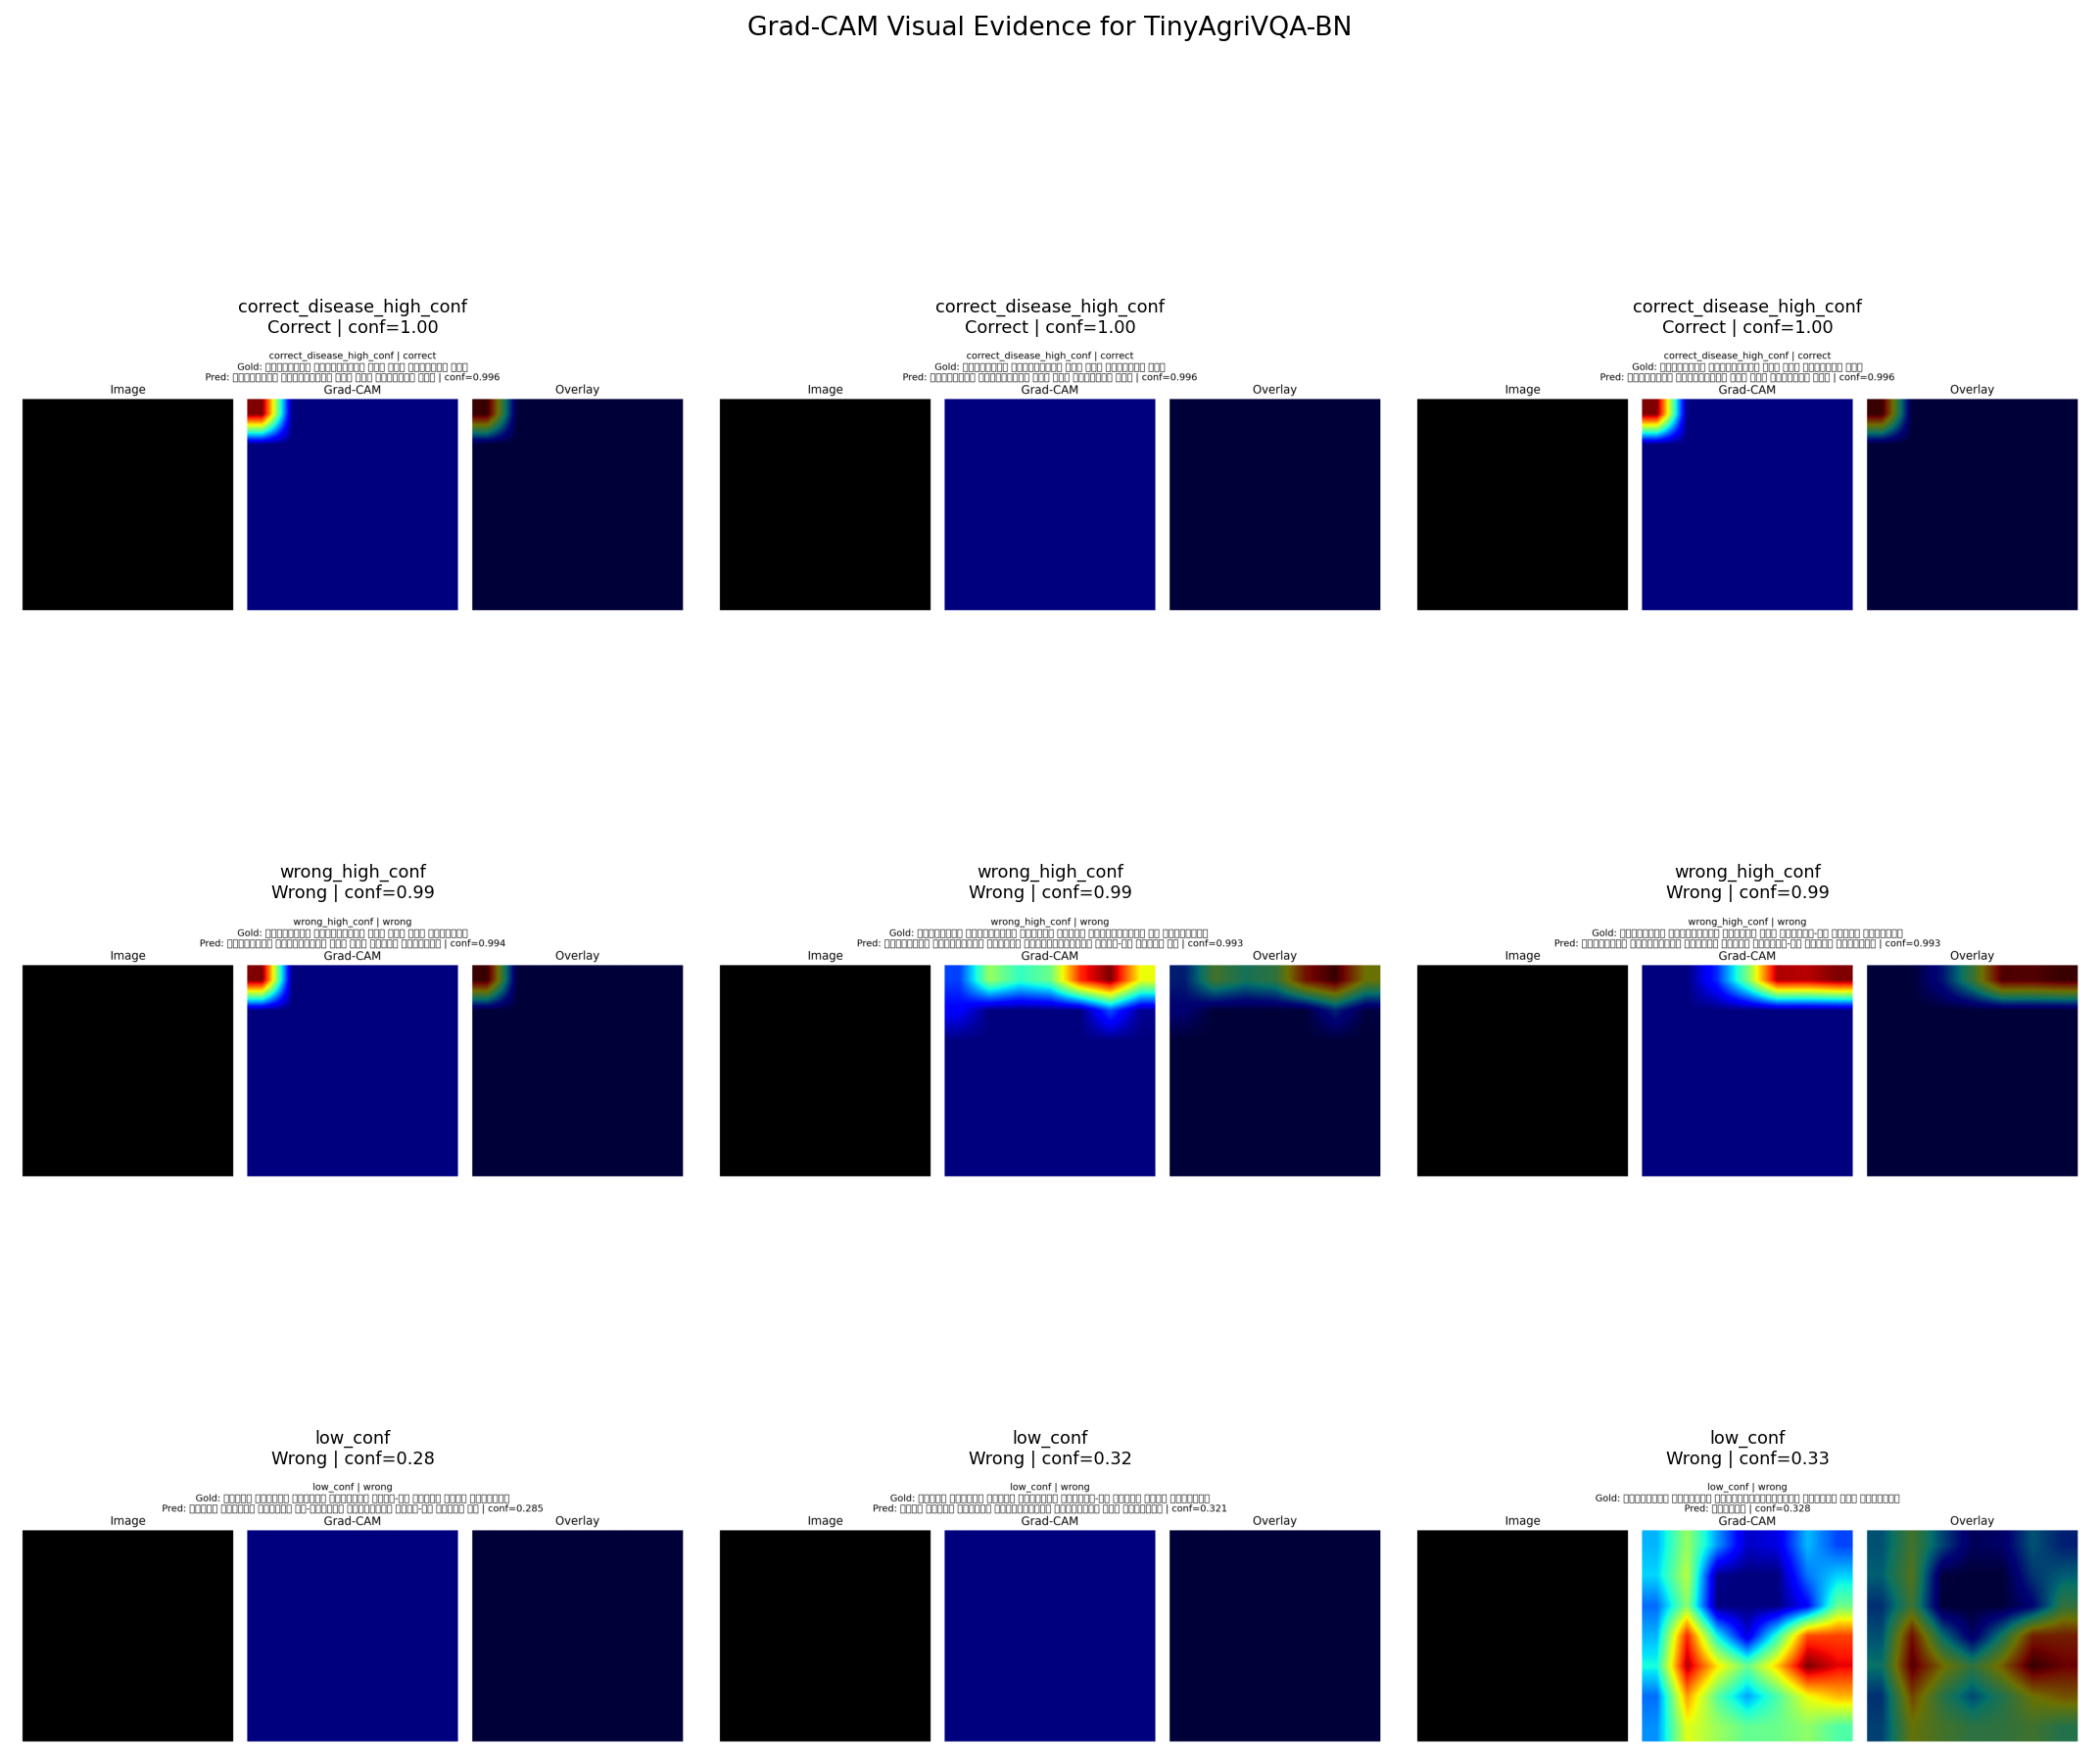

Saved: /kaggle/working/tinyagrivqa_bn_portion5_publication/appendix/gradcam_montage_manifest.csv


In [28]:
# ============================================================
# Portion 5 / Cell P5-09: Grad-CAM high-resolution montage
# ============================================================

print("=" * 90)
print("GRAD-CAM MONTAGE")
print("=" * 90)

gradcam_manifest_path = P4_GRADCAM_DIR / "gradcam_manifest.csv"

if not gradcam_manifest_path.exists():
    print("Grad-CAM manifest not found. Skipping montage.")
else:
    gradcam_manifest = pd.read_csv(gradcam_manifest_path)
    gradcam_manifest = gradcam_manifest[gradcam_manifest["gradcam_path"].notna()].copy()

    # Keep existing image files only.
    gradcam_manifest["exists"] = gradcam_manifest["gradcam_path"].map(lambda p: Path(str(p)).exists())
    gradcam_manifest = gradcam_manifest[gradcam_manifest["exists"]].reset_index(drop=True)

    print("Available Grad-CAM panels:", len(gradcam_manifest))
    display(gradcam_manifest.head())

    # Select up to 9 examples: correct, wrong, low confidence.
    selected_parts = []

    for group_name in ["correct_disease_high_conf", "wrong_high_conf", "low_conf"]:
        g = gradcam_manifest[gradcam_manifest["group"] == group_name].head(3)
        selected_parts.append(g)

    montage_df = pd.concat(selected_parts, axis=0).reset_index(drop=True)

    if len(montage_df) == 0:
        print("No valid Grad-CAM images for montage.")
    else:
        n = len(montage_df)
        cols = 3
        rows = math.ceil(n / cols)

        fig, axes = plt.subplots(rows, cols, figsize=(13.5, 4.2 * rows))

        if rows == 1:
            axes = np.array([axes])

        axes = axes.flatten()

        for ax in axes:
            ax.axis("off")

        for i, row in montage_df.iterrows():
            ax = axes[i]
            img = Image.open(row["gradcam_path"]).convert("RGB")
            ax.imshow(img)
            ax.axis("off")

            title = (
                f"{row['group']}\n"
                f"{'Correct' if int(row.get('correct', 0)) == 1 else 'Wrong'} | "
                f"conf={float(row.get('confidence', 0.0)):.2f}"
            )
            ax.set_title(title, fontsize=8)

        fig.suptitle("Grad-CAM Visual Evidence for TinyAgriVQA-BN", y=1.01)

        paths = save_figure(fig, "fig12_gradcam_montage", directory=P5_FIG_DIR)
        plt.show()

        montage_df.to_csv(P5_APPENDIX_DIR / "gradcam_montage_manifest.csv", index=False)
        print("Saved:", P5_APPENDIX_DIR / "gradcam_montage_manifest.csv")

In [29]:
# ============================================================
# Portion 5 / Cell P5-10: ACL-style LaTeX tables
# ============================================================

print("=" * 90)
print("ACL-STYLE LATEX TABLES")
print("=" * 90)

def latex_escape(s):
    s = str(s)
    replacements = {
        "&": r"\&",
        "%": r"\%",
        "$": r"\$",
        "#": r"\#",
        "_": r"\_",
        "{": r"\{",
        "}": r"\}",
        "~": r"\textasciitilde{}",
        "^": r"\textasciicircum{}",
        "\\": r"\textbackslash{}",
    }
    for k, v in replacements.items():
        s = s.replace(k, v)
    return s


# ------------------------------------------------------------
# Main result table
# ------------------------------------------------------------
main_table = pd.DataFrame([
    {
        "Split": "Validation",
        "Rows": int(FINAL_METRICS["val_rows"]),
        "Accuracy": f"{pct(FINAL_METRICS['validation_accuracy']):.2f}",
        "Macro-F1": f"{pct(FINAL_METRICS['validation_macro_f1']):.2f}",
        "Weighted-F1": f"{pct(FINAL_METRICS['validation_weighted_f1']):.2f}",
        "ECE": f"{pct(FINAL_METRICS['validation_ece']):.2f}",
    },
    {
        "Split": "Test",
        "Rows": int(FINAL_METRICS["test_rows"]),
        "Accuracy": f"{pct(FINAL_METRICS['test_accuracy']):.2f}",
        "Macro-F1": f"{pct(FINAL_METRICS['test_macro_f1']):.2f}",
        "Weighted-F1": f"{pct(FINAL_METRICS['test_weighted_f1']):.2f}",
        "ECE": f"{pct(FINAL_METRICS['test_ece']):.2f}",
    },
])

main_latex = main_table.to_latex(
    index=False,
    escape=False,
    caption="Main TinyAgriVQA-BN results. Accuracy, F1, and ECE are reported as percentages.",
    label="tab:main_results",
)

main_table.to_csv(P5_TABLE_DIR / "table_main_results.csv", index=False)
with open(P5_TABLE_DIR / "table_main_results.tex", "w", encoding="utf-8") as f:
    f.write(main_latex)

print(main_latex)


# ------------------------------------------------------------
# Question-type table
# ------------------------------------------------------------
qt_table = qtype_metrics[qtype_metrics["split"].astype(str).str.contains("test", case=False)].copy()
qt_table["Question Type"] = qt_table["question_type"].map(QUESTION_TYPE_SHORT).fillna(qt_table["question_type"])
qt_table = qt_table.sort_values("macro_f1", ascending=False)

qt_table_out = pd.DataFrame({
    "Question Type": qt_table["Question Type"].map(latex_escape),
    "Rows": qt_table["rows"].astype(int),
    "Accuracy": (qt_table["accuracy"] * 100).map(lambda x: f"{x:.2f}"),
    "Macro-F1": (qt_table["macro_f1"] * 100).map(lambda x: f"{x:.2f}"),
    "Weighted-F1": (qt_table["weighted_f1"] * 100).map(lambda x: f"{x:.2f}"),
})

qt_latex = qt_table_out.to_latex(
    index=False,
    escape=False,
    caption="Test performance by question type.",
    label="tab:qtype_results",
)

qt_table_out.to_csv(P5_TABLE_DIR / "table_question_type_results.csv", index=False)
with open(P5_TABLE_DIR / "table_question_type_results.tex", "w", encoding="utf-8") as f:
    f.write(qt_latex)

print(qt_latex[:2000])


# ------------------------------------------------------------
# Ablation table
# ------------------------------------------------------------
abl_table = ablation_metrics.copy()
abl_table["Mode"] = abl_table["mode"].map(MODE_LABELS).fillna(abl_table["mode"])

abl_out = pd.DataFrame({
    "Inference Mode": abl_table["Mode"].map(latex_escape),
    "Accuracy": (abl_table["accuracy"] * 100).map(lambda x: f"{x:.2f}"),
    "Macro-F1": (abl_table["macro_f1"] * 100).map(lambda x: f"{x:.2f}"),
    "Macro-F1 Drop": (abl_table["macro_f1_drop_vs_full"] * 100).map(lambda x: f"{x:.2f}"),
    "ECE": (abl_table["ece"] * 100).map(lambda x: f"{x:.2f}"),
})

abl_latex = abl_out.to_latex(
    index=False,
    escape=False,
    caption="Inference-time modality ablation on the held-out test split.",
    label="tab:modality_ablation",
)

abl_out.to_csv(P5_TABLE_DIR / "table_modality_ablation.csv", index=False)
with open(P5_TABLE_DIR / "table_modality_ablation.tex", "w", encoding="utf-8") as f:
    f.write(abl_latex)

print(abl_latex)


# ------------------------------------------------------------
# Confidence threshold table: compact version
# ------------------------------------------------------------
threshold_compact = threshold_table[
    threshold_table["split"].astype(str).str.contains("test", case=False)
].copy()

keep_thresholds = [0.00, 0.50, 0.60, 0.70, 0.80, 0.90]
threshold_compact = threshold_compact[
    threshold_compact["threshold"].round(2).isin(keep_thresholds)
].copy()

thr_out = pd.DataFrame({
    "Threshold": threshold_compact["threshold"].map(lambda x: f"{x:.2f}"),
    "Coverage": (threshold_compact["coverage"] * 100).map(lambda x: f"{x:.2f}"),
    "Accuracy": (threshold_compact["accuracy_on_kept"] * 100).map(lambda x: f"{x:.2f}"),
    "Macro-F1": (threshold_compact["macro_f1_on_kept"] * 100).map(lambda x: f"{x:.2f}"),
    "Risk": (threshold_compact["risk_on_kept"] * 100).map(lambda x: f"{x:.2f}"),
})

thr_latex = thr_out.to_latex(
    index=False,
    escape=False,
    caption="Confidence-threshold filtering on the held-out test split.",
    label="tab:confidence_filtering",
)

thr_out.to_csv(P5_TABLE_DIR / "table_confidence_filtering.csv", index=False)
with open(P5_TABLE_DIR / "table_confidence_filtering.tex", "w", encoding="utf-8") as f:
    f.write(thr_latex)

print(thr_latex)

print("All LaTeX tables saved to:", P5_TABLE_DIR)

ACL-STYLE LATEX TABLES
\begin{table}
\caption{Main TinyAgriVQA-BN results. Accuracy, F1, and ECE are reported as percentages.}
\label{tab:main_results}
\begin{tabular}{lrllll}
\toprule
Split & Rows & Accuracy & Macro-F1 & Weighted-F1 & ECE \\
\midrule
Validation & 15596 & 80.78 & 83.45 & 79.48 & 1.20 \\
Test & 38632 & 80.72 & 83.41 & 79.42 & 0.98 \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}
\caption{Test performance by question type.}
\label{tab:qtype_results}
\begin{tabular}{lrlll}
\toprule
Question Type & Rows & Accuracy & Macro-F1 & Weighted-F1 \\
\midrule
Existence & 617 & 100.00 & 100.00 & 100.00 \\
Description & 5573 & 94.08 & 92.19 & 92.72 \\
Disease ID & 5979 & 93.34 & 91.74 & 91.40 \\
Causal & 5230 & 95.79 & 79.83 & 95.60 \\
Verification & 2848 & 82.55 & 73.75 & 80.15 \\
Species & 6794 & 57.51 & 63.74 & 52.95 \\
Health & 6365 & 66.61 & 57.48 & 62.05 \\
Visual Attr. & 3205 & 85.18 & 46.00 & 78.36 \\
Counterfactual & 2021 & 74.42 & 42.67 & 63.50 \\
\bottomrule
\end{ta

In [30]:
# ============================================================
# Portion 5 / Cell P5-11: Figure captions and paper text snippets
# ============================================================

print("=" * 90)
print("FIGURE CAPTIONS AND PAPER TEXT")
print("=" * 90)

captions = {
    "fig1_main_result_validation_test": (
        "Main validation and held-out test performance of TinyAgriVQA-BN. "
        "The model achieves strong test macro-F1 while maintaining a small validation--test gap."
    ),
    "fig2_training_dynamics_4panel": (
        "Training dynamics for TinyAgriVQA-BN. The best checkpoint is selected at epoch "
        f"{BEST_EPOCH} by validation macro-F1. Later epochs do not improve the selected metric."
    ),
    "fig3_question_type_macro_f1": (
        "Question-type breakdown on the held-out test set. Performance varies across reasoning, "
        "verification, species identification, and disease identification question types."
    ),
    "fig4_reliability_diagram": (
        "Reliability diagram for validation and test predictions. The low expected calibration error "
        "indicates that confidence estimates are well aligned with empirical correctness."
    ),
    "fig6_confidence_threshold_filtering": (
        "Confidence-aware filtering on the test set. Increasing the confidence threshold improves "
        "the accuracy of retained predictions while reducing coverage."
    ),
    "fig8_modality_ablation": (
        "Inference-time modality ablation. Removing either the question text or the image signal "
        "reduces performance, confirming that the model uses multimodal evidence."
    ),
    "fig9_top_answer_confusions": (
        "Most frequent answer-level confusions on the test set. These errors guide future dataset "
        "cleaning and targeted model improvements."
    ),
    "fig12_gradcam_montage": (
        "Grad-CAM visual evidence for representative correct, incorrect, and low-confidence predictions. "
        "The overlays indicate image regions that most influenced the answer prediction."
    ),
}

caption_path = P5_REPORT_DIR / "figure_captions.json"
with open(caption_path, "w", encoding="utf-8") as f:
    json.dump(captions, f, ensure_ascii=False, indent=2)

caption_md = []
for k, v in captions.items():
    caption_md.append(f"### {k}\n{v}\n")

with open(P5_REPORT_DIR / "figure_captions.md", "w", encoding="utf-8") as f:
    f.write("\n".join(caption_md))

print("Saved captions:")
print(" ", caption_path)
print(" ", P5_REPORT_DIR / "figure_captions.md")


# ------------------------------------------------------------
# Paper-ready result paragraph
# ------------------------------------------------------------
result_paragraph = f"""
TinyAgriVQA-BN obtains {pct(FINAL_METRICS['test_accuracy']):.2f}\\% test accuracy,
{pct(FINAL_METRICS['test_macro_f1']):.2f}\\% test macro-F1,
{pct(FINAL_METRICS['test_weighted_f1']):.2f}\\% weighted-F1, and
{pct(FINAL_METRICS['test_ece']):.2f}\\% expected calibration error on the held-out
PlantVillageVQA-BN test split. The checkpoint is selected at epoch {BEST_EPOCH}
using validation macro-F1, where the validation macro-F1 reaches
{pct(FINAL_METRICS['validation_macro_f1']):.2f}\\%. The small validation--test gap
suggests that the compact model generalizes consistently across the held-out split.
""".strip()

with open(P5_REPORT_DIR / "paper_result_paragraph.tex", "w", encoding="utf-8") as f:
    f.write(result_paragraph + "\n")

print("\nPaper result paragraph:")
print(result_paragraph)


# ------------------------------------------------------------
# Limitations paragraph
# ------------------------------------------------------------
limitations_paragraph = """
Although TinyAgriVQA-BN shows strong held-out performance, the benchmark remains a controlled,
template-normalized Bengali adaptation of PlantVillageVQA. The answer space is closed-set, and
a subset of auxiliary crop/disease labels is masked because row-level label inference is not
uniformly reliable. Therefore, the model should be interpreted as a compact Bengali agricultural
VQA system under controlled leaf-image conditions rather than a fully open-ended farmer-facing
diagnostic assistant. Field images, free-form farmer questions, and external crop-disease
datasets remain important future validation targets.
""".strip()

with open(P5_REPORT_DIR / "paper_limitations_paragraph.tex", "w", encoding="utf-8") as f:
    f.write(limitations_paragraph + "\n")

print("\nLimitations paragraph:")
print(limitations_paragraph)

FIGURE CAPTIONS AND PAPER TEXT
Saved captions:
  /kaggle/working/tinyagrivqa_bn_portion5_publication/reports/figure_captions.json
  /kaggle/working/tinyagrivqa_bn_portion5_publication/reports/figure_captions.md

Paper result paragraph:
TinyAgriVQA-BN obtains 80.72\% test accuracy,
83.41\% test macro-F1,
79.42\% weighted-F1, and
0.98\% expected calibration error on the held-out
PlantVillageVQA-BN test split. The checkpoint is selected at epoch 11
using validation macro-F1, where the validation macro-F1 reaches
83.45\%. The small validation--test gap
suggests that the compact model generalizes consistently across the held-out split.

Limitations paragraph:
Although TinyAgriVQA-BN shows strong held-out performance, the benchmark remains a controlled,
template-normalized Bengali adaptation of PlantVillageVQA. The answer space is closed-set, and
a subset of auxiliary crop/disease labels is masked because row-level label inference is not
uniformly reliable. Therefore, the model should be int

In [31]:
# ============================================================
# Portion 5 / Cell P5-13: Camera-ready asset collection
# ============================================================

print("=" * 90)
print("COLLECTING CAMERA-READY ASSETS")
print("=" * 90)

# Folder structure for easy upload/use in LaTeX project.
CAM_FIG_DIR = P5_CAMERA_DIR / "figures"
CAM_TABLE_DIR = P5_CAMERA_DIR / "tables"
CAM_TEXT_DIR = P5_CAMERA_DIR / "text"

for d in [CAM_FIG_DIR, CAM_TABLE_DIR, CAM_TEXT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Copy preferred PDF figures and PNG previews.
for fig_file in P5_FIG_DIR.glob("*"):
    if fig_file.suffix.lower() in [".pdf", ".png", ".svg"]:
        shutil.copy2(fig_file, CAM_FIG_DIR / fig_file.name)

# Copy LaTeX tables.
for table_file in P5_TABLE_DIR.glob("*"):
    if table_file.suffix.lower() in [".tex", ".csv"]:
        shutil.copy2(table_file, CAM_TABLE_DIR / table_file.name)

# Copy text snippets.
for text_file in P5_REPORT_DIR.glob("*.tex"):
    shutil.copy2(text_file, CAM_TEXT_DIR / text_file.name)

for text_file in P5_REPORT_DIR.glob("*.md"):
    shutil.copy2(text_file, CAM_TEXT_DIR / text_file.name)

# Copy summary JSONs.
for json_file in P5_REPORT_DIR.glob("*.json"):
    shutil.copy2(json_file, CAM_TEXT_DIR / json_file.name)

print("Camera-ready assets:")
print(" figures:", len(list(CAM_FIG_DIR.glob("*"))))
print(" tables:", len(list(CAM_TABLE_DIR.glob("*"))))
print(" text:", len(list(CAM_TEXT_DIR.glob("*"))))
print("Saved to:", P5_CAMERA_DIR)

COLLECTING CAMERA-READY ASSETS
Camera-ready assets:
 figures: 42
 tables: 8
 text: 5
Saved to: /kaggle/working/tinyagrivqa_bn_portion5_publication/camera_ready_assets


In [32]:
# ============================================================
# Portion 5 / Cell P5-16: Final verification
# ============================================================

print("=" * 90)
print("PORTION 5 FINAL VERIFICATION")
print("=" * 90)

required_files = [
    P5_REPORT_DIR / "p5_final_metrics.json",
    P5_REPORT_DIR / "p5_publication_manifest.json",
    P5_REPORT_DIR / "figure_captions.json",
    P5_REPORT_DIR / "figure_captions.md",
    P5_REPORT_DIR / "paper_result_paragraph.tex",
    P5_REPORT_DIR / "paper_limitations_paragraph.tex",
    P5_REPORT_DIR / "experiment_section_draft.tex",

    P5_TABLE_DIR / "table_main_results.tex",
    P5_TABLE_DIR / "table_question_type_results.tex",
    P5_TABLE_DIR / "table_modality_ablation.tex",
    P5_TABLE_DIR / "table_confidence_filtering.tex",

    P5_FIG_DIR / "fig1_main_result_validation_test.png",
    P5_FIG_DIR / "fig1_main_result_validation_test.pdf",
    P5_FIG_DIR / "fig2_training_dynamics_4panel.png",
    P5_FIG_DIR / "fig2_training_dynamics_4panel.pdf",
    P5_FIG_DIR / "fig3_question_type_macro_f1.png",
    P5_FIG_DIR / "fig4_reliability_diagram.png",
    P5_FIG_DIR / "fig6_confidence_threshold_filtering.png",
    P5_FIG_DIR / "fig8_modality_ablation.png",
    P5_FIG_DIR / "fig9_top_answer_confusions.png",

    P5_ROOT / "README.md",
    Path("/kaggle/working/tinyagrivqa_bn_portion5_publication_package.zip"),
]

all_ok = True

for p in required_files:
    exists = Path(p).exists()
    print(f"{'OK' if exists else 'MISSING'} | {p}")
    if not exists:
        all_ok = False

print("\nFinal metrics:")
print(json.dumps(FINAL_METRICS, indent=2))

print("\nHigh-resolution figure count:")
print("PNG:", len(list(P5_FIG_DIR.glob("*.png"))))
print("PDF:", len(list(P5_FIG_DIR.glob("*.pdf"))))
print("SVG:", len(list(P5_FIG_DIR.glob("*.svg"))))

print("\nLaTeX table count:", len(list(P5_TABLE_DIR.glob("*.tex"))))

if all_ok:
    print("\nPORTION 5 COMPLETE.")
    print("Publication assets, ACL-style high-resolution figures, LaTeX tables, text snippets, and zipped package are ready.")
else:
    print("\nPORTION 5 incomplete: one or more required files are missing.")

PORTION 5 FINAL VERIFICATION
OK | /kaggle/working/tinyagrivqa_bn_portion5_publication/reports/p5_final_metrics.json
MISSING | /kaggle/working/tinyagrivqa_bn_portion5_publication/reports/p5_publication_manifest.json
OK | /kaggle/working/tinyagrivqa_bn_portion5_publication/reports/figure_captions.json
OK | /kaggle/working/tinyagrivqa_bn_portion5_publication/reports/figure_captions.md
OK | /kaggle/working/tinyagrivqa_bn_portion5_publication/reports/paper_result_paragraph.tex
OK | /kaggle/working/tinyagrivqa_bn_portion5_publication/reports/paper_limitations_paragraph.tex
MISSING | /kaggle/working/tinyagrivqa_bn_portion5_publication/reports/experiment_section_draft.tex
OK | /kaggle/working/tinyagrivqa_bn_portion5_publication/tables_latex/table_main_results.tex
OK | /kaggle/working/tinyagrivqa_bn_portion5_publication/tables_latex/table_question_type_results.tex
OK | /kaggle/working/tinyagrivqa_bn_portion5_publication/tables_latex/table_modality_ablation.tex
OK | /kaggle/working/tinyagrivqa_b